<a id="sibi-alphabet-perbandingan-gcn-vs-cnn-pixel-based"></a>

# **SIBI Alphabet: Perbandingan GCN vs CNN (Pixel-Based)**

## **Ringkasan Singkat**

**SIBI** (Sistem Isyarat Bahasa Indonesia) adalah bahasa isyarat yang dipakai teman-teman Tuli/tunarungu di Indonesia. Notebook ini mencoba membuat komputer bisa **mengenali huruf alfabet SIBI dari sebuah foto tangan**, sebagai langkah awal menuju alat bantu penerjemah bahasa isyarat otomatis.

Ada dua cara berbeda yang diuji untuk "mengajari" komputer mengenali gestur tangan:

| Pendekatan | Cara Kerja Sederhana |
|---|---|
| 🦴 **GCN** (Graph Convolutional Network) | Komputer hanya melihat **kerangka tangan**: 21 titik sendi (seperti titik-titik pada gambar X-ray tangan) yang diambil dari foto memakai MediaPipe, lalu dihubungkan menjadi graf. |
| 🖼️ **CNN** (Pixel-Based) | Komputer melihat **foto tangan apa adanya** (seluruh piksel gambar), tanpa disederhanakan menjadi titik-titik sendi. |

Pertanyaannya: **mana yang lebih akurat, dan mana yang lebih tahan banting** ketika dites pada foto dengan latar belakang berbeda atau kualitas gambar yang kurang bagus?

---

## **Peta Notebook**

Notebook ini disusun mengikuti **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*), kerangka kerja standar dalam proyek data science yang terdiri dari 6 tahap. Tabel di bawah memetakan tiap tahap ke bagian notebook:

| Tahap CRISP-DM | Bagian Notebook | Inti Kegiatan |
|---|---|---|
| **1. Business Understanding** | Bagian ini (Pendahuluan) | Memahami masalah, tujuan, dan tolok ukur keberhasilan |
| **2. Data Understanding** | Section 2 (awal) & Section 3 | Mengenal 3 kelompok data ("Pool"), melihat contoh gambar, memeriksa distribusi kelas & kualitas deteksi tangan |
| **3. Data Preparation** | Section 2 (ekstraksi landmark), Section 4, Section 12 | Mengubah foto menjadi fitur yang bisa "dimakan" model (graf landmark untuk GCN, tensor piksel untuk CNN) |
| **4. Modeling** | Section 5–7 (GCN), Section 13–14 (CNN) | Merancang & melatih kedua arsitektur model |
| **5. Evaluation** | Section 8–11 (GCN), Section 15–16 (CNN & perbandingan) | Mengukur akurasi, presisi, recall, F1, dan ketahanan (robustness) kedua model |
| **6. Deployment** | Section 17–19 | Menyimpan model dalam format siap pakai di luar notebook (mis. untuk backend web) |

---

## 1️⃣ **Business Understanding**

**Masalah:** Belum jelas representasi mana yang paling cocok untuk mengenali gestur tangan SIBI secara otomatis, representasi berbasis *landmark* (titik sendi, dipakai GCN) atau representasi berbasis *piksel mentah* (dipakai CNN).

**Mengapa ini penting:** Jawabannya berdampak langsung pada aplikasi dunia nyata (mis. aplikasi kamera HP yang menerjemahkan SIBI secara langsung). Representasi landmark biasanya lebih ringan dan berpotensi lebih tahan terhadap perubahan latar belakang (karena hanya menyimpan koordinat sendi, bukan seluruh piksel), tapi ini perlu **dibuktikan dengan data**, bukan diasumsikan.

**Pertanyaan riset:**
1. Model mana yang lebih akurat pada data yang mirip dengan data latihnya (*in-domain*)?
2. Model mana yang akurasinya lebih stabil ketika diuji pada **latar belakang yang berbeda dari data latih** (uji *cross-domain*)?
3. Model mana yang lebih tahan terhadap gangguan visual (blur, noise, kecerahan berubah, rotasi) yang **tidak pernah dilihat saat training** (*stress test*)?

**Kriteria keberhasilan perbandingan (supaya adil / apple-to-apple):**
- Kedua model dilatih & dievaluasi pada sampel dan pembagian data (fold) yang **identik**.
- Jumlah parameter kedua model **disetarakan** (~90–105 ribu parameter), supaya perbedaan performa bukan sekadar karena satu model "lebih besar".
- Tidak ada satu model pun yang mendapat "bonus" augmentasi data yang tidak dimiliki model lain.

---

## 2️⃣ **Data Understanding: Mengenal 3 "Pool" Dataset**

Ada 3 kelompok data (disebut **Pool**) yang berasal dari dataset foto tangan SIBI. Perhatikan baik-baik, ketiganya punya peran berbeda dan **tingkat kesulitan yang berbeda pula**, berdasarkan hasil ekstraksi landmark aktual (lihat Section 2 & 3):

| Pool | Nama Dataset Asli | Jumlah Foto | Latar Belakang | Peran dalam Eksperimen | Tingkat Deteksi Landmark* |
|---|---|---|---|---|---|
| **A** | `mono_bg_no_augmentation` | 1.440 | Polos/seragam (**paling mudah**) | Data utama: dipakai untuk **melatih** kedua model (5-fold cross-validation) sekaligus **uji utama in-domain** | 100% |
| **B** | `multi_bg_no_augmentation` | 7.200 | Bervariasi & ramai (**lebih sulit** dari Pool A) | **Uji Cross-Domain**: mengecek apakah model yang dilatih di latar polos (Pool A) tetap akurat saat melihat latar yang jauh lebih kompleks | ≈ 80,9% |
| **C** | `multi_bg_with_augmentation` (diambil sampel ±1.500 dari 19.439 total) | ±1.500 | Kompleks **+ gangguan buatan** (blur, noise, perubahan kecerahan, rotasi) | **Stress Test**: mengukur ketahanan model terhadap gangguan visual yang **tidak pernah dilihat sama sekali saat training** | ≈ 80% |

<sub>*Tingkat deteksi landmark = persentase foto yang berhasil dikenali 21 titik tangannya oleh MediaPipe. Angka ini murni gambaran tingkat kesulitan visual tiap pool (foto sulit dideteksi ↝ foto sulit "dibaca" komputer secara umum), bukan metrik performa model GCN/CNN.</sub>

> ⚠️ **Catatan penting soal penamaan (baca ini supaya tidak bingung di grafik nanti):** Di beberapa print dan judul grafik pada notebook ini, Pool B masih tertulis dengan label lama **"Cross-Domain *Simple*"**. Berdasarkan angka riil di atas, Pool B sebenarnya adalah domain yang **lebih kompleks/sulit** dibanding Pool A (tingkat deteksi landmark hanya ~81% dibanding 100% pada Pool A)  bukan lebih sederhana. Kata "Simple" tersebut adalah sisa penamaan dari revisi notebook sebelumnya dan **tidak memengaruhi jalannya kode atau hasil eksperimen**  anggap saja label itu berarti **"Pool B / Cross-Domain (Domain Lebih Kompleks)"** kapan pun Anda menemuinya. Urutan kesulitan yang benar adalah: **Pool A (termudah) → Pool B (lebih sulit) → Pool C (tersulit)**.

**Ringkasan alur pemakaian data:**
1. Pool A dipecah menjadi train/val/test → dipakai untuk melatih model (5-fold CV) dan menguji performa "normal"-nya.
2. Pool B & Pool C **tidak pernah dipakai untuk melatih model**  keduanya murni data "ujian dadakan" untuk mengecek apakah model yang sudah jadi masih bisa diandalkan di kondisi yang berbeda dari saat berlatih.

---

## 📎 Catatan Teknis Tambahan (Fairness & Log Revisi)

Detail ini penting bagi pembaca teknis yang ingin memverifikasi validitas perbandingan, namun tidak wajib dibaca untuk memahami alur cerita data:

**Fairness (kesetaraan perbandingan):**
1. CNN tidak menerima augmentasi apapun (`RandomRotation`, `ColorJitter`, dan lainnya) supaya setara dengan GCN yang juga tidak menerima augmentasi pada koordinat landmark  perbandingan murni mengukur representasi, bukan bonus regularisasi.
2. Training tetap memakai Pool A (`mono_bg_no_augmentation`) sebagai basis; Pool B & C khusus dipakai sebagai uji generalisasi/stress test, tidak pernah dilihat saat training.
3. Jumlah parameter GCN dan CNN disetarakan (~90–105 ribu) lihat Section 13.

## 📑 Daftar Isi

- [1. Instalasi Dependensi](#1.-instalasi-dependensi)
  - [1.2 Import Library & Konfigurasi Awal](#1.2-import-library-konfigurasi-awal)
  - [1.2.1 Import Library](#1.2.1-import-library)
  - [1.2.2 Fungsi `get_safe_device()`](#1.2.2-fungsi-get_safe_device)
  - [1.2.3 Fungsi `set_seed()`](#1.2.3-fungsi-set_seed)
  - [1.2.4 Konfigurasi Visual & MediaPipe](#1.2.4-konfigurasi-visual-mediapipe)
- [2. Data Understanding & Data Preparation: Dataset dan Ekstraksi Landmark](#2.-data-understanding-data-preparation-dataset-dan-ekstraksi-landmark)
  - [2.1 Konfigurasi Path & Parameter Dataset](#2.1-konfigurasi-path-parameter-dataset)
  - [2.2 Fungsi Preprocessing Dasar Citra](#2.2-fungsi-preprocessing-dasar-citra)
  - [2.2.1 Fungsi `apply_gamma_correction()`](#2.2.1-fungsi-apply_gamma_correction)
  - [2.2.2 Fungsi `adaptive_skin_segmentation_ycrcb()`](#2.2.2-fungsi-adaptive_skin_segmentation_ycrcb)
  - [2.2.3 Fungsi `apply_clahe()`](#2.2.3-fungsi-apply_clahe)
  - [2.2.4 Fungsi `adaptive_skin_segmentation()`](#2.2.4-fungsi-adaptive_skin_segmentation)
  - [2.3 Fungsi Preprocessing Tambahan (Penguat Detection Rate)](#2.3-fungsi-preprocessing-tambahan-penguat-detection-rate)
  - [2.3.1 Fungsi `apply_upscale()`](#2.3.1-fungsi-apply_upscale)
  - [2.3.2 Fungsi `apply_sharpen()`](#2.3.2-fungsi-apply_sharpen)
  - [2.3.3 Fungsi `apply_rotation()`](#2.3.3-fungsi-apply_rotation)
  - [2.3.4 Fungsi `apply_padding()`](#2.3.4-fungsi-apply_padding)
  - [2.3.5 Fungsi `apply_contrast_stretch()`](#2.3.5-fungsi-apply_contrast_stretch)
  - [2.3.6 Fungsi `apply_hist_eq()`](#2.3.6-fungsi-apply_hist_eq)
  - [2.3.7 Fungsi `apply_denoise()`](#2.3.7-fungsi-apply_denoise)
  - [2.3.8 Fungsi `build_legacy_hands_detector()`](#2.3.8-fungsi-build_legacy_hands_detector)
  - [2.4 Fungsi Cascade Deteksi Landmark Terpusat](#2.4-fungsi-cascade-deteksi-landmark-terpusat)
  - [2.5 Fungsi Ekstraksi Landmark untuk Struktur Folder Pool A / Pool B](#2.5-fungsi-ekstraksi-landmark-untuk-struktur-folder-pool-a-pool-b)
  - [2.6 Menjalankan Ekstraksi Landmark untuk Pool A dan Pool B](#2.6-menjalankan-ekstraksi-landmark-untuk-pool-a-dan-pool-b)
  - [2.7 Fungsi Sampling & Ekstraksi Landmark Pool C (Stress Test)](#2.7-fungsi-sampling-ekstraksi-landmark-pool-c-stress-test)
  - [2.7.1 Fungsi `list_stress_candidates()`](#2.7.1-fungsi-list_stress_candidates)
  - [2.7.2 Fungsi `stratified_sample()`](#2.7.2-fungsi-stratified_sample)
  - [2.7.3 Fungsi `extract_landmarks_from_pairs()`](#2.7.3-fungsi-extract_landmarks_from_pairs)
  - [2.7.4 Eksekusi Sampling & Ekstraksi Pool C](#2.7.1-eksekusi-sampling-ekstraksi-pool-c)
  - [2.8 Fungsi Visualisasi Gabungan: Detection Rate & Recovery Method](#2.8-fungsi-visualisasi-gabungan-detection-rate-recovery-method)
  - [2.8.1 Eksekusi & Ringkasan Detection Rate Ketiga Pool](#2.8.1-eksekusi-ringkasan-detection-rate-ketiga-pool)
- [3. Data Understanding: Eksplorasi dan Pemahaman Data](#3.-data-understanding-eksplorasi-dan-pemahaman-data)
  - [3.1 Statistik Dasar Tiap Pool](#3.1-statistik-dasar-tiap-pool)
  - [3.2 Jumlah Data Train / Val / Test per Pool](#3.2-jumlah-data-train-val-test-per-pool)
  - [3.3 Distribusi Kelas per Pool](#3.3-distribusi-kelas-per-pool)
  - [3.4 Contoh Gambar Mentah per Kelas — Sebelum Ekstraksi Landmark](#3.4-contoh-gambar-mentah-per-kelas-sebelum-ekstraksi-landmark)
    - [3.4.1 Fungsi Bantuan: Mengindeks Gambar per Split & Label](#3.4.1-fungsi-bantuan-mengindeks-gambar-per-split-label)
    - [3.4.2 Grid Contoh Gambar per Kelas (Pool A, sebelum ekstraksi)](#3.4.2-grid-contoh-gambar-per-kelas-pool-a-sebelum-ekstraksi)
    - [3.4.3 Grid Contoh Gambar per Kelas SETELAH Ekstraksi Landmark (Pool A)](#3.4.3-grid-contoh-gambar-per-kelas-setelah-ekstraksi-landmark-pool-a)
  - [3.5 Contoh Gambar Tiap Dataset (Perbandingan Antar Pool)](#3.5-contoh-gambar-tiap-dataset-perbandingan-antar-pool)
    - [3.5.1 Fungsi Bantuan: Mencari Contoh Gambar per Huruf](#3.5.1-fungsi-bantuan-mencari-contoh-gambar-per-huruf)
    - [3.5.2 Grid Perbandingan Pool A vs B vs C untuk Huruf yang Sama](#3.5.2-grid-perbandingan-pool-a-vs-b-vs-c-untuk-huruf-yang-sama)
  - [3.6 Overlay 21 Titik Landmark pada Contoh Gambar](#3.6-overlay-21-titik-landmark-pada-contoh-gambar)
  - [3.7 🆕 Perbandingan Visual: SEBELUM vs SESUDAH Ekstraksi Landmark](#3.7-perbandingan-visual-sebelum-vs-sesudah-ekstraksi-landmark)
  - [3.8 Distribusi Koordinat Landmark (Setelah Normalisasi)](#3.8-distribusi-koordinat-landmark-setelah-normalisasi)
  - [3.9 Distribusi Dimensi Gambar Mentah](#3.9-distribusi-dimensi-gambar-mentah)
  - [3.10 Heatmap Detection Rate per Kelas × Pool](#3.10-heatmap-detection-rate-per-kelas-pool)
- [4. Definisi Struktur Graf](#4.-definisi-struktur-graf)
  - [4.2 Fungsi `build_graph()` — Landmark ke Fitur Node](#4.2-fungsi-build_graph-landmark-ke-fitur-node)
  - [4.3 Konversi ke Dataset PyTorch Geometric](#4.3-konversi-ke-dataset-pytorch-geometric)
  - [4.3.1 Class `HandGraphDataset`](#4.3.1-class-handgraphdataset)
  - [4.3.2 Fungsi `prepare_pyg_data()`](#4.3.2-fungsi-prepare_pyg_data)
  - [4.3.3 Eksekusi: Membangun Graph Dataset untuk Ketiga Pool](#4.3.3-eksekusi-membangun-graph-dataset-untuk-ketiga-pool)
- [5. Definisi Arsitektur Model](#5.-definisi-arsitektur-model)
- [6. Fungsi Training dan Evaluasi](#6.-fungsi-training-dan-evaluasi)
  - [6.1.1 Fungsi `train_one_epoch()`](#6.1.1-fungsi-train_one_epoch)
  - [6.1.2 Fungsi `evaluate()`](#6.1.2-fungsi-evaluate)
  - [6.1.3 Fungsi `train_evaluate_fold()`](#6.1.3-fungsi-train_evaluate_fold)
  - [6.1.4 Fungsi `run_all_folds()`](#6.1.4-fungsi-run_all_folds)
- [7. Training Model GCN](#7.-training-model-gcn)
- [8. Visualisasi Training GCN](#8.-visualisasi-training-gcn)
- [9. Evaluasi GCN pada Test (Pool A), Cross-Domain (Pool B — domain lebih kompleks), dan Stress Test (Pool C)](#9.-evaluasi-gcn-pada-test-pool-a-cross-domain-pool-b-domain-lebih-kompleks-dan-stress-test-pool-c)
- [10. Analisis Confusion Matrix (GCN)](#10.-analisis-confusion-matrix-gcn)
- [11. Penyimpanan Artefak (GCN)](#11.-penyimpanan-artefak-gcn)
- [12. CNN (Pixel-Based) — Dataset Gambar untuk Perbandingan yang Fair](#12.-cnn-pixel-based-dataset-gambar-untuk-perbandingan-yang-fair)
  - [12.1.1 Setup & Transform Gambar CNN](#12.1.1-setup-transform-gambar-cnn)
  - [12.1.2 Class `HandImageDataset`](#12.1.2-class-handimagedataset)
  - [12.1.3 Fungsi `get_flat_image_paths()`](#12.1.3-fungsi-get_flat_image_paths)
  - [12.1.4 Eksekusi: Menyusun Path Gambar & Sanity Check Fairness](#12.1.4-eksekusi-menyusun-path-gambar-sanity-check-fairness)
- [13. Arsitektur CNN Ringan (Parameter Setara GCN)](#13.-arsitektur-cnn-ringan-parameter-setara-gcn)
- [14. Training CNN (5-Fold CV) + Pengukuran Waktu Training](#14.-training-cnn-5-fold-cv-pengukuran-waktu-training)
  - [14.2 Eksekusi 5-Fold Cross-Validation untuk CNN](#14.2-eksekusi-5-fold-cross-validation-untuk-cnn)
- [15. Evaluasi CNN pada Test (Pool A), Cross-Domain (Pool B — domain lebih kompleks), dan Stress Test (Pool C)](#15.-evaluasi-cnn-pada-test-pool-a-cross-domain-pool-b-domain-lebih-kompleks-dan-stress-test-pool-c)
- [15b. Metrik Klasifikasi Lengkap: Accuracy, Precision, Recall, F1 (GCN vs CNN)](#15b.-metrik-klasifikasi-lengkap-accuracy-precision-recall-f1-gcn-vs-cnn)
  - [15b.2 Tabel Metrik Lengkap (Accuracy/Precision/Recall/F1 × Model × Pool)](#15b.2-tabel-metrik-lengkap-accuracyprecisionrecallf1-model-pool)
- [16. Perbandingan Akhir: GCN vs CNN (Pixel-Based)](#16.-perbandingan-akhir-gcn-vs-cnn-pixel-based)
  - [16.2 Grafik Accuracy & F1 — 3 Pool](#16.2-grafik-accuracy-f1-3-pool)
  - [16.3 Grafik Waktu Training](#16.3-grafik-waktu-training)
  - [16.4 Grafik Trade-off Akurasi vs Waktu Training](#16.4-grafik-trade-off-akurasi-vs-waktu-training)
  - [16.5 Kurva Training (Loss & Val Accuracy) Best Fold — GCN vs CNN](#16.5-kurva-training-loss-val-accuracy-best-fold-gcn-vs-cnn)
- [17. Penyimpanan Artefak CNN](#17.-penyimpanan-artefak-cnn)
- [18. Inference End-to-End dengan Model GCN](#18.-inference-end-to-end-dengan-model-gcn)
  - [18.2 Contoh Pemakaian (siap di-uncomment)](#18.2-contoh-pemakaian-siap-di-uncomment)
- [19. Export Model Standalone untuk Deployment (Web/Backend)](#19.-export-model-standalone-untuk-deployment-webbackend)
  - [19.1.1 Cara Memuat File Standalone Ini di Backend Anda](#19.1.1-cara-memuat-file-standalone-ini-di-backend-anda)
  - [19.2 (Opsional) Percobaan Export ke Format ONNX](#19.2-opsional-percobaan-export-ke-format-onnx)

---


<a id="1.-instalasi-dependensi"></a>

## **1. Instalasi Dependensi**
### **1.1 Memasang Library yang Dibutuhkan**

Blok di bawah menginstal semua library yang dibutuhkan: OpenCV & MediaPipe (untuk mendeteksi 21 titik sendi tangan dari foto), PyTorch Geometric (untuk model GCN), serta utilitas umum (pandas, matplotlib, seaborn, tqdm). File model `hand_landmarker.task` diunduh terpisah karena dipakai berulang kali oleh MediaPipe HandLandmarker.


In [1]:
# ==========================================================================
# 1. Instalasi Dependensi
# ### 1.1 Memasang Library yang Dibutuhkan Blok di bawah menginstal semua
# library yang dibutuhkan: OpenCV & MediaPipe (untuk mendeteksi 21 titik sendi
# tangan dari foto), PyTorch Geometric (untuk model GCN), serta utilitas umum
# (pandas, matplotlib, seaborn, tqdm). File model hand_landmarker.task diunduh
# terpisah karena...
# ==========================================================================

!apt-get update -qq && apt-get install -y -qq libgl1 libglx-mesa0 libegl1 libgles2 libglvnd0 libglib2.0-0
!pip install opencv-python mediapipe -q
!pip install numpy pandas matplotlib seaborn scikit-learn -q
!pip install tqdm -q
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.3.0+cu118.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.3.0+cu118.html
!pip install torch-geometric
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task \
     -O /kaggle/working/hand_landmarker.task


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
(Reading database ... 125186 files and directories currently installed.)
Preparing to unpack .../libegl-mesa0_23.2.1-1ubuntu3.1~22.04.4_amd64.deb ...
Unpacking libegl-mesa0:amd64 (23.2.1-1ubuntu3.1~22.04.4) over (23.2.1-1ubuntu3.1~22.04.3) ...
Preparing to unpack .../libgbm1_23.2.1-1ubuntu3.1~22.04.4_amd64.deb ...
Unpacking libgbm1:amd64 (23.2.1-1ubuntu3.1~22.04.4) over (23.2.1-1ubuntu3.1~22.04.3) ...
Preparing to unpack .../libgl1-mesa-dri_23.2.1-1ubuntu3.1~22.04.4_amd64.deb ...
Unpacking libgl1-mesa-dri:amd64 (23.2.1-1ubuntu3.1~22.04.4) over (23.2.1-1ubuntu3.1~22.04.3) ...
Preparing to unpack .../libglx-mesa0_23.2.1-1ubuntu3.1~22.04.4_amd64.deb ...
Unpacking libglx-mesa0:amd64 (23.2.1-1ubuntu3.1~22.04.4) over (23.2.1-1ubuntu3.1~22.04.3) ...
Preparing to unpack .../libglapi-mesa_23.2.1-1ubuntu3.1~22

<a id="1.2-import-library-konfigurasi-awal"></a>

### **1.2 Import Library & Konfigurasi Awal**

Mengimpor seluruh library yang dipakai di sepanjang notebook, menentukan device (GPU jika tersedia, dengan fallback aman ke CPU bila CUDA bermasalah), menetapkan random seed (reprodusibilitas), serta menyiapkan konfigurasi MediaPipe HandLandmarker yang akan dipakai berulang kali pada tahap ekstraksi landmark.

<a id="1.2.1-import-library"></a>

### **1.2.1 Import Library**

Mengimpor seluruh library yang dipakai di sepanjang notebook: OpenCV & MediaPipe untuk ekstraksi landmark tangan, PyTorch + PyTorch Geometric untuk model GCN, scikit-learn untuk metrik evaluasi & pembagian fold, serta utilitas umum (pandas, matplotlib, seaborn, tqdm).


In [ ]:
# Import Library
# Seluruh dependensi notebook diimpor satu kali di sini

import os, glob, pickle, random             # utilitas file, path, serialisasi cache, angka acak
import numpy as np                          # operasi numerik & array
import pandas as pd                         # tabel data (dipakai di bagian statistik/EDA)
import matplotlib.pyplot as plt             # plotting umum
import seaborn as sns                       # styling plot statistik
import cv2                                  # OpenCV -- baca gambar & preprocessing citra
import mediapipe as mp                      # ekstraksi 21 landmark tangan
import torch                                # framework deep learning utama
import torch.nn as nn                       # layer & modul neural network
import torch.nn.functional as F             # fungsi aktivasi/loss fungsional (mis. F.relu)
from torch.utils.data import Dataset, DataLoader, TensorDataset   # dataset & loader generik PyTorch
from torch.optim import Adam                                      # optimizer Adam
from torch.optim.lr_scheduler import CosineAnnealingLR            # scheduler learning rate
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)  # metrik evaluasi klasifikasi
from sklearn.model_selection import StratifiedKFold   # pembagian fold yang menjaga proporsi kelas
from tqdm import tqdm                       # progress bar
import logging
import absl.logging                         # dipakai untuk meredam log internal MediaPipe/TensorFlow
import warnings
from torch_geometric.data import Data, Dataset as PyGDataset   # struktur data graf & dataset PyG
from torch_geometric.nn import GCNConv, global_mean_pool       # layer graph convolution & pooling
from torch_geometric.loader import DataLoader as PyGDataLoader # DataLoader khusus data graf
import io
import time
warnings.filterwarnings('ignore')           # sembunyikan warning non-kritis (mis. dari sklearn/torch) supaya output bersih


<a id="1.2.2-fungsi-get_safe_device"></a>

### **1.2.2 Fungsi `get_safe_device()`**

Menentukan device komputasi (GPU/CPU) dengan mekanisme fallback aman: mencoba menjalankan operasi tensor kecil di GPU terlebih dahulu, dan hanya memakai GPU jika benar-benar berfungsi. Ini mencegah notebook crash di environment di mana CUDA terdeteksi ada tapi sebenarnya tidak berfungsi dengan baik.


In [ ]:
def get_safe_device():
    if torch.cuda.is_available():
        try:
            # Tes eksekusi kernel sederhana: alokasi tensor kecil ke GPU lalu operasi ringan.
            # Kalau baris ini gagal, berarti CUDA "available" tapi sebenarnya bermasalah.
            test = torch.tensor([1.0]).cuda()
            test = test + 1
            del test
            torch.cuda.empty_cache()   # bersihkan cache memori GPU dari tensor uji coba di atas
            print("CUDA available and working, using GPU.")
            return torch.device('cuda')
        except Exception as e:
            # CUDA terdeteksi tapi error saat dipakai -> fallback aman ke CPU, jangan crash notebook
            print(f"CUDA error: {e}. Falling back to CPU.")
            return torch.device('cpu')
    else:
        print("CUDA not available, using CPU.")
        return torch.device('cpu')

# Panggil sekali di awal -- variabel `device` ini dipakai di seluruh notebook (training & inference)
device = get_safe_device()


<a id="1.2.3-fungsi-set_seed"></a>

### **1.2.3 Fungsi `set_seed()`**

Mengunci random seed di seluruh library (`random`, `numpy`, `torch`) agar setiap kali notebook dijalankan ulang, pembagian data, inisialisasi bobot, dan urutan shuffle menghasilkan hasil yang sama persis (reprodusibilitas).


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)   # seed semua GPU juga, jaga-jaga multi-GPU

# Dipanggil sekali di awal notebook dengan seed tetap (42) -> semua proses acak setelah
# titik ini (shuffle data, StratifiedKFold, inisialisasi bobot) akan konsisten antar-run.
set_seed(42)

<a id="1.2.4-konfigurasi-visual-mediapipe"></a>

### **1.2.4 Konfigurasi Visual & MediaPipe**

Menetapkan style plot default, skema warna kontras tetap untuk GCN (biru, solid) vs CNN (merah-oranye, putus-putus) yang dipakai konsisten di seluruh grafik notebook, meredam log verbose dari MediaPipe/absl, serta menyiapkan alias & path model untuk MediaPipe HandLandmarker.


In [ ]:
# tema visual default untuk semua plot di notebook
plt.style.use('seaborn-v0_8-darkgrid')      
sns.set_palette("viridis")
print(f"Device: {device}")

# Warna & style kontras tetap yang dipakai di SELURUH notebook untuk membedakan GCN vs CNN
# secara visual (permintaan: bar/kurva GCN vs CNN harus mudah dibedakan sekilas).
COLOR_GCN = '#1f4e8c'   # biru tegas, garis solid  -> selalu merepresentasikan GCN
COLOR_CNN = '#e34a33'   # merah-oranye, garis putus-putus -> selalu merepresentasikan CNN
STYLE_GCN = {'color': COLOR_GCN, 'linestyle': '-',  'linewidth': 2.2}
STYLE_CNN = {'color': COLOR_CNN, 'linestyle': '--', 'linewidth': 2.2}

# Meredam log verbose dari MediaPipe/absl/TensorFlow agar output notebook tetap bersih
absl.logging.set_verbosity(absl.logging.ERROR)
absl.logging.use_absl_handler()
os.environ['GLOG_minloglevel'] = '3'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('mediapipe').setLevel(logging.ERROR)

# Alias singkat ke namespace MediaPipe Tasks API (dipakai berulang saat ekstraksi landmark)
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode
MODEL_PATH = '/kaggle/working/hand_landmarker.task'   # path model HandLandmarker yang diunduh di Section 1.1


<a id="2.-data-understanding-data-preparation-dataset-dan-ekstraksi-landmark"></a>

## **2. Data Understanding & Data Preparation: Dataset dan Ekstraksi Landmark**

Bagian ini punya dua tujuan:
1. **Mengenal data**: menentukan lokasi ketiga Pool dataset, lalu melihat berapa banyak dan seperti apa datanya (Data Understanding).
2. **Menyiapkan fitur**: mengubah foto tangan mentah menjadi 21 titik landmark (koordinat sendi) memakai MediaPipe, yang nantinya jadi bahan baku graf untuk model GCN (Data Preparation).

Karena foto pada Pool B dan Pool C punya latar belakang yang kompleks (lihat tabel Pool di pendahuluan), deteksi landmark langsung sering gagal. Karena itu dipakai **cascade multi-tahap**: kalau satu cara gagal, foto diproses ulang dengan cara lain lalu dicoba lagi targetnya, tingkat keberhasilan deteksi (*detection rate*) di atas 80% untuk Pool B & C.


<a id="2.1-konfigurasi-path-parameter-dataset"></a>

### **2.1 Konfigurasi Path & Parameter Dataset**

Blok kode di bawah menentukan lokasi ketiga Pool dataset di disk, nama-nama kelas (26 huruf alfabet SIBI, dari A sampai Y tanpa J & Z karena keduanya butuh gerakan bukan pose statis), serta konfigurasi training (`CONFIG`) yang dipakai bersama oleh GCN maupun CNN supaya perbandingan tetap adil.

Ingat pemetaan Pool dari pendahuluan di atas:
- `MAIN_DATASET` (**Pool A**) → `mono_bg_no_augmentation`, latar polos, dipakai untuk **melatih & menguji utama**.
- `ROBUST_DATASET` (**Pool B**) → `multi_bg_no_augmentation`, latar kompleks, dipakai untuk **uji cross-domain** (lebih sulit dari Pool A — abaikan kata "simple" yang mungkin muncul di beberapa print/label, lihat catatan penamaan di pendahuluan).
- `STRESS_DATASET` (**Pool C**) → `multi_bg_with_augmentation`, latar kompleks + gangguan visual, dipakai untuk **stress test**.

`STRESS_SAMPLE_SIZE` membatasi jumlah sampel Pool C yang diproses (dataset aslinya berisi 19.439 gambar, jauh lebih besar dari Pool A/B) supaya waktu ekstraksi & evaluasi tetap wajar, sambil tetap representatif (diambil merata per kelas).


In [ ]:
# Setting path dataset (Kaggle) & nama-nama dataset yang tersedia. Pool A/B/C
KAGGLE_BASE = '/kaggle/input/datasets/rizaldef/sibi-alphabet-dataset'

# Fungsi untuk menemukan root dataset (tempat folder `sibi_alphabet_*` berada)
def find_dataset_root(base_path):
    possible_roots = [base_path]
    for item in os.listdir(base_path):
        sub_path = os.path.join(base_path, item)
        if os.path.isdir(sub_path):
            possible_roots.append(sub_path)
    for root in possible_roots:
        for f in os.listdir(root):
            if f.startswith('sibi_alphabet_') and os.path.isdir(os.path.join(root, f)):
                print(f"✅ Dataset root: {root}")
                return root
    return base_path

# Cari root dataset (tempat folder `sibi_alphabet_*` berada) di Kaggle input.
BASE_DATA_DIR = find_dataset_root(KAGGLE_BASE)

# Nama-nama dataset yang tersedia
DATASET_NAMES = {
    'mono_no_aug':    'sibi_alphabet_mono_bg_no_augmentation',
    'multi_no_aug':   'sibi_alphabet_multi_bg_no_augmentation',
    'multi_with_aug': 'sibi_alphabet_multi_bg_with_augmentation',
}

# Setting nama variabel untuk tiap pool
MAIN_DATASET_KEY   = 'mono_no_aug'     # Pool A  -> train + val + test (in-domain, background bersih, TERMUDAH)
ROBUST_DATASET_KEY = 'multi_no_aug'    # Pool B  -> Cross-Domain Test (background lebih kompleks, LEBIH SULIT)
STRESS_DATASET_KEY = 'multi_with_aug'  # Pool C  -> Stress Test (Harder Domain)
MAIN_DATASET   = DATASET_NAMES[MAIN_DATASET_KEY]
ROBUST_DATASET = DATASET_NAMES[ROBUST_DATASET_KEY]
STRESS_DATASET = DATASET_NAMES[STRESS_DATASET_KEY]
STRESS_SAMPLE_SIZE = 1500
STRESS_SAMPLE_SEED = 42


print("\n" + "="*60)
print("DAFTAR SEMUA DATASET YANG TERSEDIA")
print("="*60)

# Cek keberadaan dataset di disk & hitung jumlah gambar per dataset
for key, ds_name in DATASET_NAMES.items():
    ds_path = os.path.join(BASE_DATA_DIR, ds_name)
    if os.path.exists(ds_path):
        images_path = os.path.join(ds_path, 'images')
        if os.path.exists(images_path):
            total_images = len(glob.glob(os.path.join(images_path, '**', '*.*'), recursive=True))
        else:
            total_images = len(glob.glob(os.path.join(ds_path, '**', '*.*'), recursive=True))
        print(f"✅ {key:15} -> {ds_name:<40} [FOUND]  ({total_images} gambar)")
    else:
        print(f"❌ {key:15} -> {ds_name:<40} [NOT FOUND]")
print("="*60)


SPLITS      = ['train', 'val', 'test']
NUM_CLASSES = 26
ALPHABET    = [chr(ord('A') + i) for i in range(NUM_CLASSES)]
CLASS_TO_IDX = {letter: i for i, letter in enumerate(ALPHABET)}
IDX_TO_CLASS = {i: letter for i, letter in enumerate(ALPHABET)}

# Kofigurasi default untuk training (bisa diubah di tiap eksperimen)
CONFIG = {
    'batch_size':   32,
    'epochs':       200,
    'lr':           0.001,
    'weight_decay': 1e-4,
    'patience':     20,
    'num_workers':  0
}

print(f"\nDataset utama - in-domain (Pool A): {MAIN_DATASET}")
print(f"Dataset cross-domain simple (Pool B): {ROBUST_DATASET}")
print(f"Dataset stress test - harder domain (Pool C): {STRESS_DATASET} (sample={STRESS_SAMPLE_SIZE})")
print(f"Jumlah kelas : {NUM_CLASSES}")
print(f"Base directory: {BASE_DATA_DIR}")

ARTIFACT_DIR = '/kaggle/working/sibi_artifacts' if os.path.isdir('/kaggle/working') else './sibi_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print(f"Artifact dir: {ARTIFACT_DIR}")


✅ Dataset root: /kaggle/input/datasets/rizaldef/sibi-alphabet-dataset

DAFTAR SEMUA DATASET YANG TERSEDIA
✅ mono_no_aug     -> sibi_alphabet_mono_bg_no_augmentation    [FOUND]  (1440 gambar)
✅ multi_no_aug    -> sibi_alphabet_multi_bg_no_augmentation   [FOUND]  (7200 gambar)
✅ multi_with_aug  -> sibi_alphabet_multi_bg_with_augmentation [FOUND]  (19439 gambar)

Dataset utama - in-domain (Pool A): sibi_alphabet_mono_bg_no_augmentation
Dataset cross-domain simple (Pool B): sibi_alphabet_multi_bg_no_augmentation
Dataset stress test - harder domain (Pool C): sibi_alphabet_multi_bg_with_augmentation (sample=1500)
Jumlah kelas : 26
Base directory: /kaggle/input/datasets/rizaldef/sibi-alphabet-dataset
Artifact dir: /kaggle/working/sibi_artifacts


<a id="2.2-fungsi-preprocessing-dasar-citra"></a>

### **2.2 Fungsi Preprocessing Dasar Citra**

Bagian ini menyiapkan variabel cache dan **4 fungsi perbaikan citra dasar** yang dipakai sebagai tahap awal cascade deteksi: koreksi gamma (pencahayaan), segmentasi warna kulit (YCrCb), CLAHE (kontras lokal), dan segmentasi warna kulit versi HSV. Semua fungsi ini murni memproses piksel gambar, tidak pernah mengubah label.

In [ ]:
# ==========================================================================
# Setup Cache Ekstraksi Landmark
# Menyiapkan path file cache (Pool A & Pool B) dan flag paksa-ekstrak-ulang,
# sebelum mendefinisikan fungsi-fungsi preprocessing dasar di bawah.
# ==========================================================================

import re
from collections import Counter

FORCE_REEXTRACT_LANDMARKS = True   # True = selalu ekstrak ulang landmark, abaikan cache lama
cache_main = os.path.join(ARTIFACT_DIR, f"cache_{MAIN_DATASET}_landmarks.pkl")
cache_robust = os.path.join(ARTIFACT_DIR, f"cache_{ROBUST_DATASET}_landmarks.pkl")


<a id="2.2.1-fungsi-apply_gamma_correction"></a>

**2.2.1 Fungsi `apply_gamma_correction()`**

Koreksi gamma: menaikkan/menurunkan kecerahan gambar secara non-linear memakai lookup table, supaya kulit tangan lebih kontras terhadap latar belakang sebelum dideteksi MediaPipe.

**Parameter:**
- `image: array BGR input`
- `gamma: > 1 mencerahkan, < 1 menggelapkan`

**Return:** Gambar hasil koreksi gamma (array BGR, ukuran sama)


In [ ]:
def apply_gamma_correction(image, gamma=1.5):
    inv_gamma = 1.0 / gamma
    # Bangun lookup table 0-255: setiap nilai piksel dipetakan ulang lewat kurva gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    # cv2.LUT menerapkan lookup table ke seluruh piksel gambar sekaligus (cepat, tanpa loop Python)
    return cv2.LUT(image, table)

<a id="2.2.2-fungsi-adaptive_skin_segmentation_ycrcb"></a>

**2.2.2 Fungsi `adaptive_skin_segmentation_ycrcb()`**

Segmentasi warna kulit memakai ruang warna YCrCb dengan rentang ambang batas tetap -- menghasilkan mask area yang diduga kulit tangan.

**Parameter:**
- `image: array BGR input`

**Return:** Tuple (gambar dengan latar non-kulit dihitamkan, mask biner)


In [ ]:
def adaptive_skin_segmentation_ycrcb(image):
    # YCrCb dipilih karena rentang warna kulit manusia relatif konsisten di kanal Cr/Cb
    ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)
    lower = np.array([0, 133, 77], dtype=np.uint8)
    upper = np.array([255, 173, 127], dtype=np.uint8)
    mask = cv2.inRange(ycrcb, lower, upper)                       # 1 = piksel diduga kulit
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)        # tutup lubang kecil di dalam mask
    mask = cv2.dilate(mask, kernel, iterations=1)                 # perbesar sedikit area mask
    return cv2.bitwise_and(image, image, mask=mask), mask         # gambar ter-mask + mask itu sendiri


<a id="2.2.3-fungsi-apply_clahe"></a>

**2.2.3 Fungsi `apply_clahe()`**

CLAHE (Contrast Limited Adaptive Histogram Equalization): perataan histogram lokal yang menaikkan kontras area gelap/terang tanpa berlebihan menguatkan noise, diterapkan pada kanal L (lightness) di ruang warna LAB.

**Parameter:**
- `image: array BGR atau grayscale`

**Return:** Gambar dengan kontras lokal yang diperkuat


In [ ]:
def apply_clahe(image):
    if len(image.shape) == 3:
        # Gambar berwarna: proses hanya kanal L (lightness) di ruang LAB, kanal warna (a,b) dibiarkan
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        l = clahe.apply(l)
        lab = cv2.merge((l, a, b))
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    else:
        # Gambar grayscale: CLAHE langsung diterapkan ke satu-satunya kanal
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        return clahe.apply(image)


<a id="2.2.4-fungsi-adaptive_skin_segmentation"></a>

**2.2.4 Fungsi `adaptive_skin_segmentation()`**

Versi segmentasi kulit berbasis HSV dengan ambang batas *adaptif* (dihitung dari persentil distribusi hue/saturation/value gambar itu sendiri), sebagai alternatif dari versi YCrCb yang memakai ambang batas tetap.

**Parameter:**
- `image: array BGR input`

**Return:** Tuple (gambar ter-mask, mask biner)


In [ ]:
def adaptive_skin_segmentation(image):
    blurred = cv2.GaussianBlur(image, (5, 5), 0)        # kurangi noise sebelum hitung statistik warna
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    # Ambang batas dihitung adaptif dari persentil distribusi warna gambar ini sendiri,
    # bukan angka tetap -- lebih tahan terhadap variasi pencahayaan antar-foto.
    h_low, h_high = np.percentile(h, [1, 35])
    s_thresh = max(20, np.percentile(s, 15))
    v_thresh = max(40, np.percentile(v, 10))
    lower = np.array([max(0, h_low), s_thresh, v_thresh], dtype=np.uint8)
    upper = np.array([min(180, h_high), 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.erode(mask, kernel, iterations=1)    # buang noise mask kecil-kecil (false positive)
    mask = cv2.dilate(mask, kernel, iterations=2)    # lalu perluas lagi area kulit yang valid
    result = cv2.bitwise_and(image, image, mask=mask)
    return result, mask


<a id="2.3-fungsi-preprocessing-tambahan-penguat-detection-rate"></a>

### **2.3 Fungsi Preprocessing Tambahan (Penguat Detection Rate)**

Fungsi-fungsi tambahan yang secara khusus ditambahkan untuk mendorong tingkat deteksi landmark di atas 80%, terutama untuk Pool B & C yang backgroundnya kompleks: upscaling, sharpening, rotasi kecil, padding, peregangan kontras, histogram equalization, denoising, serta detector fallback dari API lama MediaPipe (`legacy_hands`) untuk kasus yang gagal di semua tahap lain.

<a id="2.3.1-fungsi-apply_upscale"></a>

**2.3.1 Fungsi `apply_upscale()`**

Memperbesar resolusi gambar (interpolasi cubic). Membantu MediaPipe mendeteksi tangan pada foto beresolusi kecil/jauh yang detail jarinya kurang jelas.

**Parameter:**
- `image: array BGR input`
- `scale: faktor pembesaran`

**Return:** Gambar dengan resolusi h*scale x w*scale


In [ ]:
def apply_upscale(image, scale=2.0):
    h, w = image.shape[:2]
    # INTER_CUBIC dipakai karena kualitasnya lebih baik dari linear/nearest untuk memperbesar gambar
    return cv2.resize(image, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_CUBIC)

<a id="2.3.2-fungsi-apply_sharpen"></a>

**2.3.2 Fungsi `apply_sharpen()`**

Mempertajam tepi gambar memakai kernel konvolusi sharpen sederhana. Membantu MediaPipe mengenali kontur jari yang blur/kabur.

**Parameter:**
- `image: array BGR input`

**Return:** Gambar dengan tepi yang lebih tajam


In [ ]:
def apply_sharpen(image):
    # Kernel sharpen klasik: pusat diperkuat, tetangga dikurangi -> menonjolkan tepi/detail
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(image, -1, kernel)

<a id="2.3.3-fungsi-apply_rotation"></a>

**2.3.3 Fungsi `apply_rotation()`**

Merotasi gambar sejumlah derajat tertentu di sekitar titik pusatnya. Dipakai sebagai salah satu percobaan recovery ketika deteksi awal gagal (barangkali tangan sedikit miring dari orientasi yang biasa dikenali MediaPipe).

**Parameter:**
- `image: array BGR input`
- `angle: derajat rotasi (CCW positif)`

**Return:** Gambar hasil rotasi, ukuran tetap sama


In [ ]:
def apply_rotation(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)          # matriks rotasi 2D di sekitar pusat gambar
    # BORDER_REPLICATE: piksel tepi "diteruskan" ke area kosong hasil rotasi, hindari border hitam
    return cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

<a id="2.3.4-fungsi-apply_padding"></a>

**2.3.4 Fungsi `apply_padding()`**

Menambahkan border reflect di sekeliling gambar. Membantu kasus tangan yang sedikit terpotong di tepi frame supaya MediaPipe punya \"ruang\" untuk mendeteksi seluruh telapak & jari.

**Parameter:**
- `image: array BGR input`
- `pad_ratio: proporsi padding relatif ke tinggi/lebar`

**Return:** Gambar dengan border tambahan di keempat sisi


In [ ]:
def apply_padding(image, pad_ratio=0.25):
    h, w = image.shape[:2]
    pad_h, pad_w = int(h * pad_ratio), int(w * pad_ratio)
    # BORDER_REFLECT_101: area padding diisi cerminan tepi gambar, bukan warna solid,
    # supaya tidak menimbulkan garis tepi tajam yang bisa mengecoh detektor.
    return cv2.copyMakeBorder(image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_REFLECT_101)

<a id="2.3.5-fungsi-apply_contrast_stretch"></a>

**2.3.5 Fungsi `apply_contrast_stretch()`**

Peregangan kontras per-kanal berbasis persentil. Lebih agresif dari CLAHE untuk gambar yang under/over-exposed secara global (umum di Pool C hasil augmentasi warna/pencahayaan).

**Parameter:**
- `image: array BGR input`
- `low_pct/high_pct: persentil batas bawah/atas`

**Return:** Gambar dengan kontras yang diregangkan per-kanal


In [ ]:
def apply_contrast_stretch(image, low_pct=2, high_pct=98):
    out = np.empty_like(image)
    for c in range(image.shape[2]):                 # proses tiap kanal warna (B, G, R) secara terpisah
        ch = image[:, :, c]
        lo, hi = np.percentile(ch, [low_pct, high_pct])   # ambang batas persentil, tahan outlier ekstrem
        if hi <= lo:
            out[:, :, c] = ch          # kanal nyaris seragam (flat) -> tidak ada yang bisa diregangkan
            continue
        # Regangkan nilai piksel dari rentang [lo, hi] ke rentang penuh [0, 255]
        stretched = (ch.astype(np.float32) - lo) * (255.0 / (hi - lo))
        out[:, :, c] = np.clip(stretched, 0, 255).astype(np.uint8)
    return out


<a id="2.3.6-fungsi-apply_hist_eq"></a>

**2.3.6 Fungsi `apply_hist_eq()`**

Histogram equalization global pada kanal V (HSV). Pelengkap CLAHE (yang sifatnya lokal) untuk kasus pencahayaan timpang di seluruh frame.

**Parameter:**
- `image: array BGR input`

**Return:** Gambar dengan pencahayaan yang lebih merata


In [ ]:
def apply_hist_eq(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v_eq = cv2.equalizeHist(v)      # ratakan histogram kanal Value (kecerahan) secara global
    return cv2.cvtColor(cv2.merge((h, s, v_eq)), cv2.COLOR_HSV2BGR)

<a id="2.3.7-fungsi-apply_denoise"></a>

**2.3.7 Fungsi `apply_denoise()`**

Non-local means denoising. Membantu gambar bernoise/blur hasil augmentasi (Pool C) yang sering membuat MediaPipe salah mendeteksi tepi jari.

**Parameter:**
- `image: array BGR input`

**Return:** Gambar yang sudah didenoise


In [ ]:
def apply_denoise(image):
    # fastNlMeansDenoisingColored membandingkan patch-patch mirip di seluruh gambar untuk
    # meredam noise tanpa terlalu mengaburkan tepi (lebih baik dari Gaussian blur biasa)
    return cv2.fastNlMeansDenoisingColored(image, None, h=7, hColor=7,
                                            templateWindowSize=7, searchWindowSize=21)

<a id="2.3.8-fungsi-build_legacy_hands_detector"></a>

**2.3.8 Fungsi `build_legacy_hands_detector()`**

Membangun detector fallback dari API legacy `mp.solutions.hands` (implementasi berbeda dari Tasks API HandLandmarker, kadang berhasil menangkap kasus yang gagal di semua tahap Tasks API). Dibungkus try/except karena API legacy ini sudah deprecated dan bisa saja tidak tersedia di sebagian versi paket mediapipe. Kalau tidak tersedia, tahap ini otomatis dilewati (tidak error).

**Parameter:**
- `min_conf: ambang confidence minimum deteksi legacy`

**Return:** Instance detector legacy, atau None jika tidak tersedia


In [ ]:
def build_legacy_hands_detector(min_conf=0.15):
    try:
        mp_hands = mp.solutions.hands
        # static_image_mode=True karena tiap foto diproses independen (bukan video stream)
        return mp_hands.Hands(static_image_mode=True, max_num_hands=1,
                               min_detection_confidence=min_conf)
    except Exception as e:
        # API legacy tidak tersedia di versi mediapipe ini -> lewati fallback, jangan crash
        print(f"[INFO] Legacy mp.solutions.hands tidak tersedia ({e}); tahap fallback ini dilewati.")
        return None

<a id="2.4-fungsi-cascade-deteksi-landmark-terpusat"></a>

### **2.4 Fungsi Cascade Deteksi Landmark Terpusat**

`run_detection_cascade()` adalah "otak" dari proses deteksi: mencoba mendeteksi landmark pada satu gambar lewat hingga 20 tahap berurutan (dari deteksi langsung, hingga kombinasi padding + upscaling + CLAHE, sampai fallback API legacy) — berhenti begitu salah satu tahap berhasil. Fungsi ini dipakai baik untuk Pool A/B maupun Pool C, supaya perlakuan deteksinya konsisten di semua pool.

In [ ]:
# ---- Cascade deteksi terpusat (dipakai baik oleh Pool A/B maupun Pool C) ----
def run_detection_cascade(img, detector, detector_low_conf, legacy_detector=None):
    '''Coba deteksi landmark satu gambar lewat serangkaian tahap preprocessing,
    berhenti begitu salah satu tahap berhasil. Mengembalikan (landmarks, nama_tahap)
    atau (None, 'failed') jika semua tahap gagal.

    [PATCH v2] Ditambah 8 tahap baru (pad_reflect, contrast_stretch, hist_eq,
    denoise, upscale_3x, pad_upscale, low_conf_pad, legacy_hands*) khusus untuk
    mendorong detection rate Pool B (background kompleks) dan Pool C (data
    augmentasi/stress test) supaya tembus target >80%.'''
    def try_detect(image, det):
        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = det.detect(mp_image)
        if result.hand_landmarks:
            lm = result.hand_landmarks[0]
            return [(p.x, p.y, p.z) for p in lm]
        return None

    def try_detect_legacy(image):
        if legacy_detector is None:
            return None
        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        res = legacy_detector.process(rgb)
        if res.multi_hand_landmarks:
            lm = res.multi_hand_landmarks[0]
            return [(p.x, p.y, p.z) for p in lm.landmark]
        return None

    # Tahap 1: langsung
    lm = try_detect(img, detector)
    if lm is not None:
        return lm, 'direct'
    # [PATCH v2] Tahap 2: padding (border reflect) -- tangan yang terpotong tepi frame
    img_pad = apply_padding(img, 0.25)
    lm = try_detect(img_pad, detector)
    if lm is not None:
        return lm, 'pad_reflect'
    # Tahap 3: CLAHE (perbaikan kontras lokal)
    lm = try_detect(apply_clahe(img), detector)
    if lm is not None:
        return lm, 'clahe'
    # [PATCH v2] Tahap 4: contrast stretching persentil (kontras global lebih agresif)
    lm = try_detect(apply_contrast_stretch(img), detector)
    if lm is not None:
        return lm, 'contrast_stretch'
    # Tahap 5: gamma correction (perbaikan pencahayaan)
    lm = try_detect(apply_gamma_correction(img), detector)
    if lm is not None:
        return lm, 'gamma'
    # [PATCH v2] Tahap 6: histogram equalization global pada kanal V
    lm = try_detect(apply_hist_eq(img), detector)
    if lm is not None:
        return lm, 'hist_eq'
    # Tahap 7: skin segmentation (HSV)
    img_hsv, _ = adaptive_skin_segmentation(img)
    lm = try_detect(img_hsv, detector)
    if lm is not None:
        return lm, 'skin_seg_hsv'
    # Tahap 8: skin segmentation (YCrCb)
    img_ycrcb, _ = adaptive_skin_segmentation_ycrcb(img)
    lm = try_detect(img_ycrcb, detector)
    if lm is not None:
        return lm, 'skin_seg_ycrcb'
    # [PATCH v2] Tahap 9: denoising (bantu gambar noisy hasil augmentasi Pool C)
    img_dn = apply_denoise(img)
    lm = try_detect(img_dn, detector)
    if lm is not None:
        return lm, 'denoise'
    # [PATCH] Tahap 10: upscaling 2x (bantu tangan kecil/jauh dari kamera)
    img_up = apply_upscale(img, 2.0)
    lm = try_detect(img_up, detector)
    if lm is not None:
        return lm, 'upscale_2x'
    # [PATCH] Tahap 11: upscaling + CLAHE (kombinasi)
    lm = try_detect(apply_clahe(img_up), detector)
    if lm is not None:
        return lm, 'upscale_clahe'
    # [PATCH v2] Tahap 12: upscaling 3x (tangan sangat kecil di frame)
    img_up3 = apply_upscale(img, 3.0)
    lm = try_detect(img_up3, detector)
    if lm is not None:
        return lm, 'upscale_3x'
    # [PATCH v2] Tahap 13: kombinasi padding + upscale 2x
    lm = try_detect(apply_upscale(img_pad, 2.0), detector)
    if lm is not None:
        return lm, 'pad_upscale'
    # [PATCH] Tahap 14: sharpening (bantu tepi jari yang blur)
    lm = try_detect(apply_sharpen(img), detector)
    if lm is not None:
        return lm, 'sharpen'
    # [PATCH] Tahap 15: retry rotasi kecil (+-15 derajat)
    for angle in (15, -15):
        lm = try_detect(apply_rotation(img, angle), detector)
        if lm is not None:
            return lm, f'rotate_{angle}'
    # Tahap 16: retry dengan confidence lebih rendah pada gambar asli
    lm = try_detect(img, detector_low_conf)
    if lm is not None:
        return lm, 'low_conf_retry'
    # [PATCH] Tahap 17 (upaya terakhir Tasks API): confidence rendah pada gambar upscaled
    lm = try_detect(img_up, detector_low_conf)
    if lm is not None:
        return lm, 'low_conf_upscale'
    # [PATCH v2] Tahap 18: confidence rendah pada gambar padding + CLAHE
    lm = try_detect(apply_clahe(img_pad), detector_low_conf)
    if lm is not None:
        return lm, 'low_conf_pad'
    # [PATCH v2] Tahap 19-20 (fallback terakhir): API legacy mp.solutions.hands --
    # implementasi berbeda dari Tasks API sehingga kadang berhasil menangkap kasus
    # yang gagal di SEMUA tahap Tasks API di atas.
    lm = try_detect_legacy(img)
    if lm is not None:
        return lm, 'legacy_hands'
    lm = try_detect_legacy(img_up)
    if lm is not None:
        return lm, 'legacy_hands_upscale'
    return None, 'failed'

<a id="2.5-fungsi-ekstraksi-landmark-untuk-struktur-folder-pool-a-pool-b"></a>

### **2.5 Fungsi Ekstraksi Landmark untuk Struktur Folder Pool A / Pool B**

`extract_landmarks()` menyusuri seluruh folder dataset (Pool A atau Pool B), mengenali split (train/val/test) dan label huruf dari struktur folder/nama file, lalu memanggil `run_detection_cascade()` untuk tiap gambar. Hasilnya (koordinat landmark + status deteksi) disimpan ke cache di disk supaya tidak perlu diproses ulang setiap kali notebook dijalankan.

In [ ]:
# Ekstraksi landmark untuk struktur folder Pool A / Pool B
def extract_landmarks(dataset_path, cache_file, model_path=MODEL_PATH, force_reextract=False):
    if os.path.exists(cache_file) and not force_reextract:
        print(f"Cache ditemukan: {cache_file} -> memuat dari cache (skip ekstraksi ulang)")
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    print(f"Memproses dataset {dataset_path} (ini mungkin memakan waktu)...")
    if not os.path.exists(dataset_path):
        print(f"Error: Path dataset {dataset_path} tidak ditemukan.")
        return {'data': [], 'stats': {'total': 0, 'detected': 0, 'failed': 0}}

    options = mp.tasks.vision.HandLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
        running_mode=mp.tasks.vision.RunningMode.IMAGE,
        num_hands=1
    )
    detector = mp.tasks.vision.HandLandmarker.create_from_options(options)

    options_low = mp.tasks.vision.HandLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
        running_mode=mp.tasks.vision.RunningMode.IMAGE,
        num_hands=1,
        min_hand_detection_confidence=0.15,
        min_hand_presence_confidence=0.15,
    )
    detector_low_conf = mp.tasks.vision.HandLandmarker.create_from_options(options_low)

    # [PATCH v2] detector fallback dari API legacy (lihat run_detection_cascade tahap 19-20)
    legacy_detector = build_legacy_hands_detector(min_conf=0.15)

    all_data = []
    detection_stats = {'total': 0, 'detected': 0, 'failed': 0}
    class_detection = {letter: {'total':0, 'detected':0} for letter in ALPHABET}

    SPLIT_NAMES = {'train', 'val', 'valid', 'validation', 'test'}
    SPLIT_NORMALIZE = {'valid': 'val', 'validation': 'val'}
    ALPHABET_SET = {c.upper() for c in ALPHABET}
    skipped_examples = []

    for root, _, files in os.walk(dataset_path):
        for file in files:
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img_path = os.path.join(root, file)
            rel_path = os.path.relpath(root, dataset_path)
            parts = [p for p in rel_path.split(os.sep) if p not in ('', '.')]

            split = None
            label = None

            split_idx = None
            for i, p in enumerate(parts):
                p_low = p.strip().lower()
                if p_low in SPLIT_NAMES:
                    split = SPLIT_NORMALIZE.get(p_low, p_low)
                    split_idx = i
                    break

            if split_idx is not None:
                for p in parts[split_idx + 1:]:
                    p_up = p.strip().upper()
                    if p_up in ALPHABET_SET:
                        label = p_up
                        break
            else:
                for p in parts:
                    p_up = p.strip().upper()
                    if p_up in ALPHABET_SET:
                        label = p_up
                        split = 'train'
                        break

            if split is None:
                split = 'train'

            if label is None:
                name_no_ext = os.path.splitext(file)[0]
                m = re.search(r'(?<![A-Za-z])([A-Za-z])(?![A-Za-z])', name_no_ext)
                if m:
                    cand = m.group(1).upper()
                    if cand in ALPHABET_SET:
                        label = cand
                if label is None:
                    first_char = name_no_ext[0].upper() if name_no_ext else ''
                    if first_char in ALPHABET_SET:
                        label = first_char

            if label is None or split is None:
                if len(skipped_examples) < 10:
                    skipped_examples.append(f"{rel_path} | contoh file: {file}")
                continue

            img = cv2.imread(img_path)
            if img is None:
                print(f"Peringatan: Tidak dapat membaca gambar {img_path}, skip.")
                continue

            detection_stats['total'] += 1
            class_detection[label]['total'] += 1

            landmarks, recovery_method = run_detection_cascade(img, detector, detector_low_conf, legacy_detector)

            if landmarks is not None:
                all_data.append({
                    'split': split, 'label': label, 'file': file, 'path': img_path,
                    'landmarks': landmarks, 'detected': True, 'recovery_method': recovery_method
                })
                detection_stats['detected'] += 1
                class_detection[label]['detected'] += 1
            else:
                all_data.append({
                    'split': split, 'label': label, 'file': file, 'path': img_path,
                    'landmarks': None, 'detected': False
                })
                detection_stats['failed'] += 1

    detector.close()
    detector_low_conf.close()
    if legacy_detector is not None:
        legacy_detector.close()

    result = {'data': all_data, 'stats': detection_stats, 'class_detection': class_detection}
    with open(cache_file, 'wb') as f:
        pickle.dump(result, f)
    print(f"Cache disimpan ke {cache_file}")

    if detection_stats['total'] > 0:
        rate = detection_stats['detected']/detection_stats['total']*100
        print(f"Detection rate: {detection_stats['detected']}/{detection_stats['total']} = {rate:.2f}%")
        if rate < 80:
            print("⚠️  Detection rate masih di bawah 80%. Pertimbangkan menambah tahap cascade "
                  "atau memeriksa kualitas gambar sumber.")
    else:
        print("Peringatan: Tidak ada gambar yang diproses. Periksa struktur dataset.")
        if skipped_examples:
            print("Contoh path folder yang tidak cocok dengan pola split/label (untuk debugging):")
            for ex in skipped_examples:
                print("   -", ex)
    return result

<a id="2.6-menjalankan-ekstraksi-landmark-untuk-pool-a-dan-pool-b"></a>

### **2.6 Menjalankan Ekstraksi Landmark untuk Pool A dan Pool B**

Memanggil `extract_landmarks()` pada Pool A (`MAIN_DATASET`, latar polos) dan Pool B (`ROBUST_DATASET`, latar kompleks). Hasilnya (termasuk statistik jumlah gambar yang berhasil/gagal dideteksi) disimpan ke cache di disk supaya tidak perlu diekstraksi ulang setiap kali notebook dijalankan (kecuali `FORCE_REEXTRACT_LANDMARKS=True`).

In [ ]:
main_data = extract_landmarks(os.path.join(BASE_DATA_DIR, MAIN_DATASET), cache_main, force_reextract=FORCE_REEXTRACT_LANDMARKS)
robust_data = extract_landmarks(os.path.join(BASE_DATA_DIR, ROBUST_DATASET), cache_robust, force_reextract=FORCE_REEXTRACT_LANDMARKS)

detection_main = main_data['stats']
detection_robust = robust_data['stats']

print(f"Main data (Pool A) total: {detection_main['total']}, detected: {detection_main['detected']}")
print(f"Cross-domain data (Pool B, latar lebih kompleks) total: {detection_robust['total']}, detected: {detection_robust['detected']}")

Memproses dataset /kaggle/input/datasets/rizaldef/sibi-alphabet-dataset/sibi_alphabet_mono_bg_no_augmentation (ini mungkin memakan waktu)...
[INFO] Legacy mp.solutions.hands tidak tersedia (module 'mediapipe' has no attribute 'solutions'); tahap fallback ini dilewati.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787740801.675058     931 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787740801.695914     930 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787740801.719352     937 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787740801.739352     937 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787740805.327213     933 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Cache disimpan ke /kaggle/working/sibi_artifacts/cache_sibi_alphabet_mono_bg_no_augmentation_landmarks.pkl
Detection rate: 1440/1440 = 100.00%
Memproses dataset /kaggle/input/datasets/rizaldef/sibi-alphabet-dataset/sibi_alphabet_multi_bg_no_augmentation (ini mungkin memakan waktu)...
[INFO] Legacy mp.solutions.hands tidak tersedia (module 'mediapipe' has no attribute 'solutions'); tahap fallback ini dilewati.


W0000 00:00:1787740865.346168     947 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787740865.367047     947 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787740865.389405     953 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787740865.408856     952 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Cache disimpan ke /kaggle/working/sibi_artifacts/cache_sibi_alphabet_multi_bg_no_augmentation_landmarks.pkl
Detection rate: 5825/7200 = 80.90%
Main data (Pool A) total: 1440, detected: 1440
Cross-domain simple data (Pool B) total: 7200, detected: 5825


<a id="2.7-fungsi-sampling-ekstraksi-landmark-pool-c-stress-test"></a>

### **2.7 Fungsi Sampling & Ekstraksi Landmark Pool C (Stress Test)**

Tiga fungsi untuk Pool C: `list_stress_candidates()` mengumpulkan daftar path gambar & labelnya, `stratified_sample()` mengambil sampel acak namun **merata per kelas** (karena Pool C aslinya 19.439 gambar, jauh lebih banyak dari Pool A/B), dan `extract_landmarks_from_pairs()` menjalankan cascade deteksi yang sama persis dengan Pool A/B pada sampel tersebut.

<a id="2.7.1-fungsi-list_stress_candidates"></a>

**2.7.1 Fungsi `list_stress_candidates()`**

Mengumpulkan semua path gambar Pool C beserta label huruf dari nama folder/file, tanpa membaca isi gambar (cuma listing path, cepat), dipakai sebelum sampling supaya seluruh populasi kandidat diketahui terlebih dulu.

**Parameter:**
- `dataset_path: folder root dataset Pool C`

**Return:** List tuple (path_gambar, label_huruf)


In [ ]:
def list_stress_candidates(dataset_path):
    ALPHABET_SET = {c.upper() for c in ALPHABET}
    candidates = []
    for root, _, files in os.walk(dataset_path):        # susuri seluruh subfolder dataset
        for file in files:
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue                                 # lewati file bukan gambar
            rel_path = os.path.relpath(root, dataset_path)
            parts = [p for p in rel_path.split(os.sep) if p not in ('', '.')]
            label = None
            # Coba cari label dari nama folder terlebih dahulu (mis. folder "A/", "B/", dst.)
            for p in parts:
                p_up = p.strip().upper()
                if p_up in ALPHABET_SET:
                    label = p_up
                    break
            if label is None:
                # Fallback: kalau folder tidak memberi label, coba baca huruf pertama nama file
                name_no_ext = os.path.splitext(file)[0]
                first_char = name_no_ext[0].upper() if name_no_ext else ''
                if first_char in ALPHABET_SET:
                    label = first_char
            if label is not None:
                candidates.append((os.path.join(root, file), label))
    return candidates

<a id="2.7.2-fungsi-stratified_sample"></a>

**2.7.2 Fungsi `stratified_sample()`**

Mengambil sampel acak stratified per kelas dari daftar (path, label) -- menjaga proporsi tiap huruf tetap seimbang meski Pool C penuh (19.439 gambar) hanya diambil sebagian (±1.500) untuk stress test.

**Parameter:**
- `candidates: list (path, label)`
- `sample_size: total target sampel`
- `seed: seed RNG lokal`

**Return:** List tuple (path, label) hasil sampling stratified


In [ ]:
def stratified_sample(candidates, sample_size, seed=42):
    if sample_size is None:
        return candidates                    # tanpa sampling, pakai semua kandidat apa adanya
    rng = random.Random(seed)                # RNG lokal terpisah supaya tidak mengganggu seed global
    by_label = {}
    for path, label in candidates:
        by_label.setdefault(label, []).append(path)
    n_classes = len(by_label)
    per_class = max(1, sample_size // n_classes)   # jumlah sampel per kelas, dibagi rata
    sampled = []
    for label, paths in by_label.items():
        rng.shuffle(paths)                          # acak urutan sebelum memotong per_class teratas
        sampled.extend([(p, label) for p in paths[:per_class]])
    rng.shuffle(sampled)                             # acak lagi urutan gabungan antar-kelas
    return sampled


<a id="2.7.3-fungsi-extract_landmarks_from_pairs"></a>

**2.7.3 Fungsi `extract_landmarks_from_pairs()`**

Sama seperti fungsi ekstraksi landmark Pool A/B (Section 2.5), tapi inputnya list (path, label) hasil sampling, bukan folder utuh. Semua sampel diperlakukan sebagai split tunggal 'stress'. Memakai cascade deteksi (`run_detection_cascade`) yang identik dengan Pool A/B, termasuk fallback legacy_detector.

**Parameter:**
- `pairs: list (path, label) hasil stratified_sample()`
- `cache_file: path file cache pickle`
- `model_path: path model HandLandmarker`
- `force_reextract: paksa ekstrak ulang meski cache ada`

**Return:** Dict {'data', 'stats', 'class_detection'} berisi hasil ekstraksi lengkap


In [ ]:
def extract_landmarks_from_pairs(pairs, cache_file, model_path=MODEL_PATH, force_reextract=False):
    # Cek cache dulu -- ekstraksi landmark cukup lambat, jadi hindari mengulang kalau sudah ada
    if os.path.exists(cache_file) and not force_reextract:
        print(f"Cache ditemukan: {cache_file} -> memuat dari cache (skip ekstraksi ulang)")
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    # ---- Siapkan 2 detector Tasks API (confidence normal & rendah) + 1 detector legacy ----
    options = mp.tasks.vision.HandLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
        running_mode=mp.tasks.vision.RunningMode.IMAGE,
        num_hands=1
    )
    detector = mp.tasks.vision.HandLandmarker.create_from_options(options)
    options_low = mp.tasks.vision.HandLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
        running_mode=mp.tasks.vision.RunningMode.IMAGE,
        num_hands=1,
        min_hand_detection_confidence=0.15,
        min_hand_presence_confidence=0.15,
    )
    detector_low_conf = mp.tasks.vision.HandLandmarker.create_from_options(options_low)
    legacy_detector = build_legacy_hands_detector(min_conf=0.15)

    all_data = []
    detection_stats = {'total': 0, 'detected': 0, 'failed': 0}
    class_detection = {letter: {'total': 0, 'detected': 0} for letter in ALPHABET}

    for img_path, label in tqdm(pairs, desc='Ekstraksi landmark Pool C (stress)'):
        img = cv2.imread(img_path)
        if img is None:
            continue                                # file korup/tidak terbaca -> lewati
        detection_stats['total'] += 1
        class_detection[label]['total'] += 1

        # Cascade: mencoba berbagai strategi preprocessing & detector sampai berhasil
        # (lihat definisi run_detection_cascade di Section 2.4)
        landmarks, recovery_method = run_detection_cascade(img, detector, detector_low_conf, legacy_detector)

        if landmarks is not None:
            all_data.append({
                'split': 'stress', 'label': label, 'file': os.path.basename(img_path), 'path': img_path,
                'landmarks': landmarks, 'detected': True, 'recovery_method': recovery_method
            })
            detection_stats['detected'] += 1
            class_detection[label]['detected'] += 1
        else:
            # Tetap dicatat sebagai baris data meski gagal dideteksi -- supaya statistik
            # detection rate per kelas akurat (bukan cuma menghitung yang berhasil)
            all_data.append({
                'split': 'stress', 'label': label, 'file': os.path.basename(img_path), 'path': img_path,
                'landmarks': None, 'detected': False
            })
            detection_stats['failed'] += 1

    # Tutup semua detector untuk membebaskan resource native (wajib untuk Tasks API MediaPipe)
    detector.close()
    detector_low_conf.close()
    if legacy_detector is not None:
        legacy_detector.close()

    result = {'data': all_data, 'stats': detection_stats, 'class_detection': class_detection}
    with open(cache_file, 'wb') as f:
        pickle.dump(result, f)                       # simpan cache supaya run berikutnya lebih cepat
    print(f"Cache disimpan ke {cache_file}")
    if detection_stats['total'] > 0:
        rate = detection_stats['detected']/detection_stats['total']*100
        print(f"Detection rate (Pool C): {detection_stats['detected']}/{detection_stats['total']} = {rate:.2f}%")
        if rate < 80:
            print("⚠️  Detection rate Pool C masih di bawah 80%.")
    return result


<a id="2.7.1-eksekusi-sampling-ekstraksi-pool-c"></a>

**2.7.4 Eksekusi Sampling & Ekstraksi Pool C**

Menjalankan sampling stratified (`STRESS_SAMPLE_SIZE=1500`) lalu ekstraksi landmark untuk Pool C.

In [ ]:
cache_stress = os.path.join(ARTIFACT_DIR, f"cache_{STRESS_DATASET}_sample{STRESS_SAMPLE_SIZE}_landmarks.pkl")
stress_candidates = list_stress_candidates(os.path.join(BASE_DATA_DIR, STRESS_DATASET))
print(f"Total kandidat gambar di Pool C ({STRESS_DATASET}): {len(stress_candidates)}")
stress_pairs = stratified_sample(stress_candidates, STRESS_SAMPLE_SIZE, seed=STRESS_SAMPLE_SEED)
print(f"Jumlah sampel Pool C setelah stratified sampling: {len(stress_pairs)}")

stress_data = extract_landmarks_from_pairs(stress_pairs, cache_stress, force_reextract=FORCE_REEXTRACT_LANDMARKS)
detection_stress = stress_data['stats']
print(f"Stress data (Pool C) total: {detection_stress['total']}, detected: {detection_stress['detected']}")

W0000 00:00:1787742979.651159     959 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787742979.672033     959 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787742979.687146     965 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787742979.706250     965 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Total kandidat gambar di Pool C (sibi_alphabet_multi_bg_with_augmentation): 19439
Jumlah sampel Pool C setelah stratified sampling: 1488
[INFO] Legacy mp.solutions.hands tidak tersedia (module 'mediapipe' has no attribute 'solutions'); tahap fallback ini dilewati.


Ekstraksi landmark Pool C (stress): 100%|██████████| 1488/1488 [07:21<00:00,  3.37it/s]

Cache disimpan ke /kaggle/working/sibi_artifacts/cache_sibi_alphabet_multi_bg_with_augmentation_sample1500_landmarks.pkl
Detection rate (Pool C): 1191/1488 = 80.04%
Stress data (Pool C) total: 1488, detected: 1191


<a id="2.8-fungsi-visualisasi-gabungan-detection-rate-recovery-method"></a>

### **2.8 Fungsi Visualisasi Gabungan: Detection Rate & Recovery Method**

`plot_combined_detection_overview()` menggambar dua panel sekaligus: (kiri) persentase gambar terdeteksi vs gagal per pool, (kanan) tahap cascade mana yang paling sering "menyelamatkan" deteksi di tiap pool.

In [ ]:
def plot_combined_detection_overview(stats_dict, data_dict):
    '''Satu figure gabungan untuk detection rate & recovery-method breakdown
    ketiga pool sekaligus (Pool A, Pool B, Pool C).'''
    pool_names = list(stats_dict.keys())
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ---- Panel kiri: detection rate per pool (stacked: detected vs failed) ----
    detected_vals = [stats_dict[p]['detected'] for p in pool_names]
    failed_vals = [stats_dict[p]['failed'] for p in pool_names]
    totals = [stats_dict[p]['total'] for p in pool_names]
    x = np.arange(len(pool_names))
    axes[0].bar(x, detected_vals, label='Detected', color='#4CAF50')
    axes[0].bar(x, failed_vals, bottom=detected_vals, label='Failed', color='#f44336')
    axes[0].axhline(y=0, color='black', linewidth=0.5)
    for i, (d, t) in enumerate(zip(detected_vals, totals)):
        rate = d / t * 100 if t > 0 else 0
        axes[0].text(i, t + max(totals)*0.01, f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
    axes[0].axhline(y=0, color='black', linewidth=0)
    axes[0].set_xticks(x); axes[0].set_xticklabels(pool_names)
    axes[0].set_ylabel('Jumlah Gambar')
    axes[0].set_title('Detection Rate — Pool A vs Pool B vs Pool C')
    axes[0].legend()
    # Garis target 80%
    for i, t in enumerate(totals):
        axes[0].plot([i-0.4, i+0.4], [0.8*t, 0.8*t], color='black', linestyle=':', linewidth=1)

    # ---- Panel kanan: breakdown metode recovery per pool (grouped bar) ----
    all_methods = set()
    method_counts_per_pool = {}
    for p in pool_names:
        counts = Counter([d.get('recovery_method', 'direct') for d in data_dict[p] if d.get('detected')])
        method_counts_per_pool[p] = counts
        all_methods.update(counts.keys())
    all_methods = sorted(all_methods)
    width = 0.8 / len(pool_names)
    colors = ['#1f4e8c', '#e34a33', '#2ca02c']
    for i, p in enumerate(pool_names):
        vals = [method_counts_per_pool[p].get(m, 0) for m in all_methods]
        axes[1].bar(np.arange(len(all_methods)) + i*width, vals, width, label=p,
                    color=colors[i % len(colors)])
    axes[1].set_xticks(np.arange(len(all_methods)) + width*(len(pool_names)-1)/2)
    axes[1].set_xticklabels(all_methods, rotation=45, ha='right')
    axes[1].set_ylabel('Jumlah Sampel')
    axes[1].set_title('Breakdown Metode Recovery Deteksi Landmark per Pool')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

<a id="2.8.1-eksekusi-ringkasan-detection-rate-ketiga-pool"></a>

**2.8.1 Eksekusi & Ringkasan Detection Rate Ketiga Pool**

**Label pool pada kode ini sudah diperbaiki** supaya konsisten dengan nama dataset aslinya: Pool A = `mono, no-aug` (latar polos), Pool B = `multi, no-aug` (latar kompleks), Pool C = `multi, aug` (latar kompleks + gangguan buatan).

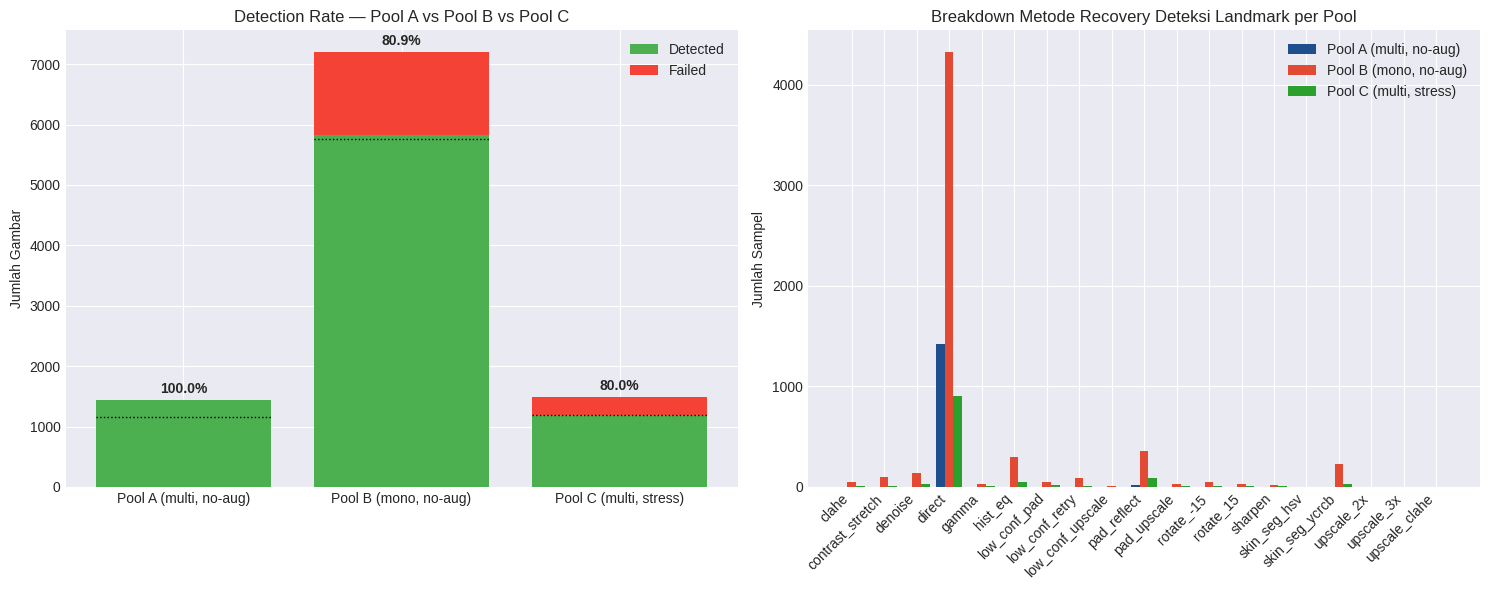

=== Ringkasan Detection Rate (target > 80%, terutama Pool A & Pool C) ===
✅ Pool A (multi, no-aug): 1440/1440 = 100.00%
✅ Pool B (mono, no-aug): 5825/7200 = 80.90%
✅ Pool C (multi, stress): 1191/1488 = 80.04%


In [ ]:
stats_all_pools = {'Pool A (mono, no-aug)': detection_main,
                    'Pool B (multi, no-aug)': detection_robust,
                    'Pool C (multi, aug)': detection_stress}
data_all_pools = {'Pool A (mono, no-aug)': main_data['data'],
                   'Pool B (multi, no-aug)': robust_data['data'],
                   'Pool C (multi, aug)': stress_data['data']}
plot_combined_detection_overview(stats_all_pools, data_all_pools)

print("=== Ringkasan Detection Rate (target > 80%, terutama Pool A & Pool C) ===")
for name, stats in stats_all_pools.items():
    rate = stats['detected']/stats['total']*100 if stats['total'] > 0 else 0
    status = "✅" if rate >= 80 else "⚠️"
    print(f"{status} {name}: {stats['detected']}/{stats['total']} = {rate:.2f}%")

<a id="3.-data-understanding-eksplorasi-dan-pemahaman-data"></a>

## **3. Data Understanding: Eksplorasi dan Pemahaman Data**

Sebelum masuk ke tahap membangun model (Modeling), penting untuk benar-benar **"berkenalan" dengan data** terlebih dahulu: memeriksa kualitas, jumlah, dan pola-pola di dalamnya. Bagian ini menyajikan Exploratory Data Analysis (EDA) yang mencakup:

1. Statistik dasar tiap Pool (jumlah sampel, tingkat deteksi).
2. Jumlah data per split (train/val/test).
3. Distribusi kelas (apakah tiap huruf jumlah sampelnya seimbang?).
4. Contoh gambar mentah per kelas, sebelum diproses.
5. Perbandingan visual antar pool (background sama huruf, beda pool).
6. Overlay & distribusi koordinat landmark.
7. Dimensi gambar & peta kesulitan deteksi per kelas.

**Kenapa EDA penting?** Kalau ada kelas yang datanya sangat sedikit, atau ada pool yang mayoritas fotonya gagal dideteksi, maka hasil evaluasi model nanti bisa menyesatkan jika tidak dipahami konteksnya lebih dulu.


<a id="3.1-statistik-dasar-tiap-pool"></a>

### **3.1 Statistik Dasar Tiap Pool**

Menghitung jumlah sampel per split & label, jumlah yang terdeteksi/gagal, serta detection rate per kelas untuk masing-masing pool (Pool A, B, C). Perhatikan bahwa Pool A akan menunjukkan detection rate mendekati 100% (latar polos), sementara Pool B dan C akan lebih rendah (latar kompleks), ini bukan kesalahan, melainkan cerminan tingkat kesulitan visual masing-masing pool seperti dijelaskan di pendahuluan.


In [ ]:
def get_dataset_stats(data, dataset_name):
    df = pd.DataFrame(data['data'])
    if df.empty:
        print(f"\n=== Statistik {dataset_name} ===")
        print("Data kosong! Tidak ada sampel yang diproses.")
        return df
    stats = df.groupby(['split', 'label']).size().unstack(fill_value=0)
    print(f"\n=== Statistik {dataset_name} ===")
    print(stats)
    print(f"Total sampel: {len(df)}")
    print(f"Detected: {df['detected'].sum()}")
    print(f"Failed: {len(df) - df['detected'].sum()}")
    if 'class_detection' in data:
        print("\nDetection rate per kelas:")
        for letter, v in data['class_detection'].items():
            if v['total'] > 0:
                print(f"  {letter}: {v['detected']}/{v['total']} ({v['detected']/v['total']*100:.1f}%)")
    return df

df_main = get_dataset_stats(main_data, MAIN_DATASET)
df_robust = get_dataset_stats(robust_data, ROBUST_DATASET)
df_stress = get_dataset_stats(stress_data, STRESS_DATASET)



=== Statistik sibi_alphabet_mono_bg_no_augmentation ===
label   A   B   C   D   E   F   G   H   I   K  ...   P   Q   R   S   T   U  \
split                                          ...                           
test    3   3   3   3   3   6   3   3   3   3  ...   3   3   3   3   3   3   
train  51  51  51  51  51  42  51  51  51  51  ...  51  51  51  51  51  51   
val     6   6   6   6   6  12   6   6   6   6  ...   6   6   6   6   6   6   

label   V   W   X   Y  
split                  
test    3   3   3   3  
train  51  51  51  51  
val     6   6   6   6  

[3 rows x 24 columns]
Total sampel: 1440
Detected: 1440
Failed: 0

Detection rate per kelas:
  A: 60/60 (100.0%)
  B: 60/60 (100.0%)
  C: 60/60 (100.0%)
  D: 60/60 (100.0%)
  E: 60/60 (100.0%)
  F: 60/60 (100.0%)
  G: 60/60 (100.0%)
  H: 60/60 (100.0%)
  I: 60/60 (100.0%)
  K: 60/60 (100.0%)
  L: 60/60 (100.0%)
  M: 60/60 (100.0%)
  N: 60/60 (100.0%)
  O: 60/60 (100.0%)
  P: 60/60 (100.0%)
  Q: 60/60 (100.0%)
  R: 60/60 (100.0%

<a id="3.2-jumlah-data-train-val-test-per-pool"></a>

### **3.2 Jumlah Data Train / Val / Test per Pool**

Rekap jumlah gambar per split, diambil langsung dari hasil ekstraksi (`df_main`, `df_robust`, `df_stress`) supaya angkanya konsisten dengan apa yang benar-benar diproses oleh cascade deteksi landmark.

Sebagai gambaran awal: Pool A memiliki 1.440 foto (semua berhasil dideteksi), Pool B memiliki 7.200 foto (sekitar 81% berhasil dideteksi), dan Pool C (sampel) sekitar 1.500 foto (sekitar 80% berhasil dideteksi). Hanya Pool A yang dipecah menjadi train/val/test untuk melatih model; Pool B & C murni dipakai sebagai data ujian di luar proses training.


=== Jumlah Data per Split — Train / Val / Test (Pool C hanya split 'stress') ===


,train,val,test,stress,Total
Pool,,,,,
"Pool A (mono, no-aug)",1215,150,75,0,1440
"Pool B (multi, no-aug)",6120,720,360,0,7200
"Pool C (multi, stress)",0,0,0,1488,1488


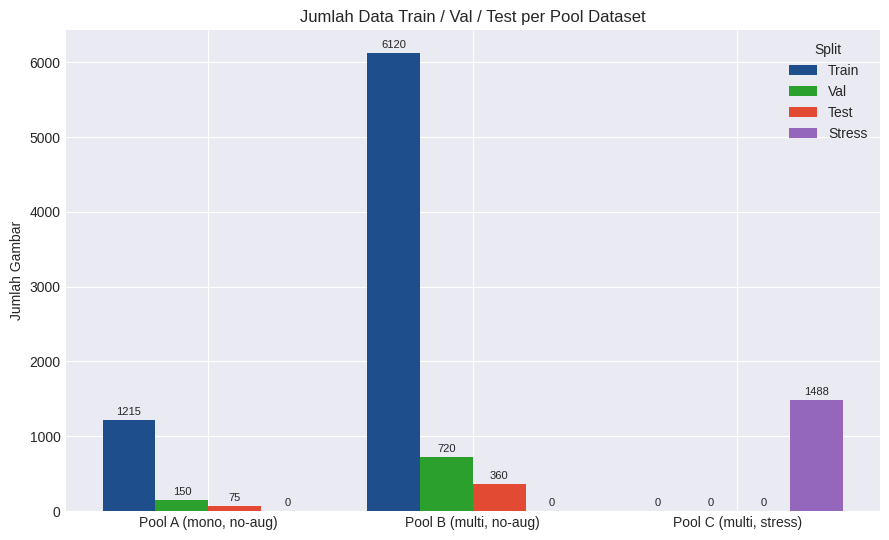

In [ ]:
from IPython.display import display

def build_split_count_table(df_dict):
    '''Rekap jumlah gambar per split (train/val/test/stress) untuk tiap pool.'''
    all_splits = []
    for df in df_dict.values():
        if not df.empty:
            all_splits.extend(df['split'].unique().tolist())
    seen = set(all_splits)
    split_order = [s for s in ['train', 'val', 'test', 'stress'] if s in seen]
    split_order += sorted(s for s in seen if s not in split_order)

    rows = []
    for name, df in df_dict.items():
        row = {'Pool': name}
        counts = df['split'].value_counts() if not df.empty else pd.Series(dtype=int)
        for s in split_order:
            row[s] = int(counts.get(s, 0))
        row['Total'] = int(counts.sum())
        rows.append(row)
    table = pd.DataFrame(rows).set_index('Pool')
    return table, split_order

# Catatan penamaan: MAIN_DATASET (Pool A) = dataset 'mono_no_aug', ROBUST_DATASET
# (Pool B) = dataset 'multi_no_aug' -- lihat MAIN_DATASET_KEY/ROBUST_DATASET_KEY.
split_table, split_order = build_split_count_table({
    'Pool A (mono, no-aug)': df_main,
    'Pool B (multi, no-aug)': df_robust,
    'Pool C (multi, aug)': df_stress,
})

print("=== Jumlah Data per Split — Train / Val / Test (Pool C hanya split 'stress') ===")
display(split_table)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(split_table.index))
n_splits = len(split_order)
width = 0.8 / max(n_splits, 1)
colors = ['#1f4e8c', '#2ca02c', '#e34a33', '#9467bd', '#ff7f0e']
for i, split_name in enumerate(split_order):
    vals = split_table[split_name].values
    bars = ax.bar(x + i*width, vals, width, label=split_name.capitalize(), color=colors[i % len(colors)])
    ax.bar_label(bars, fontsize=8, padding=2)
ax.set_xticks(x + width*(n_splits-1)/2)
ax.set_xticklabels(split_table.index, rotation=0)
ax.set_ylabel('Jumlah Gambar')
ax.set_title('Jumlah Data Train / Val / Test per Pool Dataset')
ax.legend(title='Split')
plt.tight_layout()
plt.show()


<a id="3.2b-detail-split-asli-pool-c-sebelum-sampling"></a>

### **3.2b Detail Split Asli Pool C (Sebelum Stratified Sampling)**

Tabel 3.2 di atas mencatat Pool C hanya sebagai satu split tunggal **'stress'** (± 1.500 gambar hasil *stratified sampling*), karena begitu cara Section 2.7 memprosesnya. Padahal, folder sumber Pool C (`multi_bg_with_augmentation`, total 19.439 gambar) **aslinya juga punya struktur train/val/test sendiri** sama seperti Pool A & B sebelum digabung dan disampling. Blok ini menghitung ulang langsung dari folder sumber untuk menampilkan berapa banyak gambar Pool C yang sebenarnya ada di tiap split asli tersebut, supaya perbandingan skala data dengan Pool A/B lebih transparan.

In [ ]:
def count_raw_images_by_split(dataset_path):
    '''Menyusuri folder dataset & menghitung jumlah gambar per SPLIT ASLI
    (train/val/valid/test), tanpa memandang label huruf -- dipakai khusus untuk
    melihat komposisi split asli Pool C sebelum digabung jadi satu split
    "stress" pada tahap sampling (lihat Section 2.7).'''
    SPLIT_NORMALIZE = {'valid': 'val', 'validation': 'val'}
    counts = {}
    if not os.path.exists(dataset_path):
        return counts
    for root, _, files in os.walk(dataset_path):
        img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if not img_files:
            continue
        rel_path = os.path.relpath(root, dataset_path)
        parts = [p.lower() for p in rel_path.split(os.sep) if p not in ('', '.')]
        split = None
        for p in parts:
            p_norm = SPLIT_NORMALIZE.get(p, p)
            if p_norm in ('train', 'val', 'test'):
                split = p_norm
                break
        split = split or 'lainnya'
        counts[split] = counts.get(split, 0) + len(img_files)
    return counts

raw_pool_c_counts = count_raw_images_by_split(os.path.join(BASE_DATA_DIR, STRESS_DATASET))
split_order_raw = [s for s in ['train', 'val', 'test'] if s in raw_pool_c_counts]
split_order_raw += sorted(s for s in raw_pool_c_counts if s not in split_order_raw)
total_raw = sum(raw_pool_c_counts.values())

print(f"=== Pool C ({STRESS_DATASET}) -- Komposisi Split ASLI Sebelum Sampling ===")
for s in split_order_raw:
    n = raw_pool_c_counts[s]
    pct = (n / total_raw * 100) if total_raw else 0
    print(f"  {s:8s}: {n:6d} gambar ({pct:.1f}%)")
print(f"  {'TOTAL':8s}: {total_raw:6d} gambar")

print(f"\nSetelah stratified sampling (STRESS_SAMPLE_SIZE={STRESS_SAMPLE_SIZE}), seluruh "
      f"{len(stress_pairs)} sampel dari ketiga split asli di atas digabung menjadi SATU split "
      f"evaluasi bernama 'stress' (lihat df_stress pada Tabel 3.2) -- karena Pool C dipakai "
      f"murni sebagai stress test, bukan untuk training, sehingga label split train/val/test "
      f"aslinya sudah tidak relevan dipertahankan lagi.")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(split_order_raw, [raw_pool_c_counts[s] for s in split_order_raw], color='#e34a33')
ax.bar_label(bars, fontsize=9)
ax.set_ylabel('Jumlah Gambar')
ax.set_title(f'Pool C -- Komposisi Split Asli Sebelum Sampling\n(Total={total_raw} gambar, folder: {STRESS_DATASET})')
plt.tight_layout()
plt.show()


<a id="3.3-distribusi-kelas-per-pool"></a>

### **3.3 Distribusi Kelas per Pool**

Visualisasi jumlah sampel per huruf (kelas) untuk masing-masing pool, untuk melihat apakah datasetnya seimbang (*balanced*) antar kelas. Ketimpangan jumlah sampel yang besar antar huruf bisa membuat model bias, cenderung "malas" mengenali huruf yang jarang muncul, dan terlalu percaya diri pada huruf yang sering muncul.

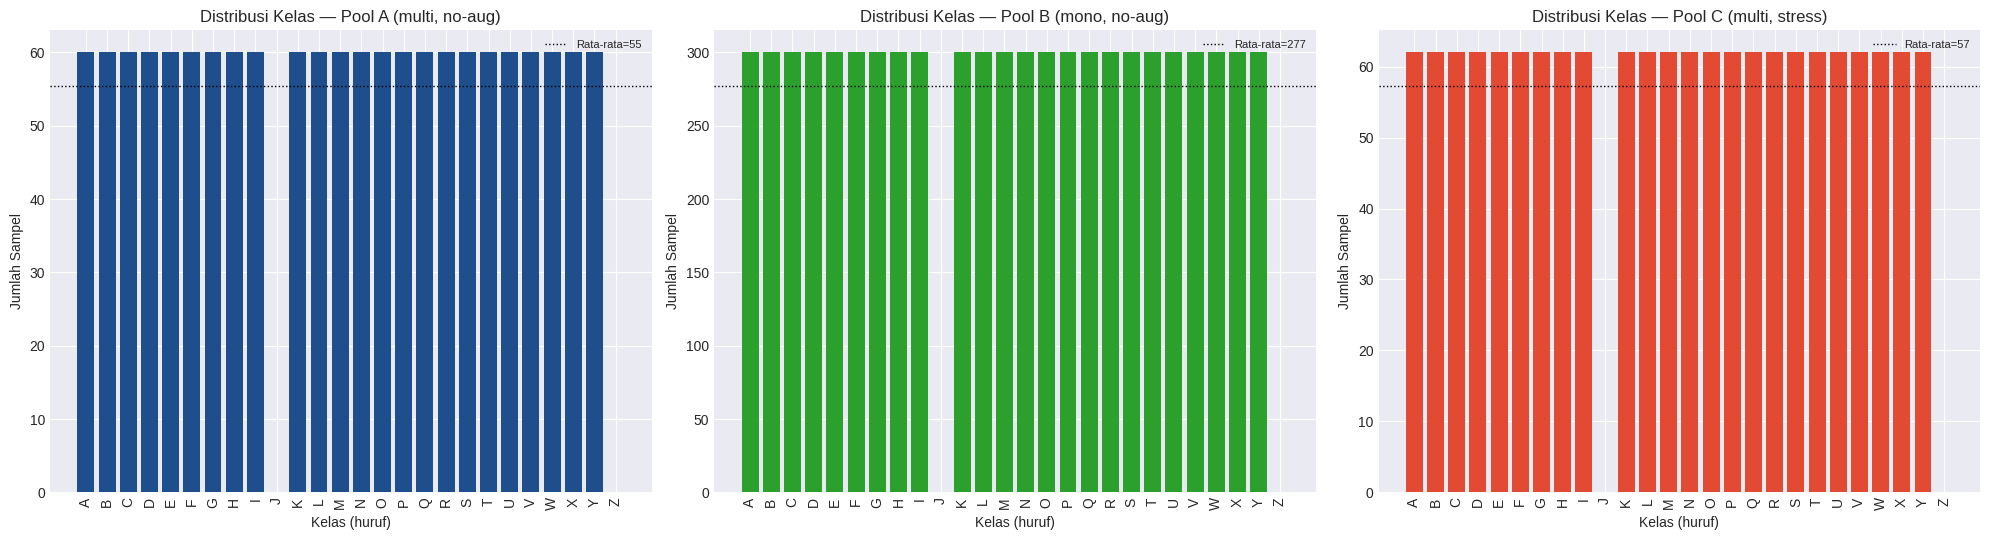

In [ ]:
def plot_class_distribution_all_pools(df_dict):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=False)
    colors = ['#1f4e8c', '#2ca02c', '#e34a33']
    for ax, (name, df), color in zip(axes, df_dict.items(), colors):
        if df.empty:
            ax.set_title(f"{name} (kosong)")
            continue
        counts = df['label'].value_counts().reindex(ALPHABET, fill_value=0)
        ax.bar(counts.index, counts.values, color=color)
        ax.set_title(f'Distribusi Kelas — {name}')
        ax.set_xlabel('Kelas (huruf)')
        ax.set_ylabel('Jumlah Sampel')
        ax.tick_params(axis='x', rotation=90)
        mean_count = counts.mean()
        ax.axhline(mean_count, color='black', linestyle=':', linewidth=1, label=f'Rata-rata={mean_count:.0f}')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_class_distribution_all_pools({
    'Pool A (mono, no-aug)': df_main,
    'Pool B (multi, no-aug)': df_robust,
    'Pool C (multi, aug)': df_stress,
})


<a id="3.4-contoh-gambar-mentah-per-kelas-sebelum-ekstraksi-landmark"></a>

### **3.4 Contoh Gambar Mentah per Kelas: Sebelum Ekstraksi Landmark**

Sebelum masuk ke tahap ekstraksi landmark, berikut contoh gambar mentah (RGB asli, belum diproses apapun) untuk **setiap dari 26 kelas huruf** pada Pool A. Tujuannya sederhana: memberi gambaran visual "seperti apa sebenarnya gestur tangan SIBI itu" sebelum direpresentasikan menjadi titik-titik landmark (untuk GCN) atau piksel ternormalisasi (untuk CNN) supaya pembaca awam juga bisa membayangkan variasi bentuk tangan yang harus dibedakan oleh model. Bagian ini sekarang menampilkan **dua grid berpasangan**: grid 3.4.2 (SEBELUM, gambar mentah) dan grid 3.4.3 (SESUDAH, dengan 21 titik landmark MediaPipe) untuk seluruh 26 kelas, supaya perbedaannya langsung terlihat huruf per huruf, bukan cuma untuk beberapa contoh (bandingkan dengan Section 3.7 yang hanya menampilkan 4 huruf).


<a id="3.4.1-fungsi-bantuan-mengindeks-gambar-per-split-label"></a>

**3.4.1 Fungsi Bantuan: Mengindeks Gambar per Split & Label**

`collect_images_by_split_label()` menyusuri folder dataset dan mengelompokkan path gambar berdasarkan (split, label) — baik dari nama subfolder maupun dari awalan nama file (format dataset ini: `A_0_jpg.rf.<hash>.jpg`). Fungsi ini dipakai bersama oleh semua visualisasi "contoh gambar" di bawah supaya hasilnya konsisten dengan gambar yang benar-benar diproses `extract_landmarks()`.

In [ ]:
def collect_images_by_split_label(dataset_path):
    '''[PATCH v3] Susuri dataset_path secara rekursif dan kelompokkan path gambar
    berdasarkan (split, label). Logika IDENTIK dengan extract_landmarks():
      1) coba cari label dari nama folder (case-insensitive) -- berguna kalau
         datasetnya punya subfolder per huruf.
      2) kalau tidak ada, fallback ke nama file -- dataset SIBI Mendeley ini
         TIDAK punya subfolder per huruf; filenya datar langsung di
         images/<split>/, dengan nama seperti "A_0_jpg.rf.<hash>.jpg" (huruf
         label ada di awal nama file, format ekspor Roboflow).
    Dipakai bersama oleh semua visualisasi "contoh gambar" supaya hasilnya
    konsisten dengan gambar yang benar-benar diekstrak oleh extract_landmarks().'''
    import re
    SPLIT_NAMES = {'train', 'val', 'valid', 'validation', 'test'}
    SPLIT_NORMALIZE = {'valid': 'val', 'validation': 'val'}
    ALPHABET_SET = {c.upper() for c in ALPHABET}
    index = {}
    if not os.path.exists(dataset_path):
        return index

    for root, _, files in os.walk(dataset_path):
        img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if not img_files:
            continue
        rel_path = os.path.relpath(root, dataset_path)
        parts = [p for p in rel_path.split(os.sep) if p not in ('', '.')]

        split = None
        split_idx = None
        for i, p in enumerate(parts):
            p_low = p.strip().lower()
            if p_low in SPLIT_NAMES:
                split = SPLIT_NORMALIZE.get(p_low, p_low)
                split_idx = i
                break

        folder_label = None
        if split_idx is not None:
            for p in parts[split_idx + 1:]:
                p_up = p.strip().upper()
                if p_up in ALPHABET_SET:
                    folder_label = p_up
                    break
        else:
            for p in parts:
                p_up = p.strip().upper()
                if p_up in ALPHABET_SET:
                    folder_label = p_up
                    split = 'train'
                    break

        if split is None:
            split = 'train'

        for f in img_files:
            label = folder_label
            if label is None:
                # [PATCH v3] fallback nama file: "A_0_jpg.rf.<hash>.jpg" -> label 'A'
                name_no_ext = os.path.splitext(f)[0]
                m = re.search(r'(?<![A-Za-z])([A-Za-z])(?![A-Za-z])', name_no_ext)
                if m and m.group(1).upper() in ALPHABET_SET:
                    label = m.group(1).upper()
                elif name_no_ext and name_no_ext[0].upper() in ALPHABET_SET:
                    label = name_no_ext[0].upper()
            if label is None:
                continue
            index.setdefault(split, {}).setdefault(label, []).append(os.path.join(root, f))
    return index

<a id="3.4.2-grid-contoh-gambar-per-kelas-pool-a-sebelum-ekstraksi"></a>

**3.4.2 Grid Contoh Gambar per Kelas (Pool A, sebelum ekstraksi)**

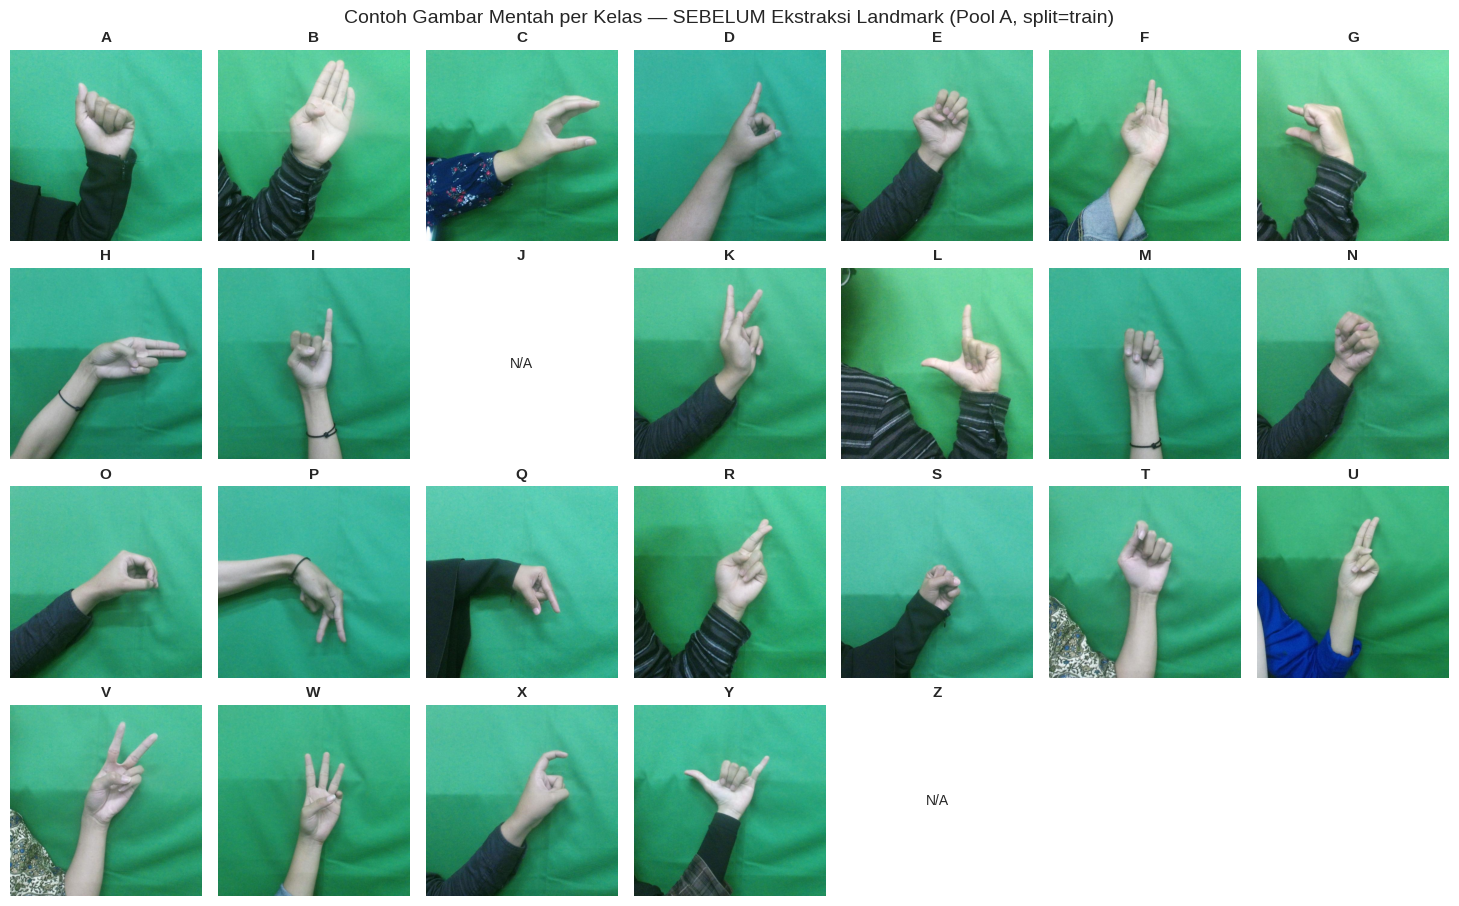

In [ ]:
def plot_all_classes_grid(dataset_path, alphabet, split='train', cols=7):
    '''Grid berisi satu contoh gambar acak per kelas (sebelum ekstraksi landmark).'''
    index = collect_images_by_split_label(dataset_path)
    if not index:
        print(f"Tidak ditemukan gambar apa pun di {dataset_path}. Cek kembali BASE_DATA_DIR/MAIN_DATASET.")
        return

    split_key = split.strip().lower()
    if split_key not in index:
        available = ', '.join(sorted(index.keys())) or '(tidak ada)'
        print(f"[INFO] Split '{split}' tidak ditemukan di {dataset_path}. "
              f"Split yang tersedia: {available}. Memakai split pertama yang tersedia.")
        split_key = sorted(index.keys())[0]
    class_map = index.get(split_key, {})

    rows = int(np.ceil(len(alphabet) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.1, rows*2.3))
    axes = axes.flatten()
    rng = random.Random(42)
    for i, letter in enumerate(alphabet):
        ax = axes[i]
        img_files = class_map.get(letter.upper(), [])
        img = None
        if img_files:
            img_path = rng.choice(img_files)
            img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
        ax.set_title(letter, fontsize=11, fontweight='bold')
        ax.axis('off')
    for j in range(len(alphabet), len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'Contoh Gambar Mentah per Kelas — SEBELUM Ekstraksi Landmark (Pool A, split={split_key})', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_all_classes_grid(os.path.join(BASE_DATA_DIR, MAIN_DATASET), ALPHABET, split='train', cols=7)

<a id="3.4.2b-preview-cepat-sesudah-ekstraksi-landmark"></a>

**3.4.2b Preview Cepat: Contoh Gambar SESUDAH Ekstraksi Landmark**

Sebagai jembatan cepat sebelum melihat grid lengkap 26 kelas di 3.4.3 (yang ukurannya besar), berikut preview beberapa contoh huruf saja (default: A, B, L, Y) yang **sudah melalui ekstraksi landmark**. 21 titik sendi hasil MediaPipe digambar langsung di atas foto tangannya. Bandingkan dengan grid "SEBELUM" pada 3.4.2 di atas untuk huruf yang sama.

In [ ]:
def plot_quick_landmark_preview(data_sample, letters=('A', 'B', 'L', 'Y'), split='train', seed=42):
    """Preview cepat beberapa huruf saja (bukan seluruh 26 kelas) dengan 21 titik
    landmark digambar di atas foto asli -- pelengkap ringkas untuk grid penuh di 3.4.3."""
    by_letter = {}
    for item in data_sample:
        if item['split'] == split and item['detected']:
            by_letter.setdefault(item['label'], []).append(item)

    letters_avail = [l for l in letters if l.upper() in by_letter]
    if not letters_avail:
        print("Tidak ada sampel terdeteksi untuk huruf yang diminta pada split ini.")
        return

    rng = random.Random(seed)
    fig, axes = plt.subplots(1, len(letters_avail), figsize=(len(letters_avail) * 3.2, 3.6))
    if len(letters_avail) == 1:
        axes = [axes]

    for ax, letter in zip(axes, letters_avail):
        sample = rng.choice(by_letter[letter.upper()])
        img_raw = cv2.imread(sample['path'])
        if img_raw is None:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            ax.axis('off')
            continue
        img = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        for (x, y, z) in sample['landmarks']:
            cx, cy = int(x * w), int(y * h)
            cv2.circle(img, (cx, cy), 4, (0, 255, 0), -1)
        ax.imshow(img)
        ax.set_title(f"'{letter}' -- sesudah ekstraksi", fontsize=11, fontweight='bold')
        ax.axis('off')

    plt.suptitle('Preview Cepat -- Contoh Gambar SESUDAH Ekstraksi Landmark (Pool A)', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_quick_landmark_preview(main_data['data'], letters=('A', 'B', 'L', 'Y'), split='train')


<a id="3.4.3-grid-contoh-gambar-per-kelas-setelah-ekstraksi-landmark-pool-a"></a>

#### 3.4.3 Grid Contoh Gambar per Kelas SETELAH Ekstraksi Landmark (Pool A)

Untuk tiap dari 26 kelas huruf, menampilkan satu contoh gambar Pool A yang sama polanya (split & pemilihan sampel acak dengan seed tetap) tapi kali ini dengan **21 titik landmark hasil MediaPipe** digambar di atasnya (titik hijau). Kelas yang tidak punya sampel terdeteksi pada split terkait akan ditandai N/A. Bandingkan berdampingan dengan grid 3.4.2 di atas untuk melihat langsung seberapa akurat landmark terpasang pada tiap gestur huruf.


In [ ]:
def plot_all_classes_grid_with_landmarks(data_sample, alphabet, split='train', cols=7, seed=42):
    '''Versi "SETELAH" dari plot_all_classes_grid(): untuk tiap kelas huruf, ambil satu
    sampel yang landmark-nya BERHASIL terdeteksi (detected=True) dari data_sample (hasil
    extract_landmarks()), lalu gambar 21 titik landmark di atas foto aslinya. Dipakai
    berdampingan dengan plot_all_classes_grid() (versi SEBELUM) untuk perbandingan visual
    penuh 26 kelas.'''
    # Kelompokkan sampel yang terdeteksi berdasarkan (split, label) -> list item
    by_letter = {}
    for item in data_sample:
        if item['split'] != split or not item['detected']:
            continue
        by_letter.setdefault(item['label'], []).append(item)

    rng = random.Random(seed)   # seed sama dengan plot_all_classes_grid supaya "terasa" berpasangan
    rows = int(np.ceil(len(alphabet) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.1, rows*2.3))
    axes = axes.flatten()

    for i, letter in enumerate(alphabet):
        ax = axes[i]
        candidates = by_letter.get(letter.upper(), [])
        img = None
        if candidates:
            sample = rng.choice(candidates)
            # item['path'] sudah berupa path lengkap ke file gambar (diisi saat ekstraksi)
            img_raw = cv2.imread(sample['path'])
            if img_raw is not None:
                img = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
                h, w, _ = img.shape
                # Gambar 21 titik landmark (koordinat ternormalisasi -> piksel) sebagai lingkaran hijau,
                # gaya sama persis dengan plot_landmark_overlay() (3.6) supaya konsisten di seluruh notebook
                for (x, y, z) in sample['landmarks']:
                    cx, cy = int(x * w), int(y * h)
                    cv2.circle(img, (cx, cy), 3, (0, 255, 0), -1)
        if img is not None:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
        ax.set_title(letter, fontsize=11, fontweight='bold')
        ax.axis('off')

    for j in range(len(alphabet), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Contoh Gambar per Kelas — SESUDAH Ekstraksi Landmark (Pool A, split={split})', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_all_classes_grid_with_landmarks(main_data['data'], ALPHABET, split='train', cols=7)


<a id="3.5-contoh-gambar-tiap-dataset-perbandingan-antar-pool"></a>

### **3.5 Contoh Gambar Tiap Dataset (Perbandingan Antar Pool)**

Menampilkan gambar untuk huruf yang **sama**, diambil dari ketiga pool secara berdampingan, supaya perbedaan tingkat kesulitan visual terlihat langsung dengan mata:
- **Pool A**: latar polos/seragam (paling mudah dibaca, baik oleh manusia maupun MediaPipe).
- **Pool B**: latar bervariasi & ramai (lebih menantang).
- **Pool C**: latar ramai **ditambah** gangguan buatan (blur, noise, kecerahan berubah, rotasi).

Perbandingan berdampingan ini adalah bukti visual paling langsung mengapa detection rate menurun dari Pool A → B → C.

<a id="3.5.1-fungsi-bantuan-mencari-contoh-gambar-per-huruf"></a>

**3.5.1 Fungsi Bantuan: Mencari Contoh Gambar per Huruf**

In [ ]:
def find_sample_image(dataset_path, split_candidates, letter, index=None):
    '''Sekarang berbasis collect_images_by_split_label() (index) alih-alih
    path hardcoded dataset_path/images/<split>/<letter>. `index` bisa dioper supaya
    tidak menyusuri ulang folder yang sama berkali-kali (lebih cepat).'''
    if index is None:
        index = collect_images_by_split_label(dataset_path)
    letter_up = letter.upper()
    for split in split_candidates:
        img_files = index.get(split.strip().lower(), {}).get(letter_up, [])
        if img_files:
            return cv2.imread(random.choice(img_files))
    # fallback: split apa pun yang tersedia
    for split_key, class_map in index.items():
        img_files = class_map.get(letter_up, [])
        if img_files:
            return cv2.imread(random.choice(img_files))
    return None

<a id="3.5.2-grid-perbandingan-pool-a-vs-b-vs-c-untuk-huruf-yang-sama"></a>

**3.5.2 Grid Perbandingan Pool A vs B vs C untuk Huruf yang Sama**

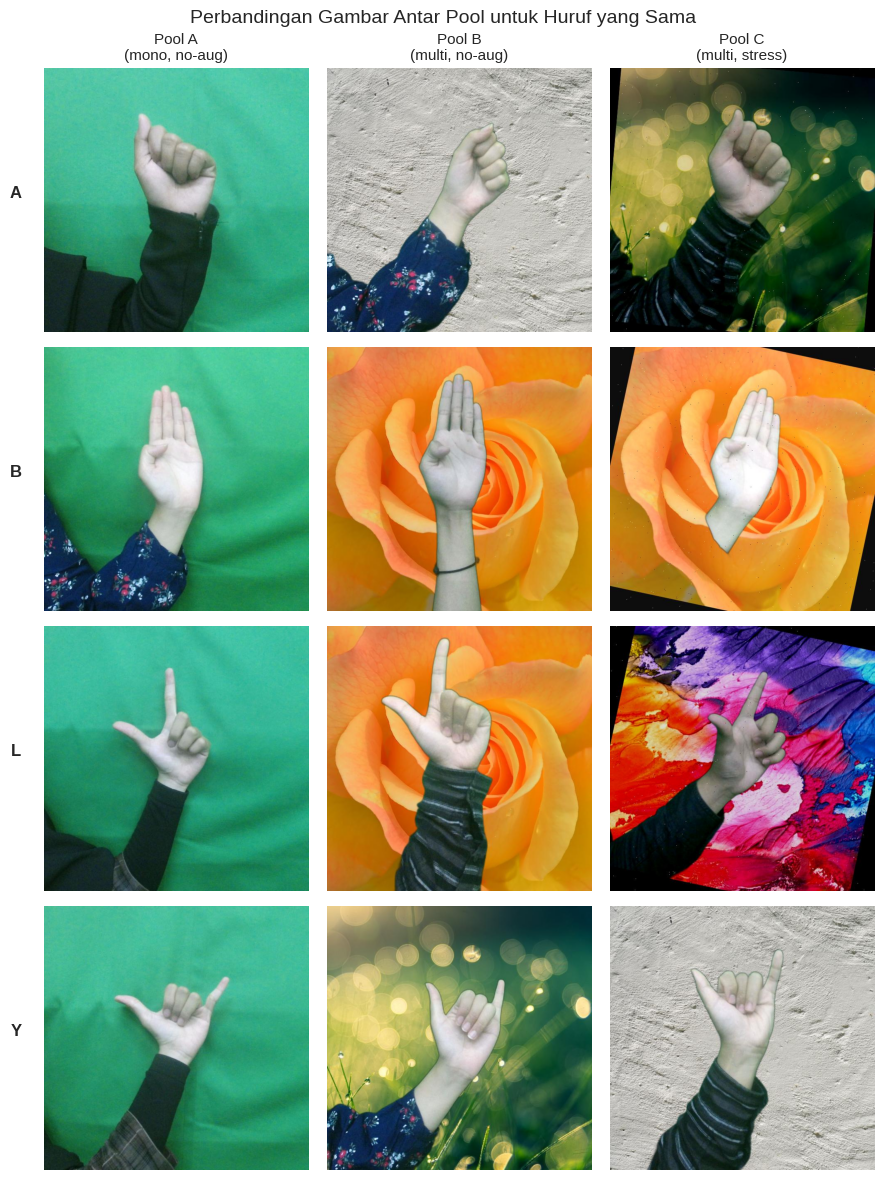

In [ ]:
def plot_dataset_comparison(letters_to_show=('A', 'B', 'L', 'Y')):
    pools = [
        ('Pool A\n(mono, no-aug)', os.path.join(BASE_DATA_DIR, MAIN_DATASET)),
        ('Pool B\n(multi, no-aug)', os.path.join(BASE_DATA_DIR, ROBUST_DATASET)),
        ('Pool C\n(multi, aug)', os.path.join(BASE_DATA_DIR, STRESS_DATASET)),
    ]
    indices = {name: collect_images_by_split_label(path) for name, path in pools}

    fig, axes = plt.subplots(len(letters_to_show), len(pools), figsize=(len(pools)*3, len(letters_to_show)*3))
    rng = random.Random(42)
    for r, letter in enumerate(letters_to_show):
        for c, (pool_name, path) in enumerate(pools):
            ax = axes[r, c]
            img = find_sample_image(path, ['train', 'val', 'test', 'stress'], letter, index=indices[pool_name])
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            if r == 0:
                ax.set_title(pool_name, fontsize=11)
            if c == 0:
                ax.set_ylabel(letter, fontsize=12, fontweight='bold', rotation=0, labelpad=20)
            ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle('Perbandingan Gambar Antar Pool untuk Huruf yang Sama', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_dataset_comparison(letters_to_show=('A', 'B', 'L', 'Y'))

<a id="3.6-overlay-21-titik-landmark-pada-contoh-gambar"></a>

### **3.6 Overlay 21 Titik Landmark pada Contoh Gambar**

Dua visualisasi inti berbasis landmark:
1. **Overlay**: menggambar 21 titik landmark di atas foto tangan asli, untuk memastikan (secara visual, sekilas mata) bahwa deteksi MediaPipe memang jatuh tepat di posisi sendi tangan, bukan salah tempat.
2. **Distribusi koordinat**: sebaran nilai (x, y, z) landmark setelah dinormalisasi (posisi & skala tangan disamakan), yaitu bahan baku fitur yang menjadi input model GCN. Sebaran yang rapi dan konsisten antar sampel menandakan proses normalisasi bekerja dengan baik.
menyeluruh secara visual.

In [ ]:
def plot_landmark_overlay(dataset_path, data_sample):
    detected = [d for d in data_sample if d['detected']]
    if not detected:
        print("Tidak ada landmark terdeteksi untuk overlay.")
        return
    sample = random.choice(detected)
    possible_paths = [
        os.path.join(dataset_path, 'images', sample['split'], sample['label'], sample['file']),
        os.path.join(dataset_path, sample['split'], sample['label'], sample['file'])
    ]
    img_path = next((p for p in possible_paths if os.path.exists(p)), None)
    if img_path is None:
        print("Gambar tidak ditemukan.")
        return
    img = cv2.imread(img_path)
    if img is None:
        print("Gambar tidak terbaca.")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    coords = sample['landmarks']
    for (x, y, z) in coords:
        cx, cy = int(x*w), int(y*h)
        cv2.circle(img, (cx, cy), 3, (0, 255, 0), -1)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Overlay Landmark - {sample['label']}")
    plt.axis('off')
    plt.show()

In [ ]:
plot_landmark_overlay(os.path.join(BASE_DATA_DIR, MAIN_DATASET), main_data['data'])

Gambar tidak ditemukan.


<a id="3.7-perbandingan-visual-sebelum-vs-sesudah-ekstraksi-landmark"></a>

### **3.7 Perbandingan Visual: SEBELUM vs SESUDAH Ekstraksi Landmark**

Untuk memperjelas apa yang sebenarnya dilakukan MediaPipe, blok baru di bawah menampilkan beberapa contoh **berdampingan**: foto tangan asli (SEBELUM) di sisi kiri, dan foto yang sama dengan 21 titik landmark digambar di atasnya (SESUDAH) di sisi kanan. Ini melengkapi visualisasi overlay tunggal pada 3.6 dengan tampilan yang lebih mudah dibandingkan untuk beberapa huruf sekaligus.

In [ ]:
def plot_before_after_landmarks(dataset_path, data_sample, letters_to_show=('A', 'B', 'L', 'Y'), seed=42):
    '''Menampilkan gambar SEBELUM (mentah, apa adanya) dan SESUDAH (dengan overlay
    21 titik landmark hasil MediaPipe) secara berdampingan, untuk beberapa huruf
    contoh. Melengkapi plot_landmark_overlay() (3.6) yang hanya menampilkan 1 sampel.'''
    rng = random.Random(seed)
    detected_by_letter = {}
    for d in data_sample:
        if d['detected']:
            detected_by_letter.setdefault(d['label'], []).append(d)
    letters_to_show = [l for l in letters_to_show if l in detected_by_letter]
    if not letters_to_show:
        print("Tidak ada sampel dengan landmark terdeteksi untuk huruf yang diminta.")
        return

    fig, axes = plt.subplots(len(letters_to_show), 2, figsize=(6, 3 * len(letters_to_show)))
    if len(letters_to_show) == 1:
        axes = axes.reshape(1, 2)

    for r, letter in enumerate(letters_to_show):
        sample = rng.choice(detected_by_letter[letter])
        possible_paths = [
            os.path.join(dataset_path, 'images', sample['split'], sample['label'], sample['file']),
            os.path.join(dataset_path, sample['split'], sample['label'], sample['file']),
        ]
        img_path = next((p for p in possible_paths if os.path.exists(p)), None)
        img_raw = cv2.imread(img_path) if img_path else None
        if img_raw is None:
            for ax in axes[r]:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
                ax.axis('off')
            continue

        img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        img_overlay = img_raw.copy()
        h, w, _ = img_overlay.shape
        for (x, y, z) in sample['landmarks']:
            cx, cy = int(x * w), int(y * h)
            cv2.circle(img_overlay, (cx, cy), 3, (0, 255, 0), -1)

        axes[r, 0].imshow(img_raw)
        axes[r, 0].set_title(f"SEBELUM — huruf {letter}", fontsize=10)
        axes[r, 0].axis('off')

        axes[r, 1].imshow(img_overlay)
        axes[r, 1].set_title("SESUDAH — 21 titik landmark", fontsize=10)
        axes[r, 1].axis('off')

    plt.suptitle('Perbandingan Sebelum vs Sesudah Ekstraksi Landmark MediaPipe (Pool A)', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_before_after_landmarks(os.path.join(BASE_DATA_DIR, MAIN_DATASET), main_data['data'],
                             letters_to_show=('A', 'B', 'L', 'Y'))

<a id="3.8-distribusi-koordinat-landmark-setelah-normalisasi"></a>

### **3.8 Distribusi Koordinat Landmark (Setelah Normalisasi)**

Sebaran nilai (x, y, z) landmark setelah dinormalisasi (posisi & skala disamakan), inilah bahan baku fitur yang menjadi input model GCN. Sebaran yang rapi & konsisten antar sampel menandakan proses normalisasi bekerja dengan baik.

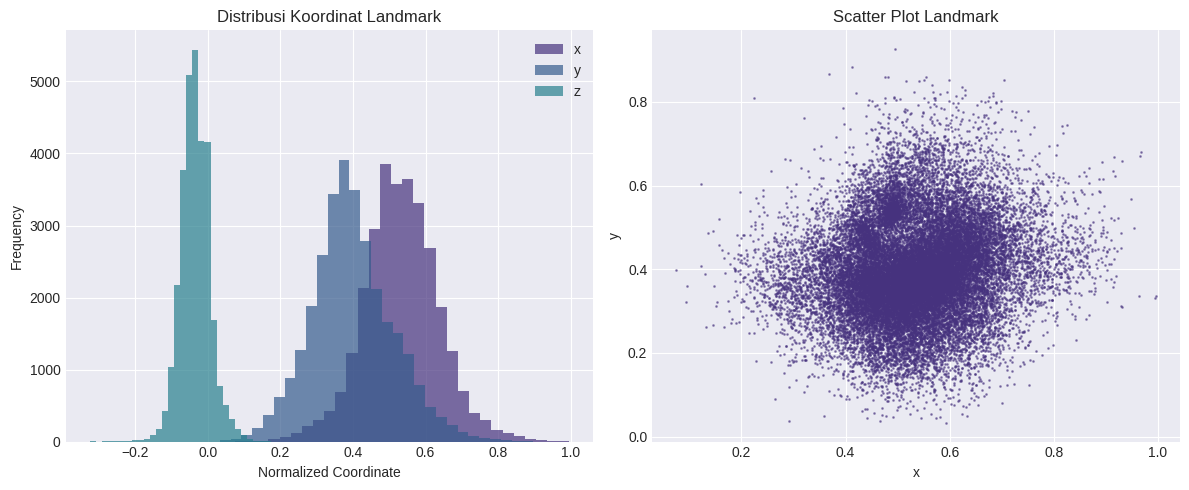

In [ ]:
def plot_landmark_distribution(data_sample):
    coords = []
    for d in data_sample:
        if d['detected']:
            coords.extend(d['landmarks'])
    if not coords:
        print("Tidak ada koordinat landmark untuk divisualisasikan.")
        return
    coords = np.array(coords)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(coords[:, 0], bins=30, alpha=0.7, label='x')
    plt.hist(coords[:, 1], bins=30, alpha=0.7, label='y')
    plt.hist(coords[:, 2], bins=30, alpha=0.7, label='z')
    plt.xlabel('Normalized Coordinate')
    plt.ylabel('Frequency')
    plt.legend()
    plt.title('Distribusi Koordinat Landmark')
    plt.subplot(1, 2, 2)
    plt.scatter(coords[:, 0], coords[:, 1], s=1, alpha=0.5)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Scatter Plot Landmark')
    plt.tight_layout()
    plt.show()

plot_landmark_distribution(main_data['data'])

<a id="3.9-distribusi-dimensi-gambar-mentah"></a>

### **3.9 Distribusi Dimensi Gambar Mentah**

Dua visualisasi tambahan yang relevan:
1. **Distribusi lebar & tinggi gambar mentah**, penting karena CNN akan me-*resize* semua gambar ke ukuran seragam sebelum diproses; grafik ini menunjukkan seberapa jauh variasi ukuran aslinya (foto yang sangat kecil/besar berpotensi kehilangan detail saat di-*resize*).
 Grafik di bawah relevan karena CNN akan me-*resize* semua gambar ke ukuran seragam sebelum diproses.

In [ ]:
def plot_image_size_distribution(dataset_path, split='train', max_samples=300):
    candidates = [os.path.join(dataset_path, 'images', split), os.path.join(dataset_path, split)]
    split_path = next((p for p in candidates if os.path.exists(p)), None)
    if split_path is None:
        print(f"Split '{split}' tidak ditemukan.")
        return
    widths, heights = [], []
    count = 0
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if not os.path.isdir(label_path):
            continue
        for f in os.listdir(label_path):
            if not f.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img = cv2.imread(os.path.join(label_path, f))
            if img is not None:
                h, w = img.shape[:2]
                widths.append(w); heights.append(h)
                count += 1
            if count >= max_samples:
                break
        if count >= max_samples:
            break
    if not widths:
        print("Tidak ada gambar untuk dianalisis dimensinya.")
        return
    plt.figure(figsize=(7, 6))
    plt.scatter(widths, heights, alpha=0.4, s=15, color='#1f4e8c')
    plt.xlabel('Lebar (px)')
    plt.ylabel('Tinggi (px)')
    plt.title(f'Distribusi Dimensi Gambar Mentah — {os.path.basename(dataset_path)}\n(sampel n={len(widths)})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Lebar: min={min(widths)}, max={max(widths)}, rata-rata={np.mean(widths):.0f}")
    print(f"Tinggi: min={min(heights)}, max={max(heights)}, rata-rata={np.mean(heights):.0f}")

plot_image_size_distribution(os.path.join(BASE_DATA_DIR, MAIN_DATASET), split='train')

Tidak ada gambar untuk dianalisis dimensinya.


<a id="3.10-heatmap-detection-rate-per-kelas-pool"></a>

### **3.10 Heatmap Detection Rate per Kelas × Pool**

Menunjukkan huruf mana yang paling sering "sulit dibaca" oleh MediaPipe di masing-masing pool. Huruf dengan detection rate rendah di sini layak diwaspadai saat menafsirkan akurasi klasifikasi akhir nanti, karena sampel yang gagal terdeteksi otomatis tidak ikut dievaluasi.

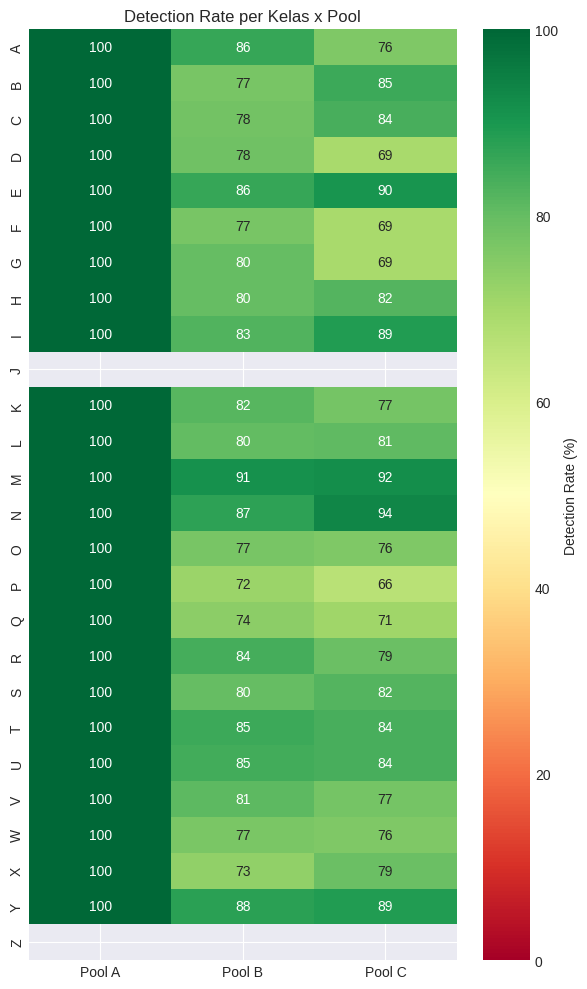

In [ ]:
def plot_detection_rate_heatmap(class_detection_dict):
    pool_names = list(class_detection_dict.keys())
    matrix = []
    for letter in ALPHABET:
        row = []
        for pool in pool_names:
            cd = class_detection_dict[pool].get(letter, {'total': 0, 'detected': 0})
            rate = cd['detected'] / cd['total'] * 100 if cd['total'] > 0 else np.nan
            row.append(rate)
        matrix.append(row)
    matrix = np.array(matrix)
    plt.figure(figsize=(6, 10))
    sns.heatmap(matrix, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100,
                xticklabels=pool_names, yticklabels=ALPHABET, cbar_kws={'label': 'Detection Rate (%)'})
    plt.title('Detection Rate per Kelas x Pool')
    plt.tight_layout()
    plt.show()

plot_detection_rate_heatmap({
    'Pool A': main_data.get('class_detection', {}),
    'Pool B': robust_data.get('class_detection', {}),
    'Pool C': stress_data.get('class_detection', {}),
})

<a id="3.11-eda-tambahan-ketimpangan-kelas-class-imbalance"></a>

### **3.11 EDA Tambahan: Ketimpangan Kelas (Class Imbalance) per Pool**

Melengkapi bar chart 3.3 dengan ringkasan **statistik deskriptif** jumlah sampel per kelas (min, max, rata-rata, std) serta **rasio ketimpangan** (*imbalance ratio* = kelas terbanyak / kelas tersedikit) untuk masing-masing pool, ditambah boxplot untuk melihat sebaran jumlah sampel per kelas sekaligus dalam satu gambar. Rasio ketimpangan yang jauh dari 1.0 mengindikasikan ada kelas yang jauh lebih banyak/sedikit sampelnya dibanding kelas lain, hal ini perlu diingat saat menafsirkan metrik precision/recall per kelas di Section 15b.

In [ ]:
def summarize_class_balance(df_dict):
    rows = []
    boxplot_data = []
    labels_box = []
    for name, df in df_dict.items():
        if df.empty:
            continue
        counts = df['label'].value_counts().reindex(ALPHABET, fill_value=0)
        rows.append({
            'Pool': name,
            'Jumlah Kelas Terisi': int((counts > 0).sum()),
            'Min/Kelas': int(counts.min()),
            'Max/Kelas': int(counts.max()),
            'Rata-rata/Kelas': round(counts.mean(), 1),
            'Std/Kelas': round(counts.std(), 1),
            'Imbalance Ratio (Max/Min)': round(counts.max() / max(counts.min(), 1), 2),
        })
        boxplot_data.append(counts.values)
        labels_box.append(name)
    summary_df = pd.DataFrame(rows).set_index('Pool')
    print("=== Ringkasan Ketimpangan Kelas (Class Imbalance) per Pool ===")
    display(summary_df)

    fig, ax = plt.subplots(figsize=(7.5, 5))
    bp = ax.boxplot(boxplot_data, labels=labels_box, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#1f4e8c', '#2ca02c', '#e34a33']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel('Jumlah Sampel per Kelas')
    ax.set_title('Sebaran Jumlah Sampel per Kelas (Boxplot) per Pool')
    ax.tick_params(axis='x', rotation=10)
    plt.tight_layout()
    plt.show()
    return summary_df

class_balance_summary = summarize_class_balance({
    'Pool A (mono, no-aug)': df_main,
    'Pool B (multi, no-aug)': df_robust,
    'Pool C (multi, aug)': df_stress,
})


<a id="3.12-distribusi-data-test-yang-digunakan-per-pool"></a>

### **3.12 Distribusi Data Test yang Digunakan untuk Evaluasi per Pool**

Berbeda dengan Tabel 3.2 (yang menghitung **seluruh** split tiap pool), blok ini fokus khusus pada berapa banyak sampel yang **benar-benar dipakai sebagai data uji/evaluasi** pada Section 9 (GCN) & Section 15 (CNN):

- **Pool A**: hanya split `test` miliknya sendiri yang dipakai sebagai data uji *in-domain* (karena split `train` & `val` dipakai untuk melatih model).
- **Pool B**: **seluruh** pool dipakai sebagai data uji *cross-domain*, karena Pool B tidak pernah dilihat model saat training sama sekali.
- **Pool C**: **seluruh** sampel hasil stratified sampling dipakai sebagai data uji *stress test*, dengan alasan yang sama seperti Pool B.

Perlu diperhatikan juga bahwa hanya sampel yang **berhasil terdeteksi landmarknya** (`detected=True`) yang benar-benar ikut dievaluasi model GCN; sampel gagal deteksi otomatis tidak menyumbang prediksi apapun ke metrik akurasi.

In [ ]:
def build_test_usage_table(df_main, df_robust, df_stress):
    n_test_a = int((df_main['split'] == 'test').sum()) if not df_main.empty else 0
    n_test_a_detected = int(((df_main['split'] == 'test') & (df_main['detected'])).sum()) if not df_main.empty else 0
    n_b_total = int(len(df_robust)) if not df_robust.empty else 0
    n_b_detected = int(df_robust['detected'].sum()) if not df_robust.empty else 0
    n_c_total = int(len(df_stress)) if not df_stress.empty else 0
    n_c_detected = int(df_stress['detected'].sum()) if not df_stress.empty else 0

    rows = [
        {'Pool': 'Pool A (in-domain test)', 'Peran': 'Split test dari data latih',
         'Total Sampel Uji': n_test_a, 'Terdeteksi': n_test_a_detected},
        {'Pool': 'Pool B (cross-domain)', 'Peran': 'Seluruh pool dipakai sbg data uji',
         'Total Sampel Uji': n_b_total, 'Terdeteksi': n_b_detected},
        {'Pool': 'Pool C (stress test)', 'Peran': 'Seluruh sampel dipakai sbg data uji',
         'Total Sampel Uji': n_c_total, 'Terdeteksi': n_c_detected},
    ]
    table = pd.DataFrame(rows).set_index('Pool')
    table['% Terdeteksi'] = (table['Terdeteksi'] / table['Total Sampel Uji'].replace(0, np.nan) * 100).round(1)
    return table

test_usage_table = build_test_usage_table(df_main, df_robust, df_stress)
print("=== Jumlah Data Test yang Benar-Benar Dipakai untuk Evaluasi per Pool ===")
display(test_usage_table)

fig, ax = plt.subplots(figsize=(7.5, 5))
x = np.arange(len(test_usage_table.index))
width = 0.35
bars1 = ax.bar(x - width/2, test_usage_table['Total Sampel Uji'], width,
               label='Total Sampel Uji', color='#1f4e8c')
bars2 = ax.bar(x + width/2, test_usage_table['Terdeteksi'], width,
               label='Berhasil Terdeteksi', color='#2ca02c')
ax.bar_label(bars1, fontsize=8, padding=2)
ax.bar_label(bars2, fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(test_usage_table.index, rotation=10, ha='right')
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Data Test yang Digunakan untuk Evaluasi per Pool')
ax.legend()
plt.tight_layout()
plt.show()

print("\nCatatan: hanya sampel dengan detected=True yang benar-benar ikut dievaluasi model "
      "pada Section 9 & 15; sampel gagal deteksi landmark tidak menyumbang prediksi apapun.")


<a id="4.-definisi-struktur-graf"></a>

## **4. Definisi Struktur Graf**
### **4.1 Struktur Edge Tangan (HAND_CONNECTIONS)**

Tangan direpresentasikan sebagai graf dengan 21 node (landmark MediaPipe) dan edge mengikuti struktur anatomis jari (`HAND_CONNECTIONS`, dibuat bidirectional). Fungsi `build_graph()` mengubah 21 koordinat landmark mentah menjadi tensor fitur node yang sudah dinormalisasi (translation & scale invariant) plus 2 fitur jarak geometris tambahan.

In [ ]:
import torch
from torch_geometric.data import Data

HAND_CONNECTIONS = [
    (0,1), (1,2), (2,3), (3,4),
    (0,5), (5,6), (6,7), (7,8),
    (0,9), (9,10), (10,11), (11,12),
    (0,13), (13,14), (14,15), (15,16),
    (0,17), (17,18), (18,19), (19,20),
    (5,9), (9,13), (13,17)
]

edges_bidir = HAND_CONNECTIONS + [(j, i) for i, j in HAND_CONNECTIONS]
edge_index = torch.tensor(edges_bidir, dtype=torch.long).t().contiguous()
num_nodes = 21

# Titik-titik knuckle utama (pangkal tiap jari), konvensi umum di hand-pose:
# 0=wrist, 5/9/13/17=pangkal index/middle/ring/pinky. Dipakai untuk estimasi
# pusat telapak tangan pada fitur node tambahan di bawah.
PALM_LANDMARK_IDX = [0, 5, 9, 13, 17]

print(f"Jumlah node: {num_nodes}, Jumlah edges (bidirectional): {edge_index.shape[1]}")

<a id="4.2-fungsi-build_graph-landmark-ke-fitur-node"></a>

### **4.2 Fungsi `build_graph()`: Landmark ke Fitur Node**

`HandGraphDataset` membungkus list objek `Data` (graf) menjadi Dataset yang kompatibel dengan `PyGDataLoader`. `prepare_pyg_data()` mengiterasi cache landmark tiap pool, membangun graf untuk setiap sampel yang landmark-nya berhasil dideteksi (`detected=True`), lalu menempelkan label kelasnya.

In [ ]:
def build_graph(landmarks):
    '''
    Bangun graf dari 21 landmark tangan.

    [PATCH] Fitur per node sekarang 5 dimensi (sebelumnya 3):
      [0:3] -> koordinat (x, y, z) ter-center & ter-scale (translation &
               scale invariant, SAMA seperti versi asli)
      [3]   -> jarak node ini ke wrist (landmark 0)
      [4]   -> jarak node ini ke pusat telapak (rata-rata landmark pangkal jari)

    Dua fitur tambahan ini murni turunan dari landmark yang sudah ada (tidak
    ada info baru dari luar dataset), jadi tetap fair dibanding CNN yang
    inputnya piksel mentah -- cuma menyamakan akses ke informasi bentuk tangan
    yang bagi CNN sudah "gratis" didapat dari gambar.
    '''
    lm = np.array(landmarks)
    center = lm.mean(axis=0)
    lm_centered = lm - center
    scale = np.max(np.linalg.norm(lm_centered, axis=1) + 1e-8)
    lm_norm = lm_centered / scale

    wrist = lm_norm[0]
    dist_to_wrist = np.linalg.norm(lm_norm - wrist, axis=1, keepdims=True)

    palm_center = lm_norm[PALM_LANDMARK_IDX].mean(axis=0)
    dist_to_palm = np.linalg.norm(lm_norm - palm_center, axis=1, keepdims=True)

    features = np.concatenate([lm_norm, dist_to_wrist, dist_to_palm], axis=1)  # (21, 5)
    x = torch.tensor(features, dtype=torch.float)
    return Data(x=x, edge_index=edge_index)

if main_data['data']:
    sample = next((d for d in main_data['data'] if d['detected']), None)
    if sample:
        g = build_graph(sample['landmarks'])
        print(g)
        print(f"Jumlah fitur per node sekarang: {g.x.shape[1]} (sebelumnya 3)")
    else:
        print("Tidak ada landmark terdeteksi untuk contoh.")
else:
    print("Tidak ada data landmark. Periksa ekstraksi.")

Jumlah node: 21, Jumlah edges (bidirectional): 46
Data(x=[21, 5], edge_index=[2, 46])
Jumlah fitur per node sekarang: 5 (sebelumnya 3)


<a id="4.3-konversi-ke-dataset-pytorch-geometric"></a>

### **4.3 Konversi ke Dataset PyTorch Geometric**

`HandGraphDataset` membungkus list objek `Data` (graf) menjadi Dataset yang kompatibel dengan `PyGDataLoader`. `prepare_pyg_data()` mengiterasi cache landmark tiap pool, membangun graf untuk setiap sampel yang landmark-nya berhasil dideteksi (`detected=True`), lalu menempelkan label kelasnya.

<a id="4.3.1-class-handgraphdataset"></a>

**4.3.1 Class `HandGraphDataset`**

Pembungkus tipis (thin wrapper) di atas `torch_geometric.data.Dataset` supaya list objek `Data` (graf per sampel) hasil `build_graph()` bisa dipakai langsung oleh `PyGDataLoader` seperti dataset PyTorch pada umumnya.

**Parameter:**
- `data_list: list objek torch_geometric.data.Data`

**Return:** Instance Dataset PyG yang siap dipakai DataLoader


In [ ]:
# ==========================================================================
# HandGraphDataset
# Pembungkus tipis (thin wrapper) di atas `torch_geometric.data.Dataset`
# supaya list objek `Data` (graf per sampel) hasil `build_graph()` bisa
# dipakai langsung oleh `PyGDataLoader` seperti dataset PyTorch pada umumnya.
# ==========================================================================

from torch_geometric.data import Dataset as PyGDataset

class HandGraphDataset(PyGDataset):
    '''Dataset PyG sederhana: hanya membungkus list objek Data yang sudah jadi (in-memory),
    tanpa proses download/pemrosesan tambahan (parameter transform/pre_transform hanya
    diteruskan ke parent class sesuai konvensi PyG).'''
    def __init__(self, data_list, transform=None, pre_transform=None):
        super().__init__(transform, pre_transform)
        self.data_list = data_list

    def len(self):
        # PyG memakai method len()/get() (bukan __len__/__getitem__) sebagai konvensinya sendiri
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]


<a id="4.3.2-fungsi-prepare_pyg_data"></a>

**4.3.2 Fungsi `prepare_pyg_data()`**

Mengubah data landmark hasil ekstraksi (dict cache) menjadi list graf PyG, hanya mengambil sampel dari split tertentu dan yang berhasil dideteksi (`detected=True`) -- sampel yang gagal dideteksi otomatis dibuang di sini.

**Parameter:**
- `cache_data: dict hasil extract_landmarks()/extract_landmarks_from_pairs()`
- `split_name: 'train' / 'val' / 'test' / 'stress'`

**Return:** List objek Data (graf) siap dipakai HandGraphDataset


In [ ]:
def prepare_pyg_data(cache_data, split_name):
    graph_list = []
    for item in cache_data['data']:
        if item['split'] != split_name:
            continue                          # ambil hanya baris dari split yang diminta
        if not item['detected']:
            continue                          # buang sampel yang gagal dideteksi landmark-nya
        landmarks = item['landmarks']
        g = build_graph(landmarks)            # bangun graf 21-node dari koordinat landmark
        g.y = torch.tensor(CLASS_TO_IDX[item['label']], dtype=torch.long)   # label kelas (0-25)
        graph_list.append(g)
    return graph_list


<a id="4.3.3-eksekusi-membangun-graph-dataset-untuk-ketiga-pool"></a>

**4.3.3 Eksekusi: Membangun Graph Dataset untuk Ketiga Pool**

Memanggil `prepare_pyg_data()` untuk membangun list graf pada Pool A (train/val/test), Pool B (cross-domain), dan Pool C (stress test), lalu mencetak ringkasan jumlah sampel tiap pool.


In [ ]:

# Bangun graf untuk tiap pool: Pool A (train/val/test), Pool B, Pool C (stress)
train_val_graphs = prepare_pyg_data(main_data, 'train') + prepare_pyg_data(main_data, 'val')
test_graphs = prepare_pyg_data(main_data, 'test')
robust_graphs = prepare_pyg_data(robust_data, 'train') + prepare_pyg_data(robust_data, 'val') + prepare_pyg_data(robust_data, 'test')
stress_graphs = prepare_pyg_data(stress_data, 'stress')  # Pool C

print(f"Train+Val {len(train_val_graphs)}, Test {len(test_graphs)}, "
      f"Cross-Domain Simple (Pool B) {len(robust_graphs)}, Stress Test (Pool C) {len(stress_graphs)}")

if len(train_val_graphs) == 0:
    print("Peringatan: Data GCN train+val kosong.")


<a id="5.-definisi-arsitektur-model"></a>

## **5. Definisi Arsitektur Model**
### **5.1 Kelas `LightweightGCN`**

Arsitektur **LightweightGCN** di bawah ini: 3 layer `GCNConv` + BatchNorm + ReLU + Dropout, diikuti pooling ganda (mean + max, digabung/concat) dan sebuah linear layer klasifikasi. Pooling ganda dipilih karena permutation-invariant terhadap urutan node properti penting untuk graf.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

class LightweightGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout=0.2):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels)
        self.dropout = nn.Dropout(dropout)
        # 2*hidden_channels karena mean-pool dan max-pool digabung (concat)
        self.lin = nn.Linear(2 * hidden_channels, num_classes)

    def forward(self, data):
        # data.batch memetakan tiap node ke indeks graf asalnya dalam satu batch
        # (dibutuhkan supaya pooling tahu node mana milik graf/sampel mana)
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # ---- Blok GCNConv #1: agregasi fitur dari node tetangga langsung ----
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # ---- Blok GCNConv #2: agregasi dari tetangga 2-hop (efek gabungan 2 layer) ----
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        # ---- Blok GCNConv #3: agregasi dari tetangga 3-hop, representasi paling "global" ----
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # ---- Readout graf-level: gabungkan 21 node jadi satu vektor per graf ----
        # mean-pool menangkap bentuk tangan secara keseluruhan (rata-rata),
        # max-pool menangkap fitur node paling menonjol (mis. ujung jari terjauh)
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)   # (batch, 2*hidden_channels)

        # ---- Klasifikasi akhir ----
        x = self.dropout(x)
        return self.lin(x)   # logit mentah per kelas (26 huruf), softmax diterapkan di loss


<a id="6.-fungsi-training-dan-evaluasi"></a>

## **6. Fungsi Training dan Evaluasi**
### **6.1 `train_one_epoch`, `evaluate`, `train_evaluate_fold`, `run_all_folds`**

Fungsi generik untuk training satu epoch (`train_one_epoch`), evaluasi cepat akurasi (`evaluate`), training satu fold lengkap dengan early stopping (`train_evaluate_fold`), dan orkestrasi 5-fold cross-validation (`run_all_folds`). Fungsi-fungsi ini dipakai khusus untuk GCN (model berbasis `torch_geometric`); CNN punya loop training terpisah di Section 14 karena formatnya (image tensor, bukan graf) berbeda.

<a id="6.1.1-fungsi-train_one_epoch"></a>

**6.1.1 Fungsi `train_one_epoch()`**

Melatih model selama satu epoch penuh: iterasi seluruh batch di `loader`, hitung loss, backpropagation, update bobot, lalu kembalikan rata-rata loss training.

**Parameter:**
- `model: instance nn.Module (GCN)`
- `loader: PyGDataLoader training`
- `optimizer, criterion: optimizer & fungsi loss`
- `device: cpu/cuda`

**Return:** Rata-rata training loss selama epoch ini


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()                         # aktifkan mode training (mis. dropout aktif jika ada)
    total_loss = 0
    for data in loader:                   # iterasi tiap batch graf
        data = data.to(device)
        optimizer.zero_grad()             # reset gradien dari batch sebelumnya
        out = model(data)                 # forward pass
        loss = criterion(out, data.y)     # hitung loss terhadap label sebenarnya
        loss.backward()                   # backpropagation: hitung gradien
        optimizer.step()                  # update bobot model berdasar gradien
        total_loss += loss.item() * data.num_graphs   # akumulasi loss (tertimbang jumlah graf dalam batch)
    return total_loss / len(loader.dataset)            # rata-rata loss per sampel selama 1 epoch


<a id="6.1.2-fungsi-evaluate"></a>

**6.1.2 Fungsi `evaluate()`**

Mengevaluasi model pada satu loader (val/test/dll.) tanpa menghitung gradien, mengembalikan akurasi serta seluruh prediksi & label sebenarnya untuk analisis lanjutan (mis. confusion matrix).

**Parameter:**
- `model: instance nn.Module (GCN)`
- `loader: PyGDataLoader`
- `device: cpu/cuda`

**Return:** Tuple (akurasi, array prediksi, array label sebenarnya)


In [ ]:
def evaluate(model, loader, device):
    model.eval()                          # mode evaluasi (nonaktifkan dropout, dsb.)
    preds, trues = [], []
    with torch.no_grad():                 # matikan pencatatan gradien -> hemat memori & lebih cepat
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)      # kelas dengan skor tertinggi = prediksi model
            preds.append(pred.cpu())
            trues.append(data.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    acc = accuracy_score(trues, preds)
    return acc, preds, trues


<a id="6.1.3-fungsi-train_evaluate_fold"></a>

**6.1.3 Fungsi `train_evaluate_fold()`**

Melatih satu model dari nol untuk satu fold cross-validation: loop epoch dengan learning rate scheduler & early stopping berbasis `patience`, menyimpan bobot terbaik berdasarkan akurasi validasi.

**Parameter:**
- `train_graphs/val_graphs: list Data untuk fold ini`
- `model_class: kelas model (mis. LightweightGCN)`
- `device: cpu/cuda`
- `config: dict hyperparameter (CONFIG)`
- `model_kwargs: kwargs tambahan untuk konstruktor model`

**Return:** Tuple (model dengan bobot terbaik, akurasi validasi terbaik, riwayat training)


In [ ]:
def train_evaluate_fold(train_graphs, val_graphs, model_class, device, config, model_kwargs={}):
    train_loader = PyGDataLoader(train_graphs, batch_size=config['batch_size'], shuffle=True)
    val_loader = PyGDataLoader(val_graphs, batch_size=config['batch_size'], shuffle=False)
    model = model_class(**model_kwargs).to(device)     # inisialisasi model baru (bobot acak) untuk fold ini
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'])
    criterion = nn.CrossEntropyLoss()
    best_acc = 0
    best_model_state = None
    history = {'train_loss': [], 'val_acc': [], 'epoch': []}
    patience_counter = 0                                # hitung berapa epoch berturut-turut tanpa perbaikan
    for epoch in range(1, config['epochs']+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_acc, _, _ = evaluate(model, val_loader, device)
        scheduler.step()                                # turunkan learning rate sesuai jadwal cosine
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['epoch'].append(epoch)
        if val_acc > best_acc:
            # Akurasi validasi membaik -> simpan snapshot bobot model ini sebagai kandidat terbaik
            best_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break                                    # early stopping: stagnan terlalu lama, hentikan training
    model.load_state_dict(best_model_state)               # kembalikan model ke bobot TERBAIK, bukan bobot epoch terakhir
    return model, best_acc, history


<a id="6.1.4-fungsi-run_all_folds"></a>

**6.1.4 Fungsi `run_all_folds()`**

Orkestrator 5-fold cross-validation penuh: membagi data dengan `StratifiedKFold`, memanggil `train_evaluate_fold()` untuk tiap fold, dan mengumpulkan seluruh hasil & model terbaik per fold.

**Parameter:**
- `graph_list: seluruh list Data (train+val digabung)`
- `y_labels: array label untuk stratifikasi fold`
- `model_class: kelas model`
- `n_folds: jumlah fold (default 5)`
- `device: cpu/cuda`
- `config: dict hyperparameter`
- `model_kwargs: kwargs tambahan konstruktor model`

**Return:** Tuple (list dict hasil tiap fold, list model terbaik tiap fold)


In [ ]:
def run_all_folds(graph_list, y_labels, model_class, n_folds=5, device='cpu', config=None, model_kwargs={}):
    # StratifiedKFold menjaga proporsi tiap kelas huruf tetap seimbang di tiap fold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_results = []
    best_models = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(graph_list, y_labels)):
        print(f"Fold {fold+1}/{n_folds}")
        train_graphs = [graph_list[i] for i in train_idx]
        val_graphs = [graph_list[i] for i in val_idx]
        model, best_acc, history = train_evaluate_fold(train_graphs, val_graphs, model_class, device, config, model_kwargs)
        fold_results.append({'fold': fold+1, 'best_acc': best_acc, 'history': history})
        best_models.append(model)
    return fold_results, best_models

<a id="7.-training-model-gcn"></a>

## **7. Training Model GCN**
### **7.1 Menjalankan 5-Fold Cross-Validation**

Menjalankan 5-fold cross-validation untuk `LightweightGCN` memakai `CONFIG` yang sama dengan yang nanti dipakai CNN (fairness). Waktu training dicatat (`training_times['GCN']`) untuk dibandingkan dengan CNN di Section 16. Model terbaik dipilih berdasarkan akurasi validasi tertinggi di antara 5 fold.

In [ ]:
import time

training_times = {}  # menyimpan total waktu training 5-fold CV per model (detik)

y_labels = [g.y.item() for g in train_val_graphs]

# ---- GCN [PATCH: in_channels 3->5, hidden_channels 128->208] ----
print("\n=== Running 5-Fold CV for GCN (versi perbaikan) ===")
_t0 = time.time()
gcn_results, gcn_models = run_all_folds(
    train_val_graphs, y_labels,
    model_class=LightweightGCN,
    n_folds=5,
    device=device,
    config=CONFIG,
    model_kwargs={'in_channels': 5, 'hidden_channels': 208, 'num_classes': NUM_CLASSES, 'dropout': 0.2}
)
training_times['GCN'] = time.time() - _t0
print(f"Waktu training GCN (5-fold): {training_times['GCN']:.1f} detik ({training_times['GCN']/60:.2f} menit)")

# ---- Collect results ----
gcn_accs = [f['best_acc'] for f in gcn_results]

print("\n=== CV Results ===")
print(f"GCN mean ± std: {np.mean(gcn_accs):.4f} ± {np.std(gcn_accs):.4f}  | waktu: {training_times['GCN']/60:.2f} menit")

# Best model
best_gcn_idx = int(np.argmax(gcn_accs))
best_gcn_model = gcn_models[best_gcn_idx]

# [PATCH] Sanity check parity parameter -- HARUS dekat dengan n_params_cnn (~101k).
# Kalau meleset jauh, geser hidden_channels di model_kwargs di atas (misal 204/212)
# lalu jalankan ulang sel ini.
n_params_gcn = sum(p.numel() for p in best_gcn_model.parameters())
print(f"Jumlah parameter GCN (versi baru): {n_params_gcn:,}  (target: dekat ~101k milik CNN)")

print(f"Best GCN fold {best_gcn_idx+1} dengan akurasi {gcn_accs[best_gcn_idx]:.4f}")



=== Running 5-Fold CV for GCN (versi perbaikan) ===
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Waktu training GCN (5-fold): 196.3 detik (3.27 menit)

=== CV Results ===
GCN mean ± std: 0.9509 ± 0.0115  | waktu: 3.27 menit
Jumlah parameter GCN (versi baru): 100,282  (target: dekat ~101k milik CNN)
Best GCN fold 2 dengan akurasi 0.9707


<a id="8.-visualisasi-training-gcn"></a>

## **8. Visualisasi Training GCN**
### **8.1 Kurva Loss & Akurasi per Fold**

Kurva training loss dan validation accuracy untuk setiap fold, membantu memeriksa apakah training stabil (loss menurun, akurasi validasi naik) dan konsisten antar fold (tidak ada fold yang perilakunya sangat menyimpang, yang bisa mengindikasikan split data yang tidak representatif).

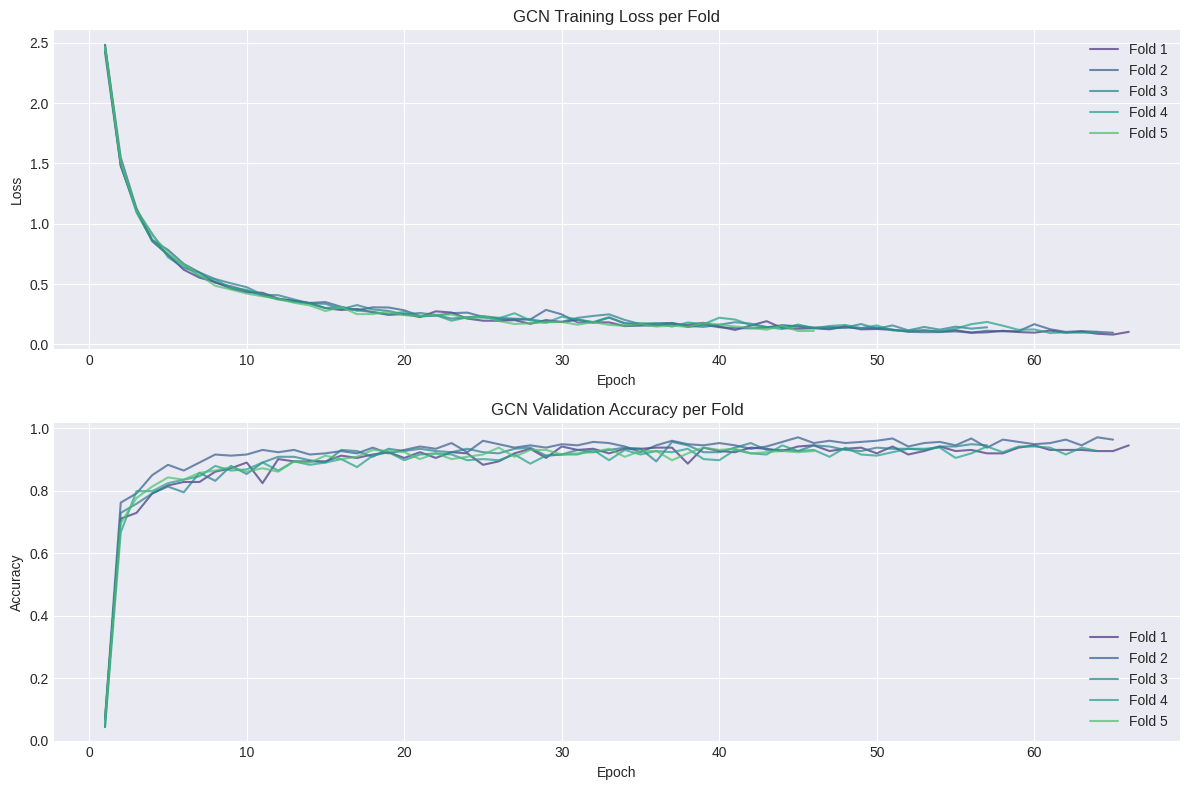

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
for res in gcn_results:
    hist = res['history']
    epochs = hist['epoch']
    axes[0].plot(epochs, hist['train_loss'], label=f"Fold {res['fold']}", alpha=0.7)
    axes[1].plot(epochs, hist['val_acc'], label=f"Fold {res['fold']}", alpha=0.7)
axes[0].set_title('GCN Training Loss per Fold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[1].set_title('GCN Validation Accuracy per Fold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()


<a id="9.-evaluasi-gcn-pada-test-pool-a-cross-domain-pool-b-domain-lebih-kompleks-dan-stress-test-pool-c"></a>

## **9. Evaluasi GCN pada Test (Pool A), Cross-Domain (Pool B), dan Stress Test (Pool C)**

### **9.1 Evaluasi 3 Pool**

`evaluate_full()` menghitung accuracy, precision, recall, dan F1 (weighted) sekaligus, bukan cuma akurasi supaya metrik lengkap tersedia untuk Section 16. Model GCN terbaik (dari 5-fold CV) dievaluasi pada ketiga pool: Test in-domain (Pool A), Cross-Domain (Pool B), dan Stress Test out-of-distribution (Pool C). F1 Drop dihitung dari Test → Stress Test untuk mengukur ketahanan terhadap gangguan yang belum pernah dilihat saat training.

In [ ]:
def evaluate_full(model, loader, device, is_graph=True):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for data in loader:
            if is_graph:
                data = data.to(device)
                out = model(data)
                pred = out.argmax(dim=1)
                preds.append(pred.cpu())
                trues.append(data.y.cpu())
            else:
                x, y = data
                x = x.to(device)
                out = model(x)
                pred = out.argmax(dim=1)
                preds.append(pred.cpu())
                trues.append(y)
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    acc = accuracy_score(trues, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(trues, preds, average='weighted')
    return acc, precision, recall, f1, preds, trues

test_loader_gcn = PyGDataLoader(test_graphs, batch_size=32, shuffle=False)
robust_loader_gcn = PyGDataLoader(robust_graphs, batch_size=32, shuffle=False)
stress_loader_gcn = PyGDataLoader(stress_graphs, batch_size=32, shuffle=False)

# ---- Evaluasi GCN (accuracy, precision, recall, F1 pada 3 pool) ----
print("\n=== Evaluasi GCN (best from CV) ===")
best_gcn_model = best_gcn_model.to(device)
acc_test_gcn, prec_test_gcn, rec_test_gcn, f1_test_gcn, preds_gcn, trues_gcn = evaluate_full(best_gcn_model, test_loader_gcn, device, is_graph=True)
acc_rob_gcn, prec_rob_gcn, rec_rob_gcn, f1_rob_gcn, _, _ = evaluate_full(best_gcn_model, robust_loader_gcn, device, is_graph=True)
acc_stress_gcn, prec_stress_gcn, rec_stress_gcn, f1_stress_gcn, _, _ = evaluate_full(best_gcn_model, stress_loader_gcn, device, is_graph=True)

# F1 Drop dihitung terhadap Pool C (stress test / domain lebih sulit), bukan Pool B -
# supaya metrik ini benar-benar mengukur ketahanan terhadap gangguan, sesuai klaim di gap penelitian.
f1_drop_gcn = (f1_test_gcn - f1_stress_gcn) / f1_test_gcn * 100 if f1_test_gcn > 0 else 0
n_params_gcn = sum(p.numel() for p in best_gcn_model.parameters())
print(f"Test (Pool A, in-domain): Acc={acc_test_gcn:.4f}, Precision={prec_test_gcn:.4f}, Recall={rec_test_gcn:.4f}, F1={f1_test_gcn:.4f}")
print(f"Cross-Domain Simple (Pool B): Acc={acc_rob_gcn:.4f}, Precision={prec_rob_gcn:.4f}, Recall={rec_rob_gcn:.4f}, F1={f1_rob_gcn:.4f}")
print(f"Stress Test (Pool C, harder domain): Acc={acc_stress_gcn:.4f}, Precision={prec_stress_gcn:.4f}, Recall={rec_stress_gcn:.4f}, F1={f1_stress_gcn:.4f}")
print(f"F1 Drop (Test -> Stress Test): {f1_drop_gcn:.2f}%")
print(f"Parameters: {n_params_gcn}")

# ---- End-to-end accuracy (detection_rate x classification_acc) ----
detection_rate_main = detection_main['detected'] / detection_main['total'] if detection_main['total'] > 0 else 0
end_to_end_acc_gcn = detection_rate_main * acc_test_gcn
print("\n=== End-to-End Accuracy (detection_rate x classification_acc) ===")
print(f"Detection rate (Pool A): {detection_rate_main:.4f}")
print(f"GCN end-to-end: {end_to_end_acc_gcn:.4f}")



=== Evaluasi GCN (best from CV) ===
Test (Pool A, in-domain): Acc=0.9733, Precision=0.9800, Recall=0.9733, F1=0.9726
Cross-Domain Simple (Pool B): Acc=0.8407, Precision=0.8582, Recall=0.8407, F1=0.8443
Stress Test (Pool C, harder domain): Acc=0.8094, Precision=0.8322, Recall=0.8094, F1=0.8104
F1 Drop (Test -> Stress Test): 16.67%
Parameters: 100282

=== End-to-End Accuracy (detection_rate x classification_acc) ===
Detection rate (Pool A): 1.0000
GCN end-to-end: 0.9733


<a id="10.-analisis-confusion-matrix-gcn"></a>

## **10. Analisis Confusion Matrix (GCN)**
### **10.1 Kelas Tersulit & Pasangan Huruf Mirip**

Bagian ini **dipertahankan** (khusus untuk GCN, sesuai revisi terbaru). Menganalisis kelas dengan akurasi terendah dan pasangan huruf yang paling sering tertukar ("gestur hampir identik") berdasarkan confusion matrix GCN pada Test set (Pool A). Pasangan huruf yang teridentifikasi di sini (`pairs_of_interest`) dipakai lagi di Section 15b sebagai daftar pasangan yang confusion-nya juga dicek untuk CNN, supaya perbandingan tetap apple-to-apple tanpa mengulang analisis "gestur mirip" versi CNN secara terpisah.


=== Analisis Gestur Hampir Identik (GCN) ===
Akurasi per kelas (10 kelas terendah):
  J: 0.000
  Z: 0.000
  K: 0.667
  T: 0.667
  A: 1.000
  B: 1.000
  C: 1.000
  D: 1.000
  E: 1.000
  G: 1.000

Pasangan huruf yang paling sering salah (top 10):
  1. K -> U : 1 kali
  2. T -> X : 1 kali

Pasangan huruf mirip (top 5, diambil otomatis dari confusion matrix GCN):
  K-U
  T-X

=== Analisis Pair-Specific (GCN) ===
K vs U: Total=6, Benar=5 (83.3%), Cross-confusion=1
T vs X: Total=6, Benar=5 (83.3%), Cross-confusion=1


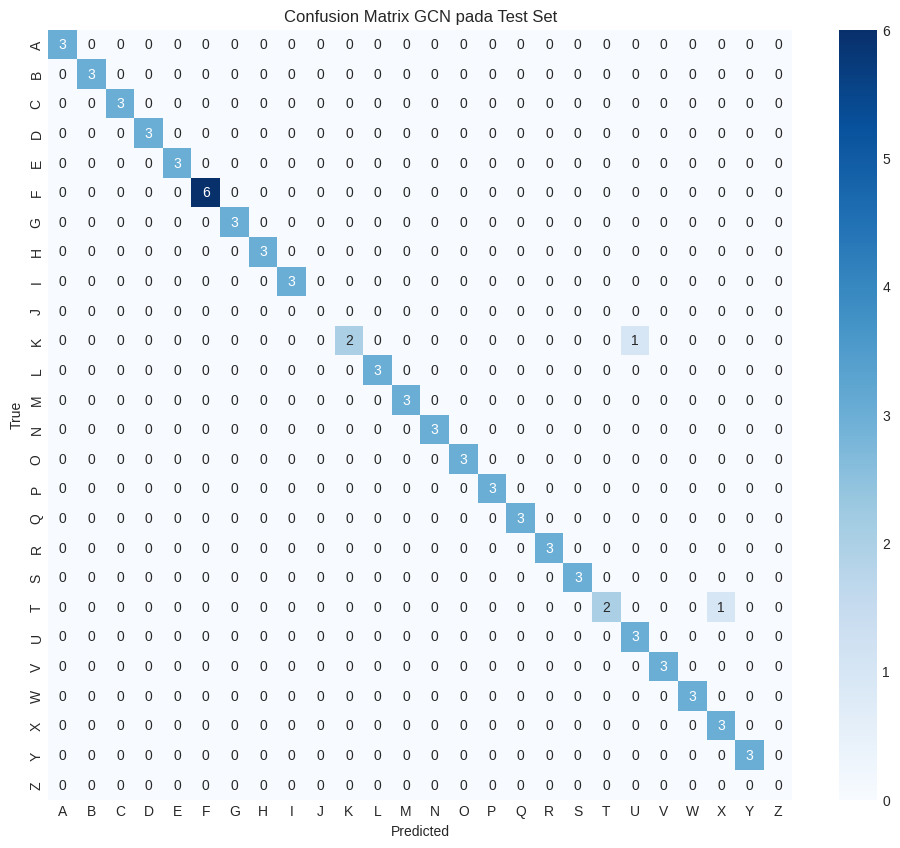

In [ ]:
cm_gcn = confusion_matrix(trues_gcn, preds_gcn, labels=range(NUM_CLASSES))

class_acc_gcn = cm_gcn.diagonal() / (cm_gcn.sum(axis=1) + 1e-10)

misclass_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_gcn[i, j] > 0:
            misclass_pairs.append((ALPHABET[i], ALPHABET[j], cm_gcn[i, j]))
misclass_pairs.sort(key=lambda x: -x[2])

print("\n=== Analisis Gestur Hampir Identik (GCN) ===")
print("Akurasi per kelas (10 kelas terendah):")
sorted_acc = sorted([(ALPHABET[i], class_acc_gcn[i]) for i in range(NUM_CLASSES)], key=lambda x: x[1])
for letter, acc in sorted_acc[:10]:
    print(f"  {letter}: {acc:.3f}")

print("\nPasangan huruf yang paling sering salah (top 10):")
for i, (true, pred, count) in enumerate(misclass_pairs[:10]):
    print(f"  {i+1}. {true} -> {pred} : {count} kali")

# =============== Pair-specific analysis (GCN) ===============
# Pasangan huruf TIDAK ditentukan manual. Diambil otomatis dari confusion matrix
# GCN di atas: confusion dua arah (A->B dan B->A) digabung jadi satu pasangan
# tak berarah, lalu diambil TOP_N_PAIRS dengan total confusion tertinggi.

def top_confused_pairs(misclass_list, top_n=5):
    '''Gabungkan confusion dua arah (A->B dan B->A) jadi satu pasangan tak
    berarah, lalu kembalikan top_n pasangan dengan total confusion tertinggi.'''
    pair_totals = {}
    for true, pred, count in misclass_list:
        key = tuple(sorted((true, pred)))
        pair_totals[key] = pair_totals.get(key, 0) + count
    sorted_pairs = sorted(pair_totals.items(), key=lambda x: -x[1])
    return [pair for pair, _ in sorted_pairs[:top_n]]

TOP_N_PAIRS = 5
pairs_of_interest = top_confused_pairs(misclass_pairs, top_n=TOP_N_PAIRS)

print(f"\nPasangan huruf mirip (top {TOP_N_PAIRS}, diambil otomatis dari confusion matrix GCN):")
for a, b in pairs_of_interest:
    print(f"  {a}-{b}")

print("\n=== Analisis Pair-Specific (GCN) ===")
for a, b in pairs_of_interest:
    idx_a, idx_b = CLASS_TO_IDX[a], CLASS_TO_IDX[b]
    mask = np.isin(trues_gcn, [idx_a, idx_b])
    subset_true = trues_gcn[mask]
    subset_pred = preds_gcn[mask]
    total = len(subset_true)
    if total == 0:
        print(f"{a} vs {b}: Tidak ada sampel di test set.")
        continue
    correct = (subset_true == subset_pred).sum()
    cross_confusion = ((subset_true == idx_a) & (subset_pred == idx_b)).sum() + \
                       ((subset_true == idx_b) & (subset_pred == idx_a)).sum()
    print(f"{a} vs {b}: Total={total}, Benar={correct} ({correct/total*100:.1f}%), Cross-confusion={cross_confusion}")

plt.figure(figsize=(12,10))
sns.heatmap(cm_gcn, annot=True, fmt='d', cmap='Blues', xticklabels=ALPHABET, yticklabels=ALPHABET)
plt.title('Confusion Matrix GCN pada Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


<a id="11.-penyimpanan-artefak-gcn"></a>

## **11. Penyimpanan Artefak (GCN)**
### **11.1 Simpan Checkpoint & Konfigurasi Bersama**

Menyimpan graf evaluasi (Pool B & C), bobot model GCN terbaik beserta metrik lengkapnya (accuracy/precision/recall/F1 di 3 pool), dan konfigurasi bersama (`shared_config.pkl`, termasuk `pairs_of_interest` yang nanti dipakai ulang oleh CNN di Section 15b) ke `ARTIFACT_DIR`.

In [ ]:
import pickle, torch

with open(os.path.join(ARTIFACT_DIR, 'gcn_eval_data.pkl'), 'wb') as f:
    pickle.dump({
        'test_graphs': test_graphs,
        'robust_graphs': robust_graphs,   # Pool B - Cross-Domain Simple
        'stress_graphs': stress_graphs,   # Pool C - Stress Test
    }, f)
print("Tersimpan: gcn_eval_data.pkl")

torch.save({
    'model_state_dict': best_gcn_model.state_dict(),
    'model_kwargs': {'in_channels': 5, 'hidden_channels': 208, 'num_classes': NUM_CLASSES, 'dropout': 0.2},  # [PATCH]
    'fold_results': gcn_results,
    'best_fold_idx': best_gcn_idx,
    'test_metrics': {'accuracy': acc_test_gcn, 'precision': prec_test_gcn, 'recall': rec_test_gcn, 'f1': f1_test_gcn},
    'cross_domain_simple_metrics': {'accuracy': acc_rob_gcn, 'precision': prec_rob_gcn, 'recall': rec_rob_gcn, 'f1': f1_rob_gcn},
    'stress_test_metrics': {'accuracy': acc_stress_gcn, 'precision': prec_stress_gcn, 'recall': rec_stress_gcn, 'f1': f1_stress_gcn, 'f1_drop_pct': f1_drop_gcn},
    'params': n_params_gcn,
}, os.path.join(ARTIFACT_DIR, 'gcn_results.pt'))
print("Tersimpan: gcn_results.pt")

with open(os.path.join(ARTIFACT_DIR, 'shared_config.pkl'), 'wb') as f:
    pickle.dump({
        'CLASS_TO_IDX': CLASS_TO_IDX, 'IDX_TO_CLASS': IDX_TO_CLASS,
        'NUM_CLASSES': NUM_CLASSES, 'ALPHABET': ALPHABET, 'CONFIG': CONFIG,
        'MAIN_DATASET': MAIN_DATASET, 'ROBUST_DATASET': ROBUST_DATASET, 'STRESS_DATASET': STRESS_DATASET,
        'BASE_DATA_DIR': BASE_DATA_DIR,
        'pairs_of_interest': pairs_of_interest,  # pasangan huruf mirip, hasil top-N confusion matrix GCN
    }, f)
print("Tersimpan: shared_config.pkl")

print(f"\nSemua artefak GCN tersimpan di: {ARTIFACT_DIR}")
print("Lanjutkan ke training CNN (Section 12 dst.) untuk perbandingan.")


Tersimpan: gcn_eval_data.pkl
Tersimpan: gcn_results.pt
Tersimpan: shared_config.pkl

Semua artefak GCN tersimpan di: /kaggle/working/sibi_artifacts
Lanjutkan ke training CNN (Section 12 dst.) untuk perbandingan.


<a id="12.-cnn-pixel-based-dataset-gambar-untuk-perbandingan-yang-fair"></a>

## **12. CNN (Pixel-Based): Dataset Gambar untuk Perbandingan yang Fair**
### **12.1 Menyiapkan Dataset Gambar yang Setara dengan GCN**

Supaya perbandingan dengan GCN benar-benar adil, CNN di sini:

- **Memakai sample & split yang identik**: hanya gambar yang landmark-nya berhasil dideteksi (`detected=True`), sesuai urutan iterasi yang sama seperti `prepare_pyg_data()` pada graf GCN.
- **Memakai `StratifiedKFold(random_state=42)` yang sama** → karena data & seed identik, isi tiap fold (indeks train/val) akan **sama persis** dengan fold GCN, jadi bukan cuma jumlah sampel yang sama tapi split-nya juga.
- **Memakai `CONFIG` yang sama** (epochs, lr, weight_decay, patience, batch_size) dan optimizer/scheduler yang sama (Adam + CosineAnnealingLR).
- **Jumlah parameter disetarakan** (lihat Section 13) agar perbandingan akurasi vs kompleksitas model juga adil, bukan cuma akurasi vs akurasi.
- **Tidak ada augmentasi tambahan** (`RandomRotation`, `ColorJitter` dihilangkan): training transform CNN sekarang identik dengan eval transform, supaya sejajar dengan GCN yang juga tidak menerima augmentasi apapun pada landmark-nya.

<a id="12.1.1-setup-transform-gambar-cnn"></a>

**12.1.1 Setup & Transform Gambar CNN**

Instalasi `torchvision` dan definisi transform preprocessing gambar untuk CNN. **Catatan fairness**: augmentasi (`RandomRotation`, `ColorJitter`) sengaja dihilangkan, GCN tidak menerima augmentasi apapun pada koordinat landmark-nya, jadi supaya perbandingan representasi graf vs piksel murni mengukur representasi (bukan bonus regularisasi dari augmentasi), transform training CNN dibuat identik dengan transform eval-nya: cuma resize + normalize.


In [ ]:
!pip install torchvision -q

from torch.utils.data import Dataset as TorchDataset
from PIL import Image
import torchvision.transforms as T

IMG_SIZE = 64  # kecil supaya waktu training tetap wajar

img_transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    # Mean/std ImageNet standar -- dipakai meski model dilatih dari nol, sekadar
    # konvensi normalisasi yang umum dipakai & stabil secara numerik.
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
img_transform_eval = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


<a id="12.1.2-class-handimagedataset"></a>

**12.1.2 Class `HandImageDataset`**

Dataset PyTorch standar yang membaca gambar dari path, menerapkan transform, dan mengembalikan pasangan (tensor gambar, label), dipakai sebagai input DataLoader untuk training/evaluasi CNN.

**Parameter:**
- `paths: list path file gambar`
- `labels: list/array label kelas (int)`
- `transform: pipeline torchvision.transforms`

**Return:** Instance Dataset yang mengembalikan (tensor_gambar, label) per index


In [ ]:
class HandImageDataset(TorchDataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')   # paksa 3-channel RGB (jaga-jaga ada grayscale/RGBA)
        img = self.transform(img)                          # resize + ToTensor + normalize
        label = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return img, label


<a id="12.1.3-fungsi-get_flat_image_paths"></a>

**12.1.3 Fungsi `get_flat_image_paths()`**

Mengekstrak path gambar & label kelas dari cache data, dengan urutan iterasi yang identik dengan `prepare_pyg_data()`, ini krusial agar subset sampel CNN sama persis dengan subset sampel GCN (fairness perbandingan).

**Parameter:**
- `cache_data: dict hasil ekstraksi landmark`
- `splits: list nama split yang mau diambil`

**Return:** Tuple (list path gambar, array label kelas)


In [ ]:
def get_flat_image_paths(cache_data, splits=['train', 'val']):
    paths, labels = [], []
    for split in splits:
        for item in cache_data['data']:
            if item['split'] != split:
                continue
            if not item['detected']:
                continue          # buang sampel yang landmark-nya gagal dideteksi (sama seperti GCN)
            paths.append(item['path'])
            labels.append(CLASS_TO_IDX[item['label']])
    return paths, np.array(labels)

<a id="12.1.4-eksekusi-menyusun-path-gambar-sanity-check-fairness"></a>

**12.1.4 Eksekusi: Menyusun Path Gambar & Sanity Check Fairness**

Memanggil `get_flat_image_paths()` untuk keempat kebutuhan data (train+val, test, cross-domain Pool B, stress test Pool C), lalu menjalankan `assert` untuk memastikan jumlah sampel CNN identik dengan jumlah sampel graf GCN di semua pool, syarat mutlak supaya perbandingan kedua model adil.


In [ ]:
# Ambil path gambar untuk keempat kebutuhan: train+val, test, cross-domain (B), stress (C)
paths_train_val_cnn, y_train_val_cnn = get_flat_image_paths(main_data, ['train', 'val'])
paths_test_cnn, y_test_cnn = get_flat_image_paths(main_data, ['test'])
paths_robust_cnn, y_robust_cnn = get_flat_image_paths(robust_data, ['train', 'val', 'test'])
paths_stress_cnn, y_stress_cnn = get_flat_image_paths(stress_data, ['stress'])

print(f"CNN train+val: {len(paths_train_val_cnn)} | test: {len(paths_test_cnn)} | "
      f"cross-domain simple: {len(paths_robust_cnn)} | stress test: {len(paths_stress_cnn)}")

# Sanity check: jumlah sample HARUS sama dengan GCN kalau mau dibilang fair
assert len(paths_train_val_cnn) == len(train_val_graphs), "Jumlah sampel CNN train+val tidak sama dgn GCN!"
assert len(paths_test_cnn) == len(test_graphs), "Jumlah sampel CNN test tidak sama dgn GCN!"
assert len(paths_robust_cnn) == len(robust_graphs), "Jumlah sampel CNN cross-domain simple tidak sama dgn GCN!"
assert len(paths_stress_cnn) == len(stress_graphs), "Jumlah sampel CNN stress test tidak sama dgn GCN!"
print("Sanity check OK: jumlah sampel CNN identik dengan GCN di semua pool.")

<a id="13.-arsitektur-cnn-ringan-parameter-setara-gcn"></a>

## **13. Arsitektur CNN Ringan (Parameter Setara GCN)**
### **13.1 Kelas `SimpleCNN`**

`SimpleCNN` didesain memakai **Global Average Pooling** (bukan `Flatten` + FC besar) supaya jumlah parameter tidak meledak dan tetap sebanding dengan LightweightGCN (~90-105 ribu parameter). Arsitektur: 4 blok Conv-BN-ReLU dengan MaxPool bertahap, diakhiri `AdaptiveAvgPool2d` dan satu linear layer klasifikasi.

In [ ]:
class SimpleCNN(nn.Module):
    '''
    CNN pixel-based dengan jumlah parameter didesain sebanding dengan
    LightweightGCN (~104k), supaya perbandingan akurasi & efisiensi
    antar arsitektur adil (apple-to-apple).
    '''
    def __init__(self, num_classes=26, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            # Blok 1: 3 -> 16 channel, spatial 64x64 -> 32x32
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),   # 64->32
            # Blok 2: 16 -> 32 channel, spatial 32x32 -> 16x16
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),  # 32->16
            # Blok 3: 32 -> 64 channel, spatial 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 16->8
            # Blok 4: 64 -> 128 channel, TANPA MaxPool lagi -- langsung diringkas oleh AdaptiveAvgPool2d(1)
            # (Global Average Pooling) supaya tidak perlu Flatten + FC besar (hemat parameter, ini kunci
            # supaya jumlah parameter CNN tetap sebanding dengan GCN)
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),   # (batch, 128, 8, 8) -> (batch, 128, 1, 1)
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, num_classes)   # classifier akhir: 128 fitur -> 26 kelas huruf

    def forward(self, x):
        x = self.features(x)      # ekstraksi fitur konvolusional -> (batch, 128, 1, 1)
        x = x.flatten(1)          # ratakan jadi (batch, 128)
        x = self.dropout(x)
        return self.fc(x)         # logit mentah per kelas (26 huruf)

_tmp_model = SimpleCNN()
n_params_cnn_check = sum(p.numel() for p in _tmp_model.parameters())
print(f"Jumlah parameter SimpleCNN : {n_params_cnn_check:,}")
print(f"Pembanding -> GCN: {n_params_gcn:,}")
del _tmp_model


Jumlah parameter SimpleCNN : 101,274
Pembanding -> GCN: 100,282


<a id="14.-training-cnn-5-fold-cv-pengukuran-waktu-training"></a>

## **14. Training CNN (5-Fold CV) + Pengukuran Waktu Training**
### **14.1 Fungsi `train_cnn_fold()`**

Loop training CNN dibuat manual (bukan pakai `run_all_folds` yang khusus PyG) karena formatnya beda: `DataLoader` biasa dengan tensor gambar, bukan `PyGDataLoader` dengan objek graf. Selebihnya logikanya identik dengan GCN: Adam + CosineAnnealingLR, early stopping berdasar val accuracy, 5-fold `StratifiedKFold(random_state=42)` (sehingga foldnya sama persis dengan GCN karena data & seed identik).

In [ ]:
def train_cnn_fold(train_paths, train_labels, val_paths, val_labels, config, num_workers=2):
    train_ds = HandImageDataset(train_paths, train_labels, img_transform_train)
    val_ds = HandImageDataset(val_paths, val_labels, img_transform_eval)
    train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=config['batch_size'], shuffle=False, num_workers=num_workers)

    model = SimpleCNN(num_classes=NUM_CLASSES, dropout=0.3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'])
    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    best_model_state = None
    history = {'train_loss': [], 'val_acc': [], 'epoch': []}
    patience_counter = 0

    for epoch in range(1, config['epochs'] + 1):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        scheduler.step()

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                out = model(xb)
                pred = out.argmax(dim=1)
                preds.append(pred.cpu())
                trues.append(yb)
        preds = torch.cat(preds).numpy()
        trues = torch.cat(trues).numpy()
        val_acc = accuracy_score(trues, preds)

        history['train_loss'].append(total_loss / len(train_loader.dataset))
        history['val_acc'].append(val_acc)
        history['epoch'].append(epoch)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    model.load_state_dict(best_model_state)
    return model, best_acc, history

<a id="14.2-eksekusi-5-fold-cross-validation-untuk-cnn"></a>

### **14.2 Eksekusi 5-Fold Cross-Validation untuk CNN**

In [ ]:
print("\n=== Running 5-Fold CV for CNN (pixel-based) ===")
_t0 = time.time()
cnn_results, cnn_models = [], []
skf_cnn = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
paths_train_val_arr = np.array(paths_train_val_cnn)
for fold, (train_idx, val_idx) in enumerate(skf_cnn.split(paths_train_val_arr, y_train_val_cnn)):
    print(f"Fold {fold+1}/5")
    tr_paths = paths_train_val_arr[train_idx].tolist()
    va_paths = paths_train_val_arr[val_idx].tolist()
    tr_labels = y_train_val_cnn[train_idx]
    va_labels = y_train_val_cnn[val_idx]
    model, best_acc, history = train_cnn_fold(tr_paths, tr_labels, va_paths, va_labels, CONFIG)
    cnn_results.append({'fold': fold + 1, 'best_acc': best_acc, 'history': history})
    cnn_models.append(model)
training_times['CNN'] = time.time() - _t0

cnn_accs = [f['best_acc'] for f in cnn_results]
print(f"\nCNN mean ± std: {np.mean(cnn_accs):.4f} ± {np.std(cnn_accs):.4f}  | waktu: {training_times['CNN']/60:.2f} menit")

best_cnn_idx = int(np.argmax(cnn_accs))
best_cnn_model = cnn_models[best_cnn_idx]
print(f"Best CNN fold {best_cnn_idx+1} dengan akurasi {cnn_accs[best_cnn_idx]:.4f}")


=== Running 5-Fold CV for CNN (pixel-based) ===
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5

CNN mean ± std: 0.8718 ± 0.0291  | waktu: 28.85 menit
Best CNN fold 2 dengan akurasi 0.9048


<a id="15.-evaluasi-cnn-pada-test-pool-a-cross-domain-pool-b-domain-lebih-kompleks-dan-stress-test-pool-c"></a>

## **15. Evaluasi CNN pada Test (Pool A), Cross-Domain (Pool B), dan Stress Test (Pool C)**

### **15.1 Evaluasi 3 Pool untuk CNN**

Sama seperti GCN di Section 9, dievaluasi accuracy, precision, recall, dan F1 (weighted) pada ketiga pool memakai `evaluate_full()` yang sama.

In [ ]:
test_ds_cnn = HandImageDataset(paths_test_cnn, y_test_cnn, img_transform_eval)
robust_ds_cnn = HandImageDataset(paths_robust_cnn, y_robust_cnn, img_transform_eval)
stress_ds_cnn = HandImageDataset(paths_stress_cnn, y_stress_cnn, img_transform_eval)
test_loader_cnn = DataLoader(test_ds_cnn, batch_size=32, shuffle=False)
robust_loader_cnn = DataLoader(robust_ds_cnn, batch_size=32, shuffle=False)
stress_loader_cnn = DataLoader(stress_ds_cnn, batch_size=32, shuffle=False)

print("\n=== Evaluasi CNN (best from CV) ===")
best_cnn_model = best_cnn_model.to(device)
acc_test_cnn, prec_test_cnn, rec_test_cnn, f1_test_cnn, preds_cnn, trues_cnn = evaluate_full(best_cnn_model, test_loader_cnn, device, is_graph=False)
acc_rob_cnn, prec_rob_cnn, rec_rob_cnn, f1_rob_cnn, _, _ = evaluate_full(best_cnn_model, robust_loader_cnn, device, is_graph=False)
acc_stress_cnn, prec_stress_cnn, rec_stress_cnn, f1_stress_cnn, _, _ = evaluate_full(best_cnn_model, stress_loader_cnn, device, is_graph=False)

# F1 Drop dihitung terhadap Pool C (stress test), konsisten dengan definisi GCN di atas.
f1_drop_cnn = (f1_test_cnn - f1_stress_cnn) / f1_test_cnn * 100 if f1_test_cnn > 0 else 0
n_params_cnn = sum(p.numel() for p in best_cnn_model.parameters())
print(f"Test (Pool A, in-domain): Acc={acc_test_cnn:.4f}, Precision={prec_test_cnn:.4f}, Recall={rec_test_cnn:.4f}, F1={f1_test_cnn:.4f}")
print(f"Cross-Domain Simple (Pool B): Acc={acc_rob_cnn:.4f}, Precision={prec_rob_cnn:.4f}, Recall={rec_rob_cnn:.4f}, F1={f1_rob_cnn:.4f}")
print(f"Stress Test (Pool C, harder domain): Acc={acc_stress_cnn:.4f}, Precision={prec_stress_cnn:.4f}, Recall={rec_stress_cnn:.4f}, F1={f1_stress_cnn:.4f}")
print(f"F1 Drop (Test -> Stress Test): {f1_drop_cnn:.2f}%")
print(f"Parameters: {n_params_cnn}")



=== Evaluasi CNN (best from CV) ===
Test (Pool A, in-domain): Acc=0.6133, Precision=0.6580, Recall=0.6133, F1=0.5755
Cross-Domain Simple (Pool B): Acc=0.0778, Precision=0.0975, Recall=0.0778, F1=0.0484
Stress Test (Pool C, harder domain): Acc=0.0764, Precision=0.1006, Recall=0.0764, F1=0.0529
F1 Drop (Test -> Stress Test): 90.81%
Parameters: 101274


<a id="15b.-metrik-klasifikasi-lengkap-accuracy-precision-recall-f1-gcn-vs-cnn"></a>

## **15b. Metrik Klasifikasi Lengkap: Accuracy, Precision, Recall, F1 (GCN vs CNN)**
### **15b.1 Confusion Matrix CNN**

Section ini menggantikan analisis "gestur hampir identik" versi CNN yang sebelumnya ada di sini, analisis pasangan-huruf-mirip kini **hanya dipertahankan untuk GCN** (Section 10), supaya tidak duplikatif. Sebagai gantinya, section ini menyajikan **confusion matrix CNN** (evaluasi umum, bukan analisis pasangan huruf spesifik) serta **tabel & visualisasi lengkap** accuracy/precision/recall/F1 untuk kedua model pada ketiga pool sekaligus.

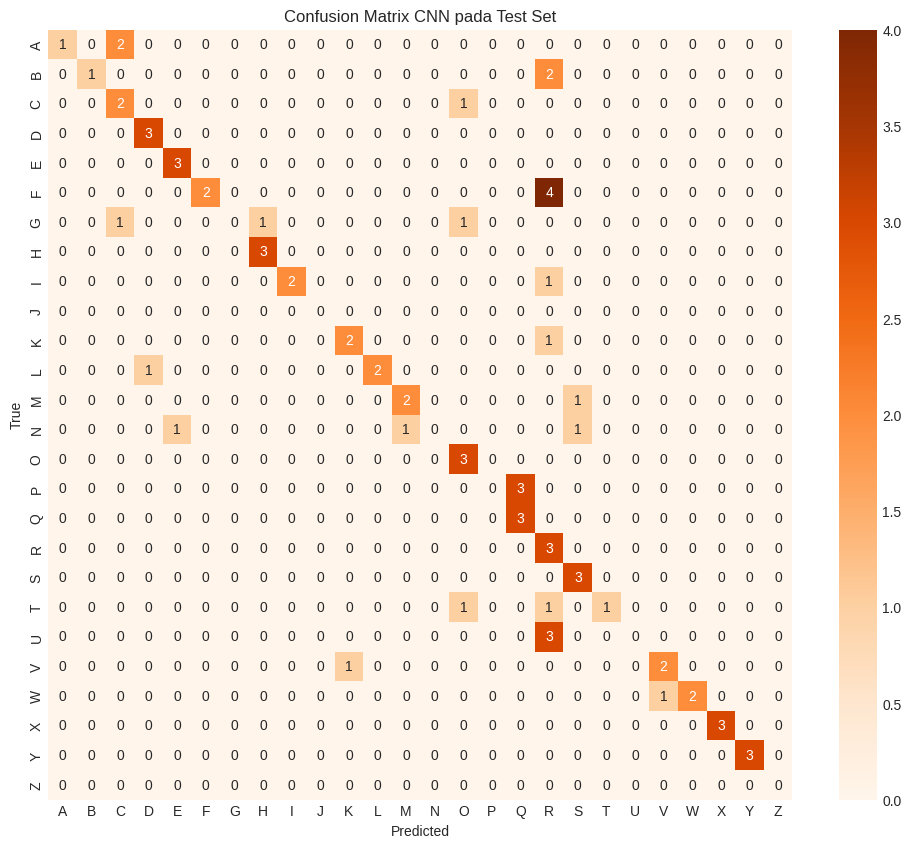


=== Classification Report CNN (Test set, Pool A) ===
              precision    recall  f1-score   support

           A      1.000     0.333     0.500         3
           B      1.000     0.333     0.500         3
           C      0.400     0.667     0.500         3
           D      0.750     1.000     0.857         3
           E      0.750     1.000     0.857         3
           F      1.000     0.333     0.500         6
           G      0.000     0.000     0.000         3
           H      0.750     1.000     0.857         3
           I      1.000     0.667     0.800         3
           J      0.000     0.000     0.000         0
           K      0.667     0.667     0.667         3
           L      1.000     0.667     0.800         3
           M      0.667     0.667     0.667         3
           N      0.000     0.000     0.000         3
           O      0.500     1.000     0.667         3
           P      0.000     0.000     0.000         3
           Q      0.500    

In [ ]:
# Confusion matrix CNN (evaluasi umum saja, TANPA analisis pasangan-huruf-mirip)
cm_cnn = confusion_matrix(trues_cnn, preds_cnn, labels=range(NUM_CLASSES))

plt.figure(figsize=(12, 10))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges', xticklabels=ALPHABET, yticklabels=ALPHABET)
plt.title('Confusion Matrix CNN pada Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\n=== Classification Report CNN (Test set, Pool A) ===")
print(classification_report(
    trues_cnn, preds_cnn,
    labels=range(NUM_CLASSES),
    target_names=ALPHABET,
    digits=3,
    zero_division=0  
))

print("\n=== Classification Report GCN (Test set, Pool A) ===")
print(classification_report(
    trues_gcn, preds_gcn,
    labels=range(NUM_CLASSES),
    target_names=ALPHABET,
    digits=3,
    zero_division=0
))

<a id="15b.2-tabel-metrik-lengkap-accuracyprecisionrecallf1-model-pool"></a>

### **15b.2 Tabel Metrik Lengkap (Accuracy/Precision/Recall/F1 × Model × Pool)**

=== Tabel Metrik Lengkap (Accuracy, Precision, Recall, F1) ===
Model                         Pool  Accuracy  Precision   Recall  F1-Score
  GCN                Test (Pool A)  0.973333   0.980000 0.973333  0.972571
  GCN Cross-Domain Simple (Pool B)  0.840687   0.858236 0.840687  0.844254
  GCN         Stress Test (Pool C)  0.809404   0.832156 0.809404  0.810399
  CNN                Test (Pool A)  0.613333   0.658000 0.613333  0.575524
  CNN Cross-Domain Simple (Pool B)  0.077768   0.097525 0.077768  0.048410
  CNN         Stress Test (Pool C)  0.076406   0.100626 0.076406  0.052884


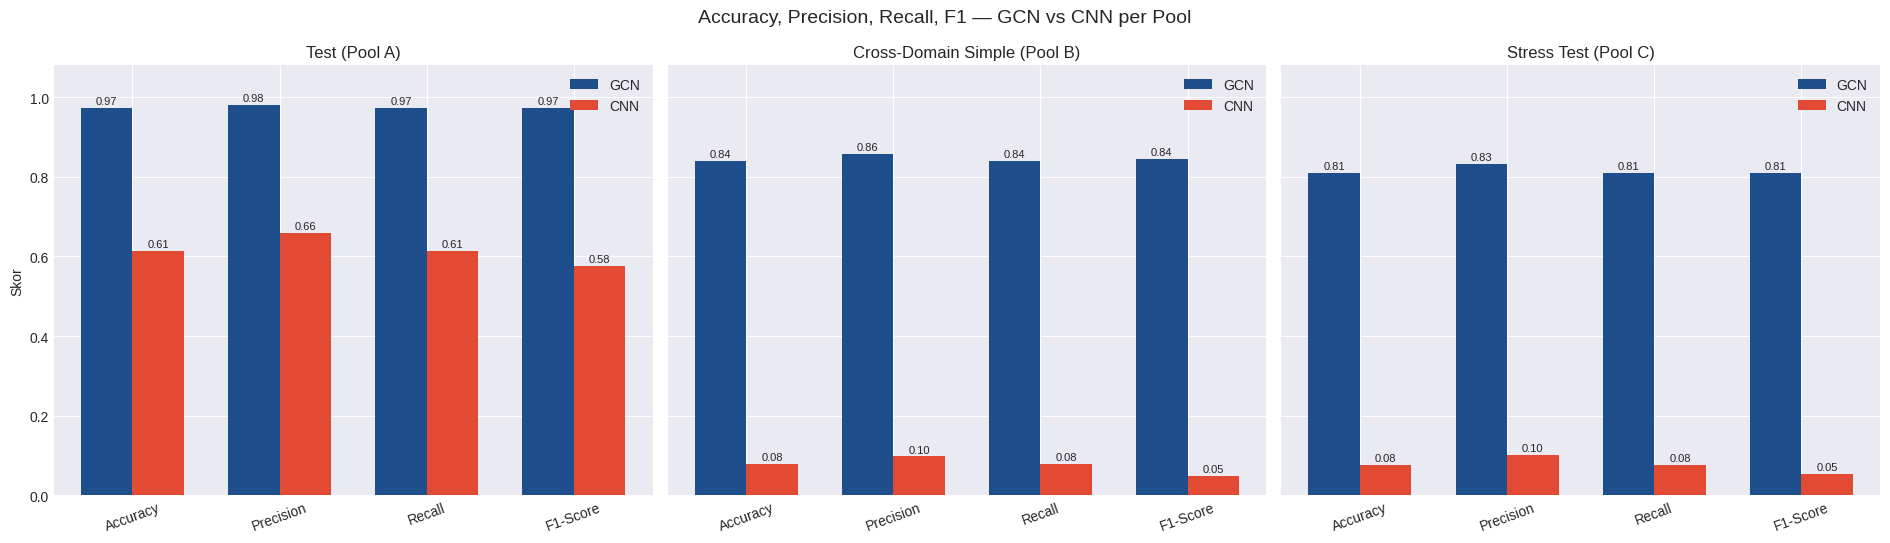

In [ ]:
# Tabel metrik lengkap: Accuracy, Precision, Recall, F1 x (GCN, CNN) x (Pool A, B, C)
metrics_rows = []
for model_name, pool_name, acc, prec, rec, f1 in [
    ('GCN', 'Test (Pool A)',            acc_test_gcn,   prec_test_gcn,   rec_test_gcn,   f1_test_gcn),
    ('GCN', 'Cross-Domain Simple (Pool B)', acc_rob_gcn, prec_rob_gcn,   rec_rob_gcn,    f1_rob_gcn),
    ('GCN', 'Stress Test (Pool C)',     acc_stress_gcn, prec_stress_gcn, rec_stress_gcn, f1_stress_gcn),
    ('CNN', 'Test (Pool A)',            acc_test_cnn,   prec_test_cnn,   rec_test_cnn,   f1_test_cnn),
    ('CNN', 'Cross-Domain Simple (Pool B)', acc_rob_cnn, prec_rob_cnn,   rec_rob_cnn,    f1_rob_cnn),
    ('CNN', 'Stress Test (Pool C)',     acc_stress_cnn, prec_stress_cnn, rec_stress_cnn, f1_stress_cnn),
]:
    metrics_rows.append({
        'Model': model_name, 'Pool': pool_name,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1,
    })
metrics_df = pd.DataFrame(metrics_rows)
print("=== Tabel Metrik Lengkap (Accuracy, Precision, Recall, F1) ===")
print(metrics_df.to_string(index=False))

# ---- Visualisasi: grouped bar per pool, 4 metrik x 2 model ----
pools_order = ['Test (Pool A)', 'Cross-Domain Simple (Pool B)', 'Stress Test (Pool C)']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), sharey=True)
for ax, pool in zip(axes, pools_order):
    sub = metrics_df[metrics_df['Pool'] == pool]
    gcn_vals = sub[sub['Model'] == 'GCN'][metric_names].values.flatten()
    cnn_vals = sub[sub['Model'] == 'CNN'][metric_names].values.flatten()
    x = np.arange(len(metric_names))
    width = 0.35
    ax.bar(x - width/2, gcn_vals, width, label='GCN', color=COLOR_GCN)
    ax.bar(x + width/2, cnn_vals, width, label='CNN', color=COLOR_CNN)
    for xi, (gv, cv) in enumerate(zip(gcn_vals, cnn_vals)):
        ax.text(xi - width/2, gv + 0.01, f'{gv:.2f}', ha='center', fontsize=8)
        ax.text(xi + width/2, cv + 0.01, f'{cv:.2f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(metric_names, rotation=20)
    ax.set_ylim(0, 1.08)
    ax.set_title(pool)
    ax.legend()
axes[0].set_ylabel('Skor')
plt.suptitle('Accuracy, Precision, Recall, F1 — GCN vs CNN per Pool', fontsize=14)
plt.tight_layout()
plt.show()


<a id="16.-perbandingan-akhir-gcn-vs-cnn-pixel-based"></a>

## **16. Perbandingan Akhir: GCN vs CNN (Pixel-Based)**
### **16.1 Tabel Perbandingan Lengkap**

Menggabungkan GCN dan CNN dalam satu tabel + beberapa grafik: akurasi & F1 di 3 pool, waktu training, trade-off akurasi-vs-waktu, dan kurva training loss/akurasi. **Kurva training GCN vs CNN memakai warna & gaya garis yang kontras** (GCN = biru solid, CNN = merah-oranye putus-putus) supaya mudah dibedakan sekilas, konsisten dengan `COLOR_GCN`/`COLOR_CNN` yang didefinisikan di Section 1.

In [ ]:
models2 = ['GCN', 'CNN']
test_accs2 = [acc_test_gcn, acc_test_cnn]
test_precs2 = [prec_test_gcn, prec_test_cnn]
test_recs2 = [rec_test_gcn, rec_test_cnn]
test_f1s2 = [f1_test_gcn, f1_test_cnn]
rob_accs2 = [acc_rob_gcn, acc_rob_cnn]           # Pool B - Cross-Domain Simple
rob_f1s2 = [f1_rob_gcn, f1_rob_cnn]
stress_accs2 = [acc_stress_gcn, acc_stress_cnn]  # Pool C - Stress Test
stress_f1s2 = [f1_stress_gcn, f1_stress_cnn]
drops2 = [f1_drop_gcn, f1_drop_cnn]              # dihitung Test -> Stress Test
params2 = [n_params_gcn, n_params_cnn]
times2_min = [training_times['GCN']/60, training_times['CNN']/60]

comparison_df2 = pd.DataFrame({
    'Model': models2,
    'Test Acc (Pool A)': test_accs2,
    'Test Precision (Pool A)': test_precs2,
    'Test Recall (Pool A)': test_recs2,
    'Test F1 (Pool A)': test_f1s2,
    'Cross-Domain Simple Acc (Pool B)': rob_accs2,
    'Cross-Domain Simple F1 (Pool B)': rob_f1s2,
    'Stress Test Acc (Pool C)': stress_accs2,
    'Stress Test F1 (Pool C)': stress_f1s2,
    'F1 Drop Test->Stress (%)': drops2,
    'Params': params2,
    'Training Time (menit)': times2_min,
})
print("\nTabel Perbandingan Lengkap (GCN vs CNN, 3 Pool):")
print(comparison_df2.to_string(index=False))


Tabel Perbandingan Lengkap (GCN vs CNN, 3 Pool):
Model  Test Acc (Pool A)  Test Precision (Pool A)  Test Recall (Pool A)  Test F1 (Pool A)  Cross-Domain Simple Acc (Pool B)  Cross-Domain Simple F1 (Pool B)  Stress Test Acc (Pool C)  Stress Test F1 (Pool C)  F1 Drop Test->Stress (%)  Params  Training Time (menit)
  GCN           0.973333                    0.980              0.973333          0.972571                          0.840687                         0.844254                  0.809404                 0.810399                 16.674602  100282               3.271747
  CNN           0.613333                    0.658              0.613333          0.575524                          0.077768                         0.048410                  0.076406                 0.052884                 90.811210  101274              28.853911


<a id="16.2-grafik-accuracy-f1-3-pool"></a>

### **16.2 Grafik Accuracy & F1: 3 Pool**

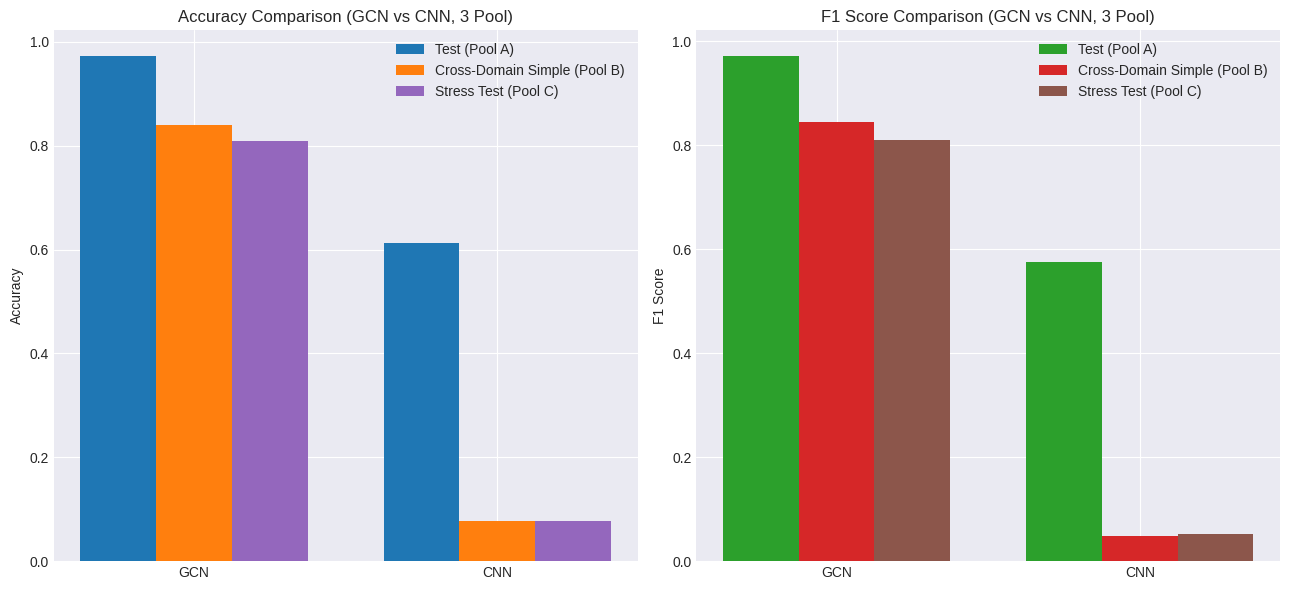

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
x = np.arange(len(models2))
width = 0.25
axes[0].bar(x - width, test_accs2, width, label='Test (Pool A)', color='#1f77b4')
axes[0].bar(x, rob_accs2, width, label='Cross-Domain Simple (Pool B)', color='#ff7f0e')
axes[0].bar(x + width, stress_accs2, width, label='Stress Test (Pool C)', color='#9467bd')
axes[0].set_ylabel('Accuracy'); axes[0].set_title('Accuracy Comparison (GCN vs CNN, 3 Pool)')
axes[0].set_xticks(x); axes[0].set_xticklabels(models2); axes[0].legend()

axes[1].bar(x - width, test_f1s2, width, label='Test (Pool A)', color='#2ca02c')
axes[1].bar(x, rob_f1s2, width, label='Cross-Domain Simple (Pool B)', color='#d62728')
axes[1].bar(x + width, stress_f1s2, width, label='Stress Test (Pool C)', color='#8c564b')
axes[1].set_ylabel('F1 Score'); axes[1].set_title('F1 Score Comparison (GCN vs CNN, 3 Pool)')
axes[1].set_xticks(x); axes[1].set_xticklabels(models2); axes[1].legend()
plt.tight_layout(); plt.show()

<a id="16.3-grafik-waktu-training"></a>

### **16.3 Grafik Waktu Training**

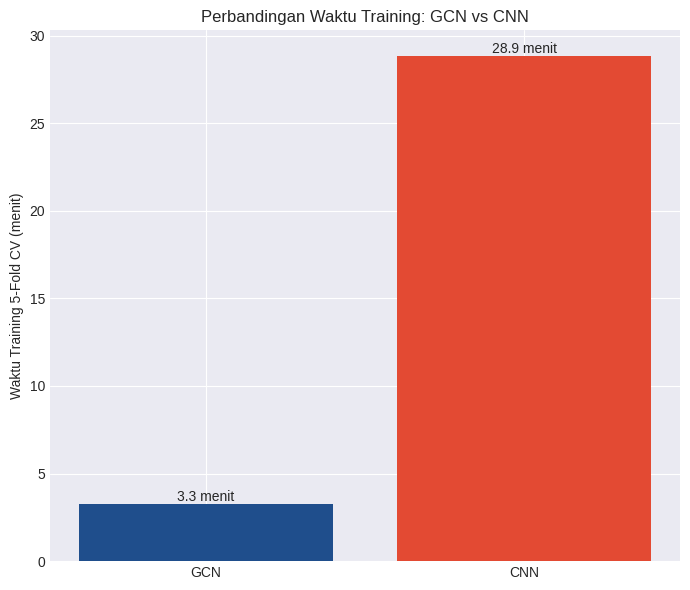

In [ ]:
plt.figure(figsize=(7, 6))
bars = plt.bar(models2, times2_min, color=[COLOR_GCN, COLOR_CNN])
plt.ylabel('Waktu Training 5-Fold CV (menit)')
plt.title('Perbandingan Waktu Training: GCN vs CNN')
for bar, t in zip(bars, times2_min):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{t:.1f} menit', ha='center', va='bottom')
plt.tight_layout(); plt.show()

<a id="16.4-grafik-trade-off-akurasi-vs-waktu-training"></a>

### **16.4 Grafik Trade-off Akurasi vs Waktu Training**

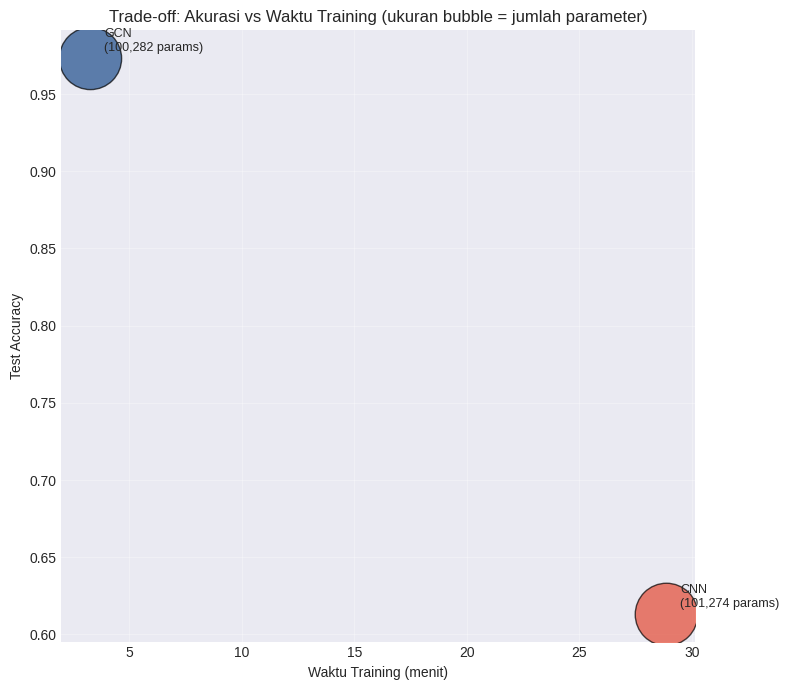

In [ ]:
plt.figure(figsize=(8, 7))
sizes = [p / 50 for p in params2]
colors_tradeoff = [COLOR_GCN, COLOR_CNN]
for i, m in enumerate(models2):
    plt.scatter(times2_min[i], test_accs2[i], s=sizes[i], color=colors_tradeoff[i], alpha=0.7, edgecolor='black')
    plt.annotate(f"{m}\n({params2[i]:,} params)", (times2_min[i], test_accs2[i]),
                 textcoords="offset points", xytext=(10, 5), fontsize=9)
plt.xlabel('Waktu Training (menit)')
plt.ylabel('Test Accuracy')
plt.title('Trade-off: Akurasi vs Waktu Training (ukuran bubble = jumlah parameter)')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

<a id="16.5-kurva-training-loss-val-accuracy-best-fold-gcn-vs-cnn"></a>

### **16.5 Kurva Training (Loss & Val Accuracy) Best Fold: GCN vs CNN**

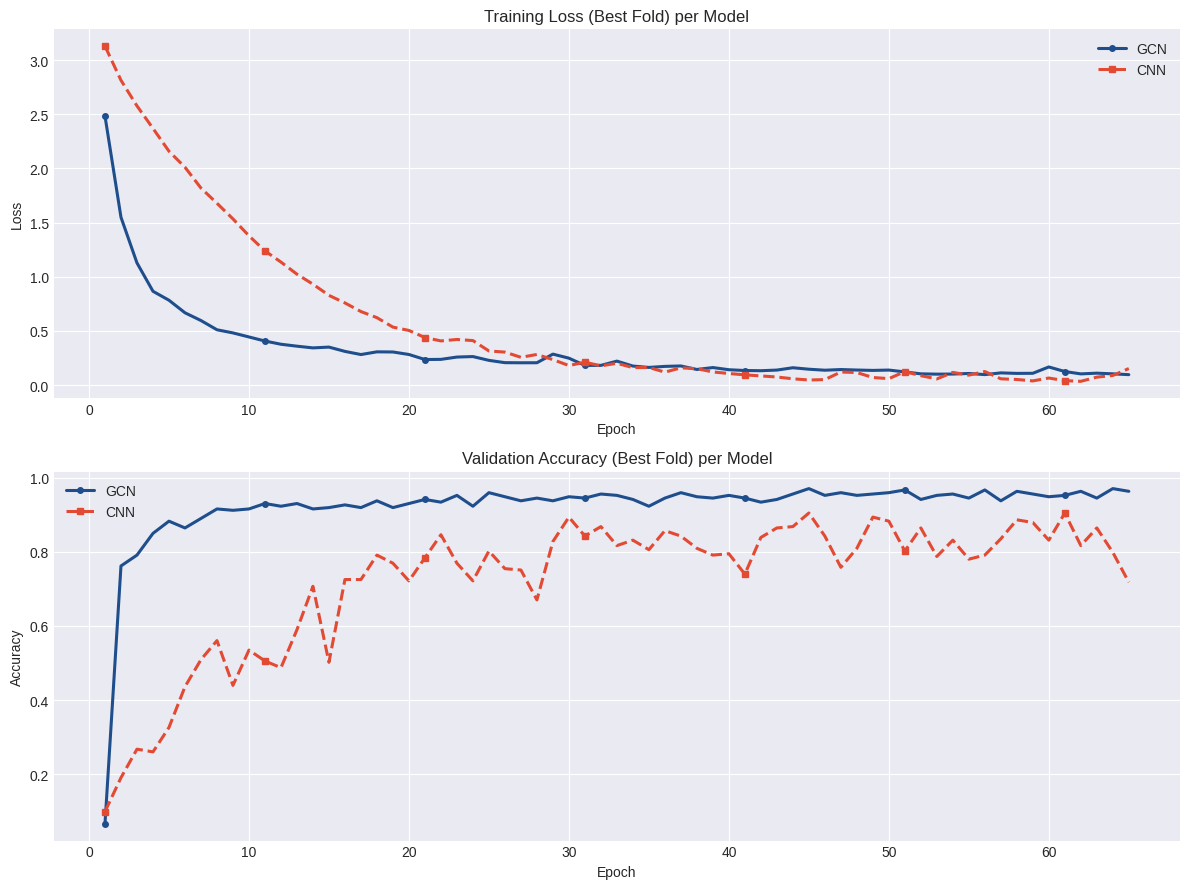

In [ ]:
# Warna & gaya garis dibuat KONTRAS: GCN = biru solid, CNN = merah-oranye putus-putus,
# ditambah marker berbeda supaya tetap terbaca walau dicetak hitam-putih.
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
best_histories = {
    'GCN': (gcn_results[best_gcn_idx]['history'], {**STYLE_GCN, 'marker': 'o', 'markevery': 10, 'markersize': 4}),
    'CNN': (cnn_results[best_cnn_idx]['history'], {**STYLE_CNN, 'marker': 's', 'markevery': 10, 'markersize': 4}),
}
for name, (hist, style) in best_histories.items():
    axes[0].plot(hist['epoch'], hist['train_loss'], label=name, **style)
    axes[1].plot(hist['epoch'], hist['val_acc'], label=name, **style)
axes[0].set_title('Training Loss (Best Fold) per Model')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].set_title('Validation Accuracy (Best Fold) per Model')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

<a id="17.-penyimpanan-artefak-cnn"></a>

## **17. Penyimpanan Artefak CNN**
### **17.1 Simpan Bobot, Metrik, dan Tabel Perbandingan**

Menyimpan bobot model CNN terbaik beserta metrik lengkapnya (accuracy/precision/recall/F1 di 3 pool), waktu training, dan tabel perbandingan akhir (`comparison_gcn_vs_cnn.csv`) ke `ARTIFACT_DIR`.

In [ ]:
torch.save({
    'model_state_dict': best_cnn_model.state_dict(),
    'model_kwargs': {'num_classes': NUM_CLASSES, 'dropout': 0.3},
    'img_size': IMG_SIZE,
    'fold_results': cnn_results,
    'best_fold_idx': best_cnn_idx,
    'test_metrics': {'accuracy': acc_test_cnn, 'precision': prec_test_cnn, 'recall': rec_test_cnn, 'f1': f1_test_cnn},
    'cross_domain_simple_metrics': {'accuracy': acc_rob_cnn, 'precision': prec_rob_cnn, 'recall': rec_rob_cnn, 'f1': f1_rob_cnn},
    'stress_test_metrics': {'accuracy': acc_stress_cnn, 'precision': prec_stress_cnn, 'recall': rec_stress_cnn, 'f1': f1_stress_cnn, 'f1_drop_pct': f1_drop_cnn},
    'params': n_params_cnn,
    'training_time_seconds': training_times['CNN'],
}, os.path.join(ARTIFACT_DIR, 'cnn_results.pt'))
print("Tersimpan: cnn_results.pt")

with open(os.path.join(ARTIFACT_DIR, 'training_times.pkl'), 'wb') as f:
    pickle.dump(training_times, f)
print("Tersimpan: training_times.pkl")

comparison_df2.to_csv(os.path.join(ARTIFACT_DIR, 'comparison_gcn_vs_cnn.csv'), index=False)
print("Tersimpan: comparison_gcn_vs_cnn.csv")

metrics_df.to_csv(os.path.join(ARTIFACT_DIR, 'metrics_full_gcn_vs_cnn.csv'), index=False)
print("Tersimpan: metrics_full_gcn_vs_cnn.csv")


Tersimpan: cnn_results.pt
Tersimpan: training_times.pkl
Tersimpan: comparison_gcn_vs_cnn.csv
Tersimpan: metrics_full_gcn_vs_cnn.csv


<a id="18.-inference-end-to-end-dengan-model-gcn"></a>

## **18. Inference End-to-End dengan Model GCN**
### **18.1 Fungsi Pipeline Inference (siap di-uncomment)**

Section ini menyediakan **pipeline inference siap pakai**: dari satu file gambar tangan baru → deteksi landmark (cascade yang sama seperti Section 2) → bangun graf (`build_graph`, sama seperti training) → prediksi huruf memakai model GCN terbaik. Ini melengkapi Section 11 yang sebelumnya hanya menyimpan checkpoint (`gcn_results.pt`) tanpa fungsi pemakaian langsung.

Model **dimuat ulang dari file `gcn_results.pt`** (bukan memakai variabel `best_gcn_model` yang masih ada di memori) supaya cell ini juga berfungsi sebagai contoh cara memakai model di sesi/notebook lain tanpa perlu training ulang.

In [ ]:
# from torch_geometric.data import Batch

# def load_gcn_for_inference(artifact_dir=ARTIFACT_DIR, device=device):
#     '''Muat ulang model GCN terbaik dari checkpoint tersimpan (gcn_results.pt),
#     tanpa perlu training ulang. Dipakai untuk inference di sesi baru.'''
#     ckpt_path = os.path.join(artifact_dir, 'gcn_results.pt')
#     ckpt = torch.load(ckpt_path, map_location=device)
#     model = LightweightGCN(**ckpt['model_kwargs']).to(device)
#     model.load_state_dict(ckpt['model_state_dict'])
#     model.eval()
#     print(f"Model GCN dimuat dari: {ckpt_path}")
#     print(f"Metrik saat training -> Test Acc: {ckpt['test_metrics']['accuracy']:.4f}, "
#           f"F1: {ckpt['test_metrics']['f1']:.4f}")
#     return model

# def create_inference_detectors(model_path=MODEL_PATH):
#     '''Siapkan 2 instance MediaPipe HandLandmarker (confidence normal & rendah)
#     khusus untuk inference, terpisah dari detector yang dipakai saat ekstraksi
#     dataset supaya tidak saling mengganggu jika dipanggil berurutan.'''
#     options = mp.tasks.vision.HandLandmarkerOptions(
#         base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
#         running_mode=mp.tasks.vision.RunningMode.IMAGE,
#         num_hands=1
#     )
#     options_low = mp.tasks.vision.HandLandmarkerOptions(
#         base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
#         running_mode=mp.tasks.vision.RunningMode.IMAGE,
#         num_hands=1,
#         min_hand_detection_confidence=0.15,
#         min_hand_presence_confidence=0.15,
#     )
#     detector = mp.tasks.vision.HandLandmarker.create_from_options(options)
#     detector_low_conf = mp.tasks.vision.HandLandmarker.create_from_options(options_low)
#     return detector, detector_low_conf

# def predict_sibi_letter(image_path, model, detector, detector_low_conf, device, top_k=3):
#     '''Pipeline end-to-end: path gambar -> deteksi landmark (cascade) -> graf -> prediksi.

#     Return dict berisi: pred_letter, confidence, top_k (list of (letter, prob)),
#     recovery_method (tahap cascade yang berhasil), atau None kalau tangan tidak
#     terdeteksi sama sekali oleh semua tahap cascade.
#     '''
#     img = cv2.imread(image_path)
#     if img is None:
#         return {'error': f'Gambar tidak terbaca: {image_path}'}

#     landmarks, recovery_method = run_detection_cascade(img, detector, detector_low_conf)
#     if landmarks is None:
#         return {'error': 'Tangan tidak terdeteksi pada gambar ini (semua tahap cascade gagal).'}

#     g = build_graph(landmarks)
#     batch = Batch.from_data_list([g]).to(device)

#     model.eval()
#     with torch.no_grad():
#         out = model(batch)
#         probs = F.softmax(out, dim=1).cpu().numpy()[0]

#     order = np.argsort(-probs)
#     pred_idx = int(order[0])
#     top_k_result = [(IDX_TO_CLASS[int(i)], float(probs[i])) for i in order[:top_k]]

#     return {
#         'pred_letter': IDX_TO_CLASS[pred_idx],
#         'confidence': float(probs[pred_idx]),
#         'top_k': top_k_result,
#         'recovery_method': recovery_method,
#         'landmarks': landmarks,
#     }

# def visualize_prediction(image_path, result):
#     '''Tampilkan gambar + overlay landmark + hasil prediksi (top-1 & top-k).'''
#     if 'error' in result:
#         print(f"Gagal: {result['error']}")
#         return
#     img = cv2.imread(image_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     h, w, _ = img.shape
#     for (x, y, z) in result['landmarks']:
#         cx, cy = int(x*w), int(y*h)
#         cv2.circle(img, (cx, cy), 3, (0, 255, 0), -1)

#     plt.figure(figsize=(5, 5))
#     plt.imshow(img)
#     title = f"Prediksi: {result['pred_letter']} ({result['confidence']*100:.1f}%)"
#     plt.title(title, fontsize=13, fontweight='bold')
#     plt.axis('off')
#     plt.show()

#     print(f"Metode deteksi landmark: {result['recovery_method']}")
#     print("Top-k prediksi:")
#     for letter, prob in result['top_k']:
#         print(f"  {letter}: {prob*100:.2f}%")


<a id="19.-export-model-standalone-untuk-deployment-webbackend"></a>

## **19. Export Model Standalone untuk Deployment (Web/Backend)**
### **19.1 Export File `.pt` Standalone**

`gcn_results.pt` di Section 11 tadinya dibuat untuk dipakai ulang **di dalam notebook ini**, banyak informasi (mapping kelas, struktur graf, konstanta preprocessing) yang sebenarnya cuma "ikut nempel" karena tersedia di scope notebook, tidak eksplisit disimpan.

Section ini membuat **satu file `.pt` yang benar-benar berdiri sendiri (standalone)**, berisi semua yang dibutuhkan untuk inference di luar notebook ini (mis. di backend web Anda), tanpa perlu menjalankan ulang bagian manapun dari notebook:

- Bobot model (`state_dict`) + konfigurasi arsitektur (`model_config`) supaya model bisa direkonstruksi ulang persis sama.
- Mapping kelas (`idx_to_class` / `class_to_idx`).
- Struktur graf tangan (`hand_connections`, `palm_landmark_idx`) yang dipakai `build_graph()`, supaya logic pembuatan graf bisa direplikasi tanpa menyalin seluruh notebook.
- Ringkasan metrik model (accuracy/precision/recall/F1 di 3 pool) sebagai dokumentasi versi model.
- Versi library (`torch`, `torch_geometric`) saat model diekspor penting untuk debugging kalau versi di server produksi beda.

Format `.pt` (native PyTorch, via `pickle` di baliknya) ini **format paling aman** untuk kasus umum: kompatibel penuh dengan arsitektur `torch_geometric` (GCNConv dsb.) tanpa risiko operasi yang tidak didukung. Cocok kalau backend web Anda berbasis Python (Flask/FastAPI/Django + PyTorch).

**Opsi tambahan (ONNX)** dicoba juga di bawah sebagai alternatif paling fleksibel lintas-platform (bisa dijalankan lewat `onnxruntime` di server non-Python, atau bahkan di browser lewat `onnxruntime-web`), tapi sifatnya *best-effort*: operasi graf convolution dari `torch_geometric` tidak selalu punya padanan resmi di ONNX, jadi export ini bisa saja gagal tergantung versi library. Kalau gagal, file `.pt` standalone tetap jadi pilihan utama yang paling aman.

In [ ]:
standalone_export = {
    'format_version': 1,
    'model_type': 'LightweightGCN',
    'model_state_dict': best_gcn_model.state_dict(),
    'model_config': {
        'in_channels': 5,
        'hidden_channels': 208,
        'num_classes': NUM_CLASSES,
        'dropout': 0.2,
    },
    'class_mapping': {
        'idx_to_class': IDX_TO_CLASS,
        'class_to_idx': CLASS_TO_IDX,
    },
    'graph_structure': {
        'hand_connections': HAND_CONNECTIONS,   # 22 edge dasar (sebelum dibikin bidirectional)
        'palm_landmark_idx': PALM_LANDMARK_IDX,  # dipakai build_graph() untuk fitur jarak-ke-telapak
        'num_nodes': 21,
        'node_feature_dim': 5,  # [x,y,z ternormalisasi, jarak-ke-wrist, jarak-ke-telapak]
    },
    'preprocessing_notes': (
        "Input model adalah graf 21 node dari landmark tangan MediaPipe. "
        "Setiap node punya 5 fitur: (x,y,z) yang sudah di-center (dikurangi rata-rata "
        "21 landmark) dan di-scale (dibagi jarak Euclidean maksimum ke pusat), ditambah "
        "jarak ternormalisasi ke wrist (landmark index 0) dan ke pusat telapak tangan "
        "(rata-rata landmark index 0,5,9,13,17). Lihat fungsi build_graph() di Section 4 "
        "notebook untuk implementasi referensi."
    ),
    'metrics': {
        'test_pool_a':        {'accuracy': acc_test_gcn,   'precision': prec_test_gcn,   'recall': rec_test_gcn,   'f1': f1_test_gcn},
        'cross_domain_pool_b':{'accuracy': acc_rob_gcn,     'precision': prec_rob_gcn,     'recall': rec_rob_gcn,     'f1': f1_rob_gcn},
        'stress_test_pool_c': {'accuracy': acc_stress_gcn,  'precision': prec_stress_gcn,  'recall': rec_stress_gcn,  'f1': f1_stress_gcn},
    },
    'framework_versions': {
        'torch': torch.__version__,
        'torch_geometric': __import__('torch_geometric').__version__,
    },
}

standalone_path = os.path.join(ARTIFACT_DIR, 'sibi_gcn_model_standalone.pt')
torch.save(standalone_export, standalone_path)
print(f"✅ Tersimpan (standalone, siap deploy): {standalone_path}")
print(f"   Ukuran file: {os.path.getsize(standalone_path) / 1024:.1f} KB")


✅ Tersimpan (standalone, siap deploy): /kaggle/working/sibi_artifacts/sibi_gcn_model_standalone.pt
   Ukuran file: 406.7 KB


<a id="19.1.1-cara-memuat-file-standalone-ini-di-backend-anda"></a>

**19.1.1 Cara Memuat File Standalone Ini di Backend Anda**

Contoh kode minimal untuk memuat `sibi_gcn_model_standalone.pt` **di project terpisah** (bukan di notebook ini), cukup dependensi `torch` dan `torch_geometric`, tidak perlu menyalin seluruh notebook:

```python
import torch, torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
from torch_geometric.data import Data, Batch

class LightweightGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels)
        self.dropout = nn.Dropout(dropout)
        self.lin = nn.Linear(2 * hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, edge_index))); x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x, edge_index))); x = self.dropout(x)
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.lin(self.dropout(x))

ckpt = torch.load('sibi_gcn_model_standalone.pt', map_location='cpu')
model = LightweightGCN(**ckpt['model_config'])
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

idx_to_class = ckpt['class_mapping']['idx_to_class']
# Bangun edge_index dari ckpt['graph_structure']['hand_connections'] persis
# seperti di Section 4 (edges_bidir = connections + reverse), lalu pakai
# build_graph()-equivalent untuk mengubah 21 landmark (x,y,z) jadi node
# feature 5 dimensi sebelum dibungkus jadi objek Data/Batch untuk model.
```

Selama file `.pt` ini disimpan (misalnya di-download dari Kaggle lewat panel Output, atau lewat `ARTIFACT_DIR`), Anda tinggal copy file ini + class `LightweightGCN` di atas ke project backend Anda — tidak butuh bagian lain dari notebook.

<a id="19.2-opsional-percobaan-export-ke-format-onnx"></a>

### **19.2 Percobaan Export ke Format ONNX**

In [ ]:
try:
    class GCNForONNX(nn.Module):
        '''Wrapper yang menerima tensor mentah (x, edge_index, batch) alih-alih
        objek torch_geometric.data.Data, karena torch.onnx.export butuh input
        berupa tensor, bukan objek custom.'''
        def __init__(self, base_model):
            super().__init__()
            self.base_model = base_model

        def forward(self, x, edge_index, batch):
            data = Batch(x=x, edge_index=edge_index, batch=batch)
            return self.base_model(data)

    onnx_wrapper = GCNForONNX(best_gcn_model).eval().cpu()

    dummy_x = torch.randn(21, 5)
    dummy_edge_index = edge_index.clone()
    dummy_batch = torch.zeros(21, dtype=torch.long)

    onnx_path = os.path.join(ARTIFACT_DIR, 'sibi_gcn_model.onnx')
    torch.onnx.export(
        onnx_wrapper,
        (dummy_x, dummy_edge_index, dummy_batch),
        onnx_path,
        input_names=['x', 'edge_index', 'batch'],
        output_names=['logits'],
        dynamic_axes={
            'x': {0: 'num_nodes'},
            'edge_index': {1: 'num_edges'},
            'batch': {0: 'num_nodes'},
            'logits': {0: 'batch_size'},
        },
        opset_version=16,
    )
    print(f"✅ Export ONNX berhasil: {onnx_path}")
    print(f"   Ukuran file: {os.path.getsize(onnx_path) / 1024:.1f} KB")
    print("   Bisa dipakai lewat 'onnxruntime' (Python) atau 'onnxruntime-web' (browser).")
except Exception as e:
    print("⚠️  Export ONNX gagal (ini kemungkinan karena versi torch_geometric/torch.onnx "
          "belum mendukung penuh operasi GCNConv). Pesan error:")
    print(f"   {type(e).__name__}: {e}")
    print("   Tidak masalah -- file .pt standalone (19a) di atas tetap aman & lengkap dipakai.")


⚠️  Export ONNX gagal (ini kemungkinan karena versi torch_geometric/torch.onnx belum mendukung penuh operasi GCNConv). Pesan error:
   ModuleNotFoundError: No module named 'onnxscript'
   Tidak masalah -- file .pt standalone (19a) di atas tetap aman & lengkap dipakai.
